In [2]:
#Setup Code

data_dir = "../data"

import csv
import warnings
import pickle
from pathlib import Path
from collections import defaultdict, Counter
from itertools import islice, chain, count, product
from contextlib import nullcontext
from concurrent.futures import ProcessPoolExecutor

import torch
import torch.utils.data
import coba as cb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit, ShuffleSplit
from parameterfree import COCOB
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

from sklearn.metrics import precision_recall_curve

try:
    torch.set_num_threads(3)
    torch.set_num_interop_threads(3)
except RuntimeError:
    pass

c0 = "#444"
c1 = "#0072B2"
c2 = "#E69F00"
c3 = "#009E73"
c4 = "#56B4E9"
c5 = "#D55E00"
c6 = "#F0E442"
c7 = "#CC79A7"
c8 = "#000000"
c9 = "#332288"

torch.set_default_device('cpu')
plt.rc('font', **{'size': 20})

def make_emotions_df():

    def add_day_columns(df, timestamp_col, participant_df):
        return add_rel_day(add_start_day(add_day(df, timestamp_col),   participant_df))

    def add_day(df, timestamp_col):
        df = df.copy()
        df["Day"] = (df[timestamp_col]/(60*60*24)).apply(np.floor)
        return df

    def add_start_day(df, participant_df):
        participant_df = participant_df.copy()
        participant_df["StartDay"] = (participant_df["DataStartStampUtc"]/(60*60*24)).apply(np.floor)
        return pd.merge(df, participant_df[['ParticipantId',"StartDay"]])

    def add_rel_day(df):
        df = df.copy()
        df["RelDay"] = df["Day"]-df["StartDay"]
        return df

    def drop_all1_ends(df):
        last, last_gt_1, keep = df.copy(),df.copy(), df.copy()
        
        last_gt_1 = last_gt_1[last_gt_1["State Anxiety"]!= 1]
        last_gt_1 = last_gt_1.groupby("ParticipantId")["RelDay"].max().reset_index()
        last_gt_1 = last_gt_1.rename(columns={"RelDay":"Last Day > 1"})

        last = last.groupby("ParticipantId")["RelDay"].max().reset_index()
        last = last.rename(columns={"RelDay":"Last Day"})

        for pid in last["ParticipantId"]:
            
            last_day = last[last["ParticipantId"]==pid]["Last Day"].item()
            last_day_gt_1 = last_gt_1[last_gt_1["ParticipantId"]==pid]["Last Day > 1"].item()
            
            if last_day-last_day_gt_1 >= 3:
                is_not_pid = keep["ParticipantId"] != pid
                is_lt_day  = keep["RelDay"] <= last_day_gt_1
                keep = keep[is_not_pid | is_lt_day]

        return keep

    emotions_df = pd.read_csv(f'{data_dir}/Emotions.csv')
    participant_df = pd.read_csv(f'{data_dir}/Participants.csv')

    emotions_df = emotions_df[emotions_df["WatchDataQuality"] == "Good"]

    emotions_df["State Anxiety"] = pd.to_numeric(emotions_df["State Anxiety"], errors='coerce')
    emotions_df["ER Interest"] = pd.to_numeric(emotions_df["ER Interest"], errors='coerce')
    emotions_df["Phone ER Interest"] = pd.to_numeric(emotions_df["Phone ER Interest"], errors='coerce')
    emotions_df["Response Time (min)"] = (emotions_df["SubmissionTimestampUtc"] - emotions_df["DeliveredTimestampUtc"])/60
    emotions_df["Response Time (sec)"] = (emotions_df["SubmissionTimestampUtc"] - emotions_df["DeliveredTimestampUtc"])
    emotions_df["Response Time (log min)"] = np.log((1+ emotions_df["SubmissionTimestampUtc"] - emotions_df["DeliveredTimestampUtc"])/60)
    emotions_df["Response Time (log sec)"] = np.log((1+ emotions_df["SubmissionTimestampUtc"] - emotions_df["DeliveredTimestampUtc"]))

    emotions_df["State Anxiety (z)"] = float('nan')
    emotions_df["ER Interest (z)"] = float('nan')

    for pid in set(emotions_df["ParticipantId"].tolist()):
        is_pid = emotions_df["ParticipantId"] == pid
        is_anx = emotions_df["State Anxiety"] > 1
        emotions_df.loc[is_pid,["ER Interest (z)"]] = StandardScaler().fit_transform(emotions_df.loc[is_pid,["ER Interest"]])
        emotions_df.loc[is_pid&is_anx,["State Anxiety (z)"]] = StandardScaler().fit_transform(emotions_df.loc[is_pid&is_anx,["State Anxiety"]])

    emotions_df = add_day_columns(emotions_df, "DeliveredTimestampUtc", participant_df)

    emotions_df = emotions_df[emotions_df["RelDay"] < 11]

    return drop_all1_ends(emotions_df)

emotions_df = make_emotions_df()

class TheoryGridCellSpatialRelationEncoder:
    #https://arxiv.org/pdf/2003.00824
    def __init__(self, coord_dim = 2, frequency_num = 16, max_radius = 10000,  min_radius = 1000, freq_init = "geometric"):
        """
        Args:
            coord_dim: the dimention of space, 2D, 3D, or other
            frequency_num: the number of different sinusoidal with different frequencies/wavelengths
            max_radius: the largest context radius this model can handle
        """

        self.frequency_num = frequency_num
        self.coord_dim = coord_dim 
        self.max_radius = max_radius
        self.min_radius = min_radius
        self.freq_init = freq_init

        # the frequency we use for each block, alpha in ICLR paper
        self.cal_freq_list()
        
        # freq_mat shape: (frequency_num, 1)
        freq_mat = np.expand_dims(self.freq_list, axis = 1)
        # self.freq_mat shape: (frequency_num, 6)
        self.freq_mat = np.repeat(freq_mat, 6, axis = 1)

        # there unit vectors which is 120 degree apart from each other
        self.unit_vec1 = np.asarray([1.0, 0.0])                        # 0
        self.unit_vec2 = np.asarray([-1.0/2.0, np.sqrt(3)/2.0])      # 120 degree
        self.unit_vec3 = np.asarray([-1.0/2.0, -np.sqrt(3)/2.0])     # 240 degree

        # compute the dimention of the encoded spatial relation embedding
        self.input_embed_dim = int(6 * self.frequency_num)
        
    def cal_freq_list(self):
        if self.freq_init == "random":
            self.freq_list = np.random.random(size=[self.frequency_num]) * self.max_radius
        elif self.freq_init == "geometric":
            log_timescale_increment = (np.log(float(self.max_radius) / float(self.min_radius)) /(self.frequency_num*1.0 - 1))
            timescales = self.min_radius * np.exp(np.arange(self.frequency_num).astype(float) * log_timescale_increment)
            self.freq_list = 1.0/timescales
        else:
            raise Exception()

    def make_input_embeds(self, coords):
        if type(coords) == np.ndarray:
            assert self.coord_dim == np.shape(coords)[2]
            coords = list(coords)
        elif type(coords) == list:
            coords = [[c] for c in coords]
            assert self.coord_dim == len(coords[0][0])
        else:
            raise Exception("Unknown coords data type for GridCellSpatialRelationEncoder")

        # (batch_size, num_context_pt, coord_dim)
        coords_mat = np.asarray(coords).astype(float)
        batch_size = coords_mat.shape[0]
        num_context_pt = coords_mat.shape[1]

        # compute the dot product between [deltaX, deltaY] and each unit_vec 
        # (batch_size, num_context_pt, 1)
        angle_mat1 = np.expand_dims(np.matmul(coords_mat, self.unit_vec1), axis = -1)
        # (batch_size, num_context_pt, 1)
        angle_mat2 = np.expand_dims(np.matmul(coords_mat, self.unit_vec2), axis = -1)
        # (batch_size, num_context_pt, 1)
        angle_mat3 = np.expand_dims(np.matmul(coords_mat, self.unit_vec3), axis = -1)

        # (batch_size, num_context_pt, 6)
        angle_mat = np.concatenate([angle_mat1, angle_mat1, angle_mat2, angle_mat2, angle_mat3, angle_mat3], axis = -1)
        # (batch_size, num_context_pt, 1, 6)
        angle_mat = np.expand_dims(angle_mat, axis = -2)
        # (batch_size, num_context_pt, frequency_num, 6)
        angle_mat = np.repeat(angle_mat, self.frequency_num, axis = -2)
        # (batch_size, num_context_pt, frequency_num, 6)
        angle_mat = angle_mat * self.freq_mat
        # (batch_size, num_context_pt, frequency_num*6)
        spr_embeds = np.reshape(angle_mat, (batch_size, num_context_pt, -1))

        # make sinuniod function
        # sin for 2i, cos for 2i+1
        # spr_embeds: (batch_size, num_context_pt, frequency_num*6=input_embed_dim)
        spr_embeds[:, :, 0::2] = np.sin(spr_embeds[:, :, 0::2])  # dim 2i
        spr_embeds[:, :, 1::2] = np.cos(spr_embeds[:, :, 1::2])  # dim 2i+1
        
        return spr_embeds.squeeze().tolist()

def is_gt(values,val):
    out = (values > val).astype(float)
    out[values.isna()] = float('nan')
    return out

def is_lt(values,val):
    out = (values < val).astype(float)
    out[values.isna()] = float('nan')
    return out

def scale(values):
    with warnings.catch_warnings():
        # If a column has all nan then a warning is thrown
        # We supress that warning because that can happen
        warnings.simplefilter("ignore")
        return StandardScaler().fit_transform(values).tolist()

def add1(X):
    for x,z in zip(X,np.isnan(X).all(axis=1).astype(int)):
        x.append(z)
    return X

def wins(file_path, timestamps, window_len):
    file = open(file_path) if Path(file_path).exists() else nullcontext()
    rows = islice(csv.reader(file),1,None) if Path(file_path).exists() else [] #type: ignore

    with file:
        for timestamp in timestamps:
            window = []
            for row in rows:
                if float(row[0]) < timestamp-window_len: continue
                if float(row[0]) >= timestamp: break
                data = map(float,row[1:])
                window.append(next(data) if len(row) == 2 else tuple(data))
            yield window

def dems(pid, timestamps):
    df = pd.read_csv(f'{data_dir}/Baseline.csv')
    i = df["pid"].tolist().index(pid)
    return df.to_numpy()[[i]*len(timestamps), 1:].tolist()

def cacher(sensor,pid,ts,maker,*args):
    filename = f"{sensor}_{int(sum(ts))}_{args}_{pid}.pkl"
    features = load_feats(filename)
    if features: return features
    features = maker(pid,ts,*args)
    save_feats(filename,features)
    return features

def hrs(pid, timestamps, secs):
    features = []
    for w in wins(f"{data_dir}/watch/{pid}/HeartRate.csv", timestamps, secs):
        w = list(filter(None,w))
        if w: features.append([np.mean(w),np.std(w)])
        else: features.append([float('nan')]*2)
    assert len(set(map(len,features))) == 1, 'hrs'
    return scale(features)

def scs1(pid, timestamps, secs):
    features = []
    if features: return features

    for w in wins(f"{data_dir}/watch/{pid}/StepCount.csv", timestamps, secs):
        if len(w)>1: features.append([np.mean(np.diff(w)),np.std(np.diff(w))])
        else: features.append([float('nan')]*2)
    assert len(set(map(len,features))) == 1, 'scs1'

    return scale(features)

def scs2(pid, timestamps, secs):
    features = []
    for w in wins(f"{data_dir}/watch/{pid}/StepCount.csv", timestamps, secs):
        if len(w)>1: features.append([np.max(w)-np.min(w)])
        else: features.append([float('nan')])
    assert len(set(map(len,features))) == 1, 'scs2'
    return scale(features)

def lins1(pid, timestamps, secs):
    features = []
    for w in wins(f"{data_dir}/phone/{pid}/LinearAcceleration.csv", timestamps, secs):
        if w: features.append([*np.var(w,axis=0),*np.percentile([np.linalg.norm(w,axis=1)],q=[10,50,90])])
        else: features.append([float('nan')]*6)
    assert len(set(map(len,features))) == 1, 'lins1'
    return scale(features)

def lins2(pid, timestamps, secs):
    features = []
    for w in wins(f"{data_dir}/watch/{pid}/LinearAcceleration.csv", timestamps, secs):
        if w: features.append([*np.var(w,axis=0),*np.percentile([np.linalg.norm(w,axis=1)],q=[10,50,90])])
        else: features.append([float('nan')]*6)
    assert len(set(map(len,features))) == 1, 'lins2'
    return scale(features)

def lins3(pid, timestamps, secs):
    features = []
    for w in wins(f"{data_dir}/phone/{pid}/LinearAcceleration.csv", timestamps, secs):
        if w: features.append([np.mean(np.linalg.norm(w,axis=1)), *np.std(w,axis=0)])
        else: features.append([float('nan')]*4)
    assert len(set(map(len,features))) == 1, 'lins3'
    return scale(features)

def lins4(pid, timestamps, secs):
    features = []
    for w in wins(f"{data_dir}/watch/{pid}/LinearAcceleration.csv", timestamps, secs):
        if w: features.append([np.mean(np.linalg.norm(w,axis=1)), *np.std(w,axis=0)])
        else: features.append([float('nan')]*4)
    assert len(set(map(len,features))) == 1, 'lins2'
    return scale(features)

def bats1(pid, timestamps, secs):
    features = []
    for w in wins(f"{data_dir}/phone/{pid}/Battery.csv", timestamps, secs):
        w = [float(w)/100 for w in w]
        if len(w)==1: features.append([0,float('nan'),float('nan')])
        elif len(w)>1: features.append([np.max(w)-np.min(w),np.mean(np.diff(w)),np.std(np.diff(w))])
        else: features.append([float('nan')]*3)
        assert len(set(map(len,features))) == 1, 'bats1'
    return features

def bats2(pid, timestamps, secs):
    features = []
    for w in wins(f"{data_dir}/phone/{pid}/Battery.csv", timestamps, secs):
        w = [float(w)/100 for w in w]
        if w: features.append([np.mean(w),np.max(w)-np.min(w)])
        else: features.append([float('nan')]*2)
        assert len(set(map(len,features))) == 1, 'bats2'
    return features

def peds1(pid, timestamps, secs):
    features = []
    for w in wins(f"{data_dir}/phone/{pid}/Pedometer.csv", timestamps, secs):
        if len(w)==1: features.append([float('nan'),0,float('nan')])
        elif len(w)>1: features.append([np.mean(np.diff(w)),np.max(w)-np.min(w),np.std(np.diff(w))])
        else: features.append([float('nan')]*3)
        assert len(set(map(len,features))) == 1, 'peds1'
    return scale(features)

def peds2(pid, timestamps, secs):
    features = []
    for w in wins(f"{data_dir}/phone/{pid}/Pedometer.csv", timestamps, secs):
        if len(w)>1: features.append([np.max(w)-np.min(w)])
        else: features.append([float('nan')])
        assert len(set(map(len,features))) == 1, 'peds2'
    return scale(features)

def locs1(pid, timestamps, secs, freq, lmin, lmax):
    features = []
    for w in wins(f"{data_dir}/phone/{pid}/Location.csv", timestamps, secs):
        if w: features.append([*np.mean(w,axis=0)[1:]])
        else: features.append([float('nan')]*2)
    out = TheoryGridCellSpatialRelationEncoder(frequency_num=freq,min_radius=lmin,max_radius=lmax,freq_init='geometric').make_input_embeds(features)
    return [out] if len(timestamps) == 1 else out

def locs2(pid, timestamps, secs):
    features = []
    for w in wins(f"{data_dir}/phone/{pid}/Location.csv", timestamps, secs):
        if w: features.append([*np.mean(w,axis=0)[1:]])
        else: features.append([float('nan')]*2)
    return features

def tims(timestamps,tzs):
    hour, day = 60*60, 60*60*24
    for timestamp,tz in zip(timestamps,tzs):
        if np.isnan(timestamp): 
            yield [float('nan')]*3
        else:
            if   tz == "-04:00": timestamp -= 4*hour
            elif tz == "-05:00": timestamp -= 5*hour
            time_of_day = (timestamp/day) % 1
            day_of_week = (int(timestamp/day)+4) % 7
            is_weekend = day_of_week in [0,6]
            is_weekday = day_of_week in [1,2,3,4,5]
            yield [time_of_day,int(is_weekend),int(is_weekday)]

def save_feats(filename,feats):
    if not Path(f"{data_dir}/feats/{filename}").exists():
        with open(f"{data_dir}/feats/{filename}", "wb") as f: # Use "wb" for binary write mode
            pickle.dump(feats, f)

def load_feats(filename):
    if not Path(f"{data_dir}/feats/{filename}").exists():
        return None
    else:
        try:
            with open(f"{data_dir}/feats/{filename}", "rb") as f: # Use "wb" for binary write mode
                return pickle.load(f)
        except:
            Path(f"{data_dir}/feats/{filename}").unlink()
            return None

def make_xyg2(work_item):
    (pid,ts,tz,ys,args,secs) = work_item

    fs = []

    if secs == None:
        if args[1]: fs.append(list(cacher("hrs"  ,pid,ts,hrs  ,args[1])))
        if args[2]: fs.append(list(cacher("scs2" ,pid,ts,scs2 ,args[2])))
        if args[3]: fs.append(list(cacher("lins3",pid,ts,lins3,args[3])))
        if args[4]: fs.append(list(cacher("lins4",pid,ts,lins4,args[4])))
        if args[5]: fs.append(list(cacher("bats2",pid,ts,bats2,args[5])))
        if args[6]: fs.append(list(cacher("peds2",pid,ts,peds2,args[6])))
        if args[7]: fs.append(list(cacher("locs1",pid,ts,locs1,*args[7])))

        if args[9]:
            for f in fs: add1(f)

        if args[0]: fs.append(list(tims(ts,tz)))
        if args[8]: fs.append(list(dems(pid,ts)))

        _xs = [list(chain.from_iterable(feats)) for feats in zip(*fs)]
        _ys = list(ys)
        _gs = [pid]*len(ys)
    
    else:
        _xs,_ys,_gs = [],[],[]
        for sec in (secs or []):
            nts = [t+sec for t in ts]
            nxs,nys,ngs = make_xyg2((pid,nts,tz,ys,args,None))
            _xs += nxs
            _ys += nys
            _gs += ngs

    return _xs,_ys,_gs

can_predict = emotions_df.copy().sort_values(["ParticipantId","DeliveredTimestampUtc"])

def work_items(tims:bool,hrs:int,scs:int,lins1:int,lins2:int,bats:int,peds:int,locs1,dems:bool,add1:bool,event:str,secs=[0]):

    df = can_predict[~can_predict["SubmissionTimestampUtc"].isna()]

    if not isinstance(secs,(list,tuple)): secs = [secs]

    for pid in sorted(df["ParticipantId"].drop_duplicates().tolist()):
        ptc  = df[df.ParticipantId == pid]
        tss  = ptc["SubmissionTimestampUtc" if event == "sub" else "DeliveredTimestampUtc"].tolist() 
        tzs  = ptc["LocalTimeZone"].tolist()

        y0s = torch.tensor(is_gt(ptc["ER Interest (z)"],0).tolist())
        y1s = torch.tensor(is_lt(ptc['Response Time (min)'],10).tolist())
        y2s = torch.tensor(is_gt(ptc["State Anxiety (z)"],0).tolist())
        y3s = torch.tensor(is_gt(ptc["State Anxiety"], 1).tolist())
        y4s = torch.tensor(ptc["Response Time (log sec)"].tolist())
        y5s = torch.tensor(ptc["ER Interest (z)"].tolist())
        y6s = torch.tensor(ptc["State Anxiety (z)"].tolist())

        ys = torch.hstack((
            y0s.unsqueeze(1),
            y1s.unsqueeze(1),
            y2s.unsqueeze(1),
            y3s.unsqueeze(1),
            y4s.unsqueeze(1),
            y5s.unsqueeze(1),
            y6s.unsqueeze(1)
        )).tolist()

        args = [tims,hrs,scs,lins1,lins2,bats,peds,locs1,dems,add1]

        yield pid,tss,tzs,ys,args,secs

#with ProcessPoolExecutor(max_workers=20) as executor:
X,Y,G = zip(*map(make_xyg2, work_items(True,0,0,300,0,300,300,[300,2,1,2],False,True,"del")))

X  = torch.tensor(list(chain.from_iterable(X))).float()
Y  = torch.tensor(list(chain.from_iterable(Y))).float()
G  = torch.tensor(list(chain.from_iterable(G))).int()

any_na = torch.isnan(Y[:,[0,1]]).any(dim=1)
X = X[~any_na]
Y = Y[~any_na].float()
G = G[~any_na]

outer_gs = []
inner_gs = []

testable_G = cb.CobaRandom(1).shuffle([k for k,v in Counter(G.tolist()).items() if v >= 10])

for i in range(int(np.ceil(len(testable_G)/3))):
    outer_gs.append(testable_G[i*3:(i+1)*3])

def off_p(res,group_by="evaluator_id",mets=['gauc0'],aggs={},sort_by=('gauc0','avg'),take=4,drop_avg=False):
    from itertools import chain
    pd.set_option('display.width', 1000)

    cols = {'id':[],'pid':[]}
    for m in mets: cols[m] = []
    for a in aggs: cols[a] = []

    df = pd.merge(res.environments.to_pandas(),res.where(index=1).interactions.to_pandas())

    for iby,pid,*vals in df[[group_by,'g',*mets]].itertuples(index=False):
        cols['id'].extend([iby]*len(pid))
        cols['pid'].extend(pid)
        for m,v in zip(mets,vals): cols[m].extend(v)
        for a,f in aggs.items(): cols[a].extend(f(dict(zip(mets,vals))))

    stats = [('p10',getp(10)),('p50',getp(50)),('p90',getp(90)),('avg',getm())]
    if drop_avg: stats = [s for s in stats if s[0] != 'avg']
    df = pd.DataFrame(cols)
    df = df.groupby(["id","pid"]).mean().reset_index().drop('pid', axis=1).groupby("id").agg({m:stats for m in chain(mets,aggs)}).reset_index()
    df = df.sort_values(by=sort_by,ascending=False).head(take)
    df = df.rename({"id":group_by},axis=1)

    return df.round(2)

def geth():
    def auch(x1,x2): return 0 if x1 == 0 or x2 == 0 else 2/(1/x1+1/x2)
    return lambda cols: map(auch,cols["gauc0"],cols["gauc1"])

def getp(percentile):
    return lambda x,p=percentile: np.nanpercentile(x,p)

def getm():
    return lambda x: np.nanmean(x)

In [10]:
str(set(emotions_df["ParticipantId"].tolist()))

'{413, 414, 415, 416, 417, 418, 420, 421, 423, 424, 425, 428, 429, 430, 431, 432, 433, 434, 436, 437, 438, 439, 440, 441, 442, 443, 444, 445, 446, 447, 448, 450, 452, 453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 465, 466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478, 480, 482, 483, 484, 485, 486, 487, 488, 490, 491, 492, 493, 494, 497, 498}'

In [3]:
class FeedForward(torch.nn.Sequential):
    """A Generic implementation of Feedforward Neural Network"""

    class SkipModule(torch.nn.Module):
        def __init__(self, layers):
            super().__init__()
            self.layers = layers
        def forward(self,X):
            return X + self.layers(X)
        
    class ForceOneModule(torch.nn.Module):
        def forward(self,X):
            return torch.ones(size=(X.shape[0],1)).float()

    def make_layer(self,curr_dim,spec):
        if isinstance(spec,float):
            return torch.nn.Dropout(spec), curr_dim
        if curr_dim is None and isinstance(spec,int):
            return None, spec
        if isinstance(spec,int):
            return torch.nn.Linear(curr_dim,spec),spec
        if spec == 'r':
            return torch.nn.ReLU(),curr_dim
        if spec == 'l':
            return torch.nn.LayerNorm(curr_dim),curr_dim
        if spec == 'b':
            return torch.nn.BatchNorm1d(curr_dim), curr_dim
        if spec == 's':
            return torch.nn.Sigmoid(),curr_dim
        if spec == '1':
            return FeedForward.ForceOneModule(), 1
        if isinstance(spec,list):                
            return FeedForward.SkipModule(FeedForward([curr_dim] + spec)), curr_dim
        raise Exception(f"Bad Layer: {spec}")

    def __init__(self, specs, rng=1):
        """Instantiate a Feedfoward network according to specifications.

        Args:
            specs: A sequence of layer specifications as follows:
                -1 -- replaced with the input feature width
                <int> -- a LinearLayer with output width equal to <int>
                [0,1] -- a Dropout layer with the given probability
                'l' -- a LayerNorm
                'b' -- a BatchNorm1d
                'r' -- a ReLU layer
                's' -- a Sigmoid layer
                [] -- a skip layer with the given specifications
        """

        torch.manual_seed(rng)
        layers,width = [],None
        for spec in specs:
            layer,width = self.make_layer(width,spec)
            if layer: layers.append(layer)
        super().__init__(*(layers or [torch.nn.Identity()]))
        self.params = {"specs": specs, "rng": rng }

In [ ]:
class MyEnvironment:
    def __init__(self, a, L, g, rng):
        self.params = {'rng': rng, 'trn':a, 'l':L, 'g':g }
        self.X = None
        self.Y = None
        self.G = None
        self.a = list(a)
        self.L = L
        self.g = g
        self.a[7] = [a[7],2,1,10] if a[7] else None

    def get_data(self):
        import torch
        import itertools as it

        if self.X is not None: return self.X,self.Y,self.G

        X,Y,G = zip(*map(make_xyg2, work_items(*self.a)))

        X = torch.tensor(list(it.chain.from_iterable(X))).float()
        Y = torch.tensor(list(it.chain.from_iterable(Y))).float()
        G = torch.tensor(list(it.chain.from_iterable(G))).int()

        self.X,self.Y,self.G = X,Y,G

        if X.shape[0] == 0: return

        any_na = torch.isnan(Y[:,[0,1]]).any(dim=1)
        X = X[~any_na]
        Y = Y[~any_na].float()
        G = G[~any_na]

        rng_indexes = cb.CobaRandom(self.params['rng']).shuffle(range(len(X)))

        self.X,self.Y,self.G = X[rng_indexes],Y[rng_indexes],G[rng_indexes]

        return self.X,self.Y,self.G

class MyEvaluator:
    def __init__(self, s1, s2, s3, dae_steps, dae_dropn, ws_steps0, ws_drop0, ws_steps1, pers_lrn_cnt, pers_mem_cnt, pers_mem_rpt, pers_mem_rcl, pers_rank, n_models, weighted):

        self.s1  = s1  #dae sep-sl
        self.s2  = s2  #sep-sl
        self.s3  = s3  #one-sl pers

        self.dae_steps = dae_steps
        self.dae_dropn = dae_dropn

        self.ws_steps0 = ws_steps0
        self.ws_drop0  = ws_drop0
        self.ws_steps1 = ws_steps1

        self.pers_lrn_cnt = pers_lrn_cnt
        self.pers_mem_cnt = pers_mem_cnt
        self.pers_mem_rpt = pers_mem_rpt
        self.pers_mem_rcl = pers_mem_rcl
        self.pers_rank    = pers_rank

        self.n_models = n_models
        self.weighted = weighted

        self.params = { 's1': s1, 's2':s2, 's3':s3, 'dae': (dae_steps,dae_dropn), 'ws': (ws_steps0,ws_drop0,ws_steps1), 'pers': (pers_lrn_cnt,pers_mem_cnt,pers_mem_rpt,pers_mem_rcl,pers_rank), 'n_models': n_models, 'weighted': weighted }

    def evaluate(self, env, lrn):
        from numpy import nanmean
        from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score, precision_score, recall_score
        from collections import Counter

        X,Y,G = env.get_data()
        if len(X) == 0: return
    
        torch.set_num_threads(1)

        def make_weights(G):
            W = torch.zeros((len(G),1))
            weights = Counter(G.tolist())
            for g,w in weights.items():
                W[G==g] = 1/w
            return (W / W.max())
        
        def get_trn_tst(G,g):
            is_tst = sum(G == i for i in g).bool() #type: ignore            
            return ~is_tst, is_tst

        def get_scores(X,Y,G,g):

            torch.manual_seed(env.params['rng'])

            is_trn, is_tst = get_trn_tst(G,g)
            trn_X, trn_Y, trn_G = X[is_trn], Y[is_trn], G[is_trn]
            tst_X, tst_Y, tst_G = X[is_tst], Y[is_tst], G[is_tst]

            n_feats = X.shape[1]
            n_persons = len(set(trn_G.tolist()))
            n_tasks = Y.shape[1]

            _s1 = [n_feats if f == 'x' else f if f != '-x' else n_feats*n_persons for f in self.s1]
            _s2 = [n_feats if f == 'x' else f                                     for f in self.s2]
            _s3 = [n_feats if f == 'x' else f                                     for f in self.s3]

            _s1 = [n_tasks if f == 'y' else f for f in _s1]
            _s2 = [n_tasks if f == 'y' else f for f in _s2]
            _s3 = [n_tasks if f == 'y' else f for f in _s3]

            if _s2 and _s2[-1] == -1: _s2 = (*(_s2)[:-1], n_persons*n_tasks)
            if _s3 and _s3[ 0] == -1: _s3 = (n_persons*n_tasks, *(_s3)[1:])

            mods_opts = []
            opts = []

            for _ in range(self.n_models):
                s1 = FeedForward(_s1)
                s2 = FeedForward(_s2)
                s3 = FeedForward(_s3)

                s1_children = list(s1.children())
                s2_children = list(s2.children())

                sa = torch.nn.Sequential(*s1_children[len(s1_children)-self.dae_dropn:])
                s1 = torch.nn.Sequential(*s1_children[:len(s1_children)-self.dae_dropn])

                sb = torch.nn.Sequential(*s2_children[len(s2_children)-self.ws_drop0:])
                s2 = torch.nn.Sequential(*s2_children[:len(s2_children)-self.ws_drop0])

                s1opt = COCOB(s1.parameters()) if list(s1.parameters()) else None
                saopt = COCOB(sa.parameters()) if list(sa.parameters()) else None
                s2opt = COCOB(s2.parameters()) if list(s2.parameters()) else None
                sbopt = COCOB(sb.parameters()) if list(sb.parameters()) else None
                s3opt = COCOB(s3.parameters()) if list(s3.parameters()) else None

                mods = [s1,sa,s2,sb,s3]
                opts = [s1opt,saopt,s2opt,sbopt,s3opt]
                mods_opts.append([mods,opts])

            for mods,_ in mods_opts:
                for m in mods: m.train()

            for mods,opts in mods_opts:
                [s1,sa,s2,sb,s3] = mods
                [s1opt,saopt,s2opt,sbopt,s3opt] = opts

                if _s1 and self.dae_steps:
                    opts = list(filter(None,[s1opt,saopt]))
                    X,G,W = trn_X,trn_G,make_weights(trn_G)

                    if _s1[-1] != n_feats*n_persons:
                        Z = X
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_feats + torch.arange(n_feats).unsqueeze(0)
                        R = torch.arange(len(X)).unsqueeze(1)
                        Z = torch.full((len(X),len(i)*n_feats), float('nan'))
                        Z[R,I] = X

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.L1Loss()
                    for _ in range(self.dae_steps):
                        for (_X,_z,_w) in torch_loader:
                            for o in opts: o.zero_grad()
                            loss(sa(s1(_X.nan_to_num()))[~_z.isnan()],_z[~_z.isnan()]).backward()                        
                            for o in opts: o.step()

                if self.ws_steps0:
                    opts = list(filter(None,[s1opt,s2opt,sbopt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    if _s2[-1] != n_tasks*n_persons:
                        Z = Y
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_tasks + torch.arange(n_tasks).unsqueeze(0)
                        R = torch.arange(len(Y)).unsqueeze(1)
                        Z = torch.full((len(G),len(i)*n_tasks), float('nan'))
                        Z[R,I] = Y

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    for _ in range(self.ws_steps0):
                        for _X,_z,_w in torch_loader:
                            for o in opts: o.zero_grad()                        
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w.squeeze() if 2 in self.weighted else None)
                            loss(sb(s2(s1(_X.nan_to_num())))[~_z.isnan()],_z[~_z.isnan()]).backward()
                            for o in opts: o.step()

                if self.ws_steps1:
                    opts = list(filter(None,[s3opt] if self.ws_steps0 else [s1opt,s2opt,s3opt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    torch_dataset = torch.utils.data.TensorDataset(X,Y,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.BCEWithLogitsLoss()
                    for _ in range(self.ws_steps1):
                        for _X,_y,_w in torch_loader:
                            for o in opts: o.zero_grad()
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w if 3 in self.weighted else None)
                            loss(s3(s2(s1(_X.nan_to_num()))),_y).backward()
                            for o in opts: o.step()

            for mods,_ in mods_opts:
                for m in mods: m.eval()

            def predict(X):
                preds = torch.tensor(0)
                for mods,_ in mods_opts:
                    [s1,_,s2,_,s3] = mods
                    if s3: preds = preds + torch.sigmoid(s3(s2(s1(X.nan_to_num()))))
                return preds/len(mods_opts)

            def score(X,Y):
                out = dict()
                with torch.no_grad():
                    probs = predict(X)
                    preds = (probs>=.5).float()
                    for i in range(n_tasks):

                        one = len(set(Y[:,i].tolist())) == 1

                        tp = ((preds[:,i]==1) & (Y[:,i]==1)).float().mean().item()
                        tn = ((preds[:,i]==0) & (Y[:,i]==0)).float().mean().item()
                        fp = ((preds[:,i]==1) & (Y[:,i]==0)).float().mean().item()
                        fn = ((preds[:,i]==0) & (Y[:,i]==1)).float().mean().item()

                        out[f"auc{i}"] = float('nan') if one else roc_auc_score(Y[:,i],probs[:,i])
                        out[f"bal{i}"] = float('nan') if one else balanced_accuracy_score(Y[:,i],preds[:,i])
                        out[f"sen{i}"] = float('nan') if one else tp/(tp+fn)
                        out[f"spe{i}"] = float('nan') if one else tn/(tn+fp)

                        for j in [0,1]:
                            out[f"f1{j}{i}" ] = float('nan') if one else f1_score(Y[:,i],preds[:,i],pos_label=j)
                            out[f"pre{j}{i}"] = float('nan') if one else precision_score(Y[:,i],preds[:,i],pos_label=j,zero_division=0)
                            out[f"rec{j}{i}"] = float('nan') if one else recall_score(Y[:,i],preds[:,i],pos_label=j)

                        out[f"f1m{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='macro')
                        out[f"f1w{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='weighted')

                    return out

            X, Y, G = tst_X, tst_Y, tst_G

            return [score(X[G==pid],Y[G==pid]) for pid in g]

        score = {}
        for l in env.L:
            scores = get_scores(X,Y[:,l],G,env.g)            
            for k in set().union(*scores):
                score[f"g{l}-{k}".replace(", ",",")] = [s[k] for s in scores]
                score[f"{l}-{k}".replace(", ",",")]  = nanmean([s[k] for s in scores])

        yield score
        yield score

x = [0]
y = [0]
L = [[0],[1]]
A = product([True],x,x,x,x,x,x,y,[False],[True],["del"])

envs = [ MyEnvironment(a,L,g,rng) for a in A for g in outer_gs for rng in range(1) ]
lrns = [ None ]
vals = [ MyEvaluator((), (), ('1',1), 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 1, [3]) ]

cb.Experiment(envs,lrns,vals).run('../logs/2/offnp-baseline.log.gz',processes=38,quiet=True) #type: ignore

In [ ]:
class MyEnvironment:
    def __init__(self, a, L, g, rng):
        self.params = {'rng': rng, 'trn':a, 'l':L, 'g':g }
        self.X = None
        self.Y = None
        self.G = None
        self.a = list(a)
        self.L = L
        self.g = g
        self.a[7] = [a[7],2,1,10] if a[7] else None

    def get_data(self):
        import torch
        import itertools as it

        if self.X is not None: return self.X,self.Y,self.G

        X,Y,G = zip(*map(make_xyg2, work_items(*self.a)))

        X = torch.tensor(list(it.chain.from_iterable(X))).float()
        Y = torch.tensor(list(it.chain.from_iterable(Y))).float()
        G = torch.tensor(list(it.chain.from_iterable(G))).int()

        self.X,self.Y,self.G = X,Y,G

        if X.shape[0] == 0: return

        any_na = torch.isnan(Y[:,[0,1]]).any(dim=1)
        X = X[~any_na]
        Y = Y[~any_na].float()
        G = G[~any_na]

        rng_indexes = cb.CobaRandom(self.params['rng']).shuffle(range(len(X)))

        self.X,self.Y,self.G = X[rng_indexes],Y[rng_indexes],G[rng_indexes]

        return self.X,self.Y,self.G

class MyEvaluator:
    def __init__(self, s1, s2, s3, dae_steps, dae_dropn, ws_steps0, ws_drop0, ws_steps1, pers_lrn_cnt, pers_mem_cnt, pers_mem_rpt, pers_mem_rcl, pers_rank, n_models, weighted):

        self.s1  = s1  #dae sep-sl
        self.s2  = s2  #sep-sl
        self.s3  = s3  #one-sl pers

        self.dae_steps = dae_steps
        self.dae_dropn = dae_dropn

        self.ws_steps0 = ws_steps0
        self.ws_drop0  = ws_drop0
        self.ws_steps1 = ws_steps1

        self.pers_lrn_cnt = pers_lrn_cnt
        self.pers_mem_cnt = pers_mem_cnt
        self.pers_mem_rpt = pers_mem_rpt
        self.pers_mem_rcl = pers_mem_rcl
        self.pers_rank    = pers_rank

        self.n_models = n_models
        self.weighted = weighted

        self.params = { 's1': s1, 's2':s2, 's3':s3, 'dae': (dae_steps,dae_dropn), 'ws': (ws_steps0,ws_drop0,ws_steps1), 'pers': (pers_lrn_cnt,pers_mem_cnt,pers_mem_rpt,pers_mem_rcl,pers_rank), 'n_models': n_models, 'weighted': weighted }

    def evaluate(self, env, lrn):
        from numpy import nanmean
        from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score, precision_score, recall_score
        from collections import Counter

        X,Y,G = env.get_data()
        if len(X) == 0: return
    
        torch.set_num_threads(1)

        def make_weights(G):
            W = torch.zeros((len(G),1))
            weights = Counter(G.tolist())
            for g,w in weights.items():
                W[G==g] = 1/w
            return (W / W.max())
        
        def get_trn_tst(G,g):
            is_tst = sum(G == i for i in g).bool() #type: ignore
            return ~is_tst, is_tst

        def get_scores(X,Y,G,g):

            torch.manual_seed(env.params['rng'])

            is_trn, is_tst = get_trn_tst(G,g)
            trn_X, trn_Y, trn_G = X[is_trn], Y[is_trn], G[is_trn]
            tst_X, tst_Y, tst_G = X[is_tst], Y[is_tst], G[is_tst]

            n_feats = X.shape[1]
            n_persons = len(set(trn_G.tolist()))
            n_tasks = Y.shape[1]

            _s1 = [n_feats if f == 'x' else f if f != '-x' else n_feats*n_persons for f in self.s1]
            _s2 = [n_feats if f == 'x' else f                                     for f in self.s2]
            _s3 = [n_feats if f == 'x' else f                                     for f in self.s3]

            _s1 = [n_tasks if f == 'y' else f for f in _s1]
            _s2 = [n_tasks if f == 'y' else f for f in _s2]
            _s3 = [n_tasks if f == 'y' else f for f in _s3]

            if _s2 and _s2[-1] == -1: _s2 = (*(_s2)[:-1], n_persons*n_tasks)
            if _s3 and _s3[ 0] == -1: _s3 = (n_persons*n_tasks, *(_s3)[1:])

            mods_opts = []
            opts = []

            for _ in range(self.n_models):
                s1 = FeedForward(_s1)
                s2 = FeedForward(_s2)
                s3 = FeedForward(_s3)

                s1_children = list(s1.children())
                s2_children = list(s2.children())

                sa = torch.nn.Sequential(*s1_children[len(s1_children)-self.dae_dropn:])
                s1 = torch.nn.Sequential(*s1_children[:len(s1_children)-self.dae_dropn])

                sb = torch.nn.Sequential(*s2_children[len(s2_children)-self.ws_drop0:])
                s2 = torch.nn.Sequential(*s2_children[:len(s2_children)-self.ws_drop0])

                s1opt = COCOB(s1.parameters()) if list(s1.parameters()) else None
                saopt = COCOB(sa.parameters()) if list(sa.parameters()) else None
                s2opt = COCOB(s2.parameters()) if list(s2.parameters()) else None
                sbopt = COCOB(sb.parameters()) if list(sb.parameters()) else None
                s3opt = COCOB(s3.parameters()) if list(s3.parameters()) else None

                mods = [s1,sa,s2,sb,s3]
                opts = [s1opt,saopt,s2opt,sbopt,s3opt]
                mods_opts.append([mods,opts])

            for mods,_ in mods_opts:
                for m in mods: m.train()

            for mods,opts in mods_opts:
                [s1,sa,s2,sb,s3] = mods
                [s1opt,saopt,s2opt,sbopt,s3opt] = opts

                if _s1 and self.dae_steps:
                    opts = list(filter(None,[s1opt,saopt]))
                    X,G,W = trn_X,trn_G,make_weights(trn_G)

                    if _s1[-1] != n_feats*n_persons:
                        Z = X
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_feats + torch.arange(n_feats).unsqueeze(0)
                        R = torch.arange(len(X)).unsqueeze(1)
                        Z = torch.full((len(X),len(i)*n_feats), float('nan'))
                        Z[R,I] = X

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.L1Loss()
                    for _ in range(self.dae_steps):
                        for (_X,_z,_w) in torch_loader:
                            for o in opts: o.zero_grad()
                            loss(sa(s1(_X.nan_to_num()))[~_z.isnan()],_z[~_z.isnan()]).backward()                        
                            for o in opts: o.step()

                if self.ws_steps0:
                    opts = list(filter(None,[s1opt,s2opt,sbopt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    if _s2[-1] != n_tasks*n_persons:
                        Z = Y
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_tasks + torch.arange(n_tasks).unsqueeze(0)
                        R = torch.arange(len(Y)).unsqueeze(1)
                        Z = torch.full((len(G),len(i)*n_tasks), float('nan'))
                        Z[R,I] = Y

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    for _ in range(self.ws_steps0):
                        for _X,_z,_w in torch_loader:
                            for o in opts: o.zero_grad()                        
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w.squeeze() if 2 in self.weighted else None)
                            loss(sb(s2(s1(_X.nan_to_num())))[~_z.isnan()],_z[~_z.isnan()]).backward()
                            for o in opts: o.step()

                if self.ws_steps1:
                    opts = list(filter(None,[s3opt] if self.ws_steps0 else [s1opt,s2opt,s3opt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    torch_dataset = torch.utils.data.TensorDataset(X,Y,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.BCEWithLogitsLoss()
                    for _ in range(self.ws_steps1):
                        for _X,_y,_w in torch_loader:
                            for o in opts: o.zero_grad()
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w if 3 in self.weighted else None)
                            loss(s3(s2(s1(_X.nan_to_num()))),_y).backward()
                            for o in opts: o.step()

            for mods,_ in mods_opts:
                for m in mods: m.eval()

            def predict(X):
                preds = torch.tensor(0)
                for mods,_ in mods_opts:
                    [s1,_,s2,_,s3] = mods
                    if s3: preds = preds + torch.sigmoid(s3(s2(s1(X.nan_to_num()))))
                return preds/len(mods_opts)

            def score(X,Y):
                out = dict()
                with torch.no_grad():
                    probs = predict(X)
                    preds = (probs>=.5).float()
                    for i in range(n_tasks):

                        one = len(set(Y[:,i].tolist())) == 1

                        tp = ((preds[:,i]==1) & (Y[:,i]==1)).float().mean().item()
                        tn = ((preds[:,i]==0) & (Y[:,i]==0)).float().mean().item()
                        fp = ((preds[:,i]==1) & (Y[:,i]==0)).float().mean().item()
                        fn = ((preds[:,i]==0) & (Y[:,i]==1)).float().mean().item()

                        out[f"auc{i}"] = float('nan') if one else roc_auc_score(Y[:,i],probs[:,i])
                        out[f"bal{i}"] = float('nan') if one else balanced_accuracy_score(Y[:,i],preds[:,i])
                        out[f"sen{i}"] = float('nan') if one else tp/(tp+fn)
                        out[f"spe{i}"] = float('nan') if one else tn/(tn+fp)

                        for j in [0,1]:
                            out[f"f1{j}{i}" ] = float('nan') if one else f1_score(Y[:,i],preds[:,i],pos_label=j)
                            out[f"pre{j}{i}"] = float('nan') if one else precision_score(Y[:,i],preds[:,i],pos_label=j,zero_division=0)
                            out[f"rec{j}{i}"] = float('nan') if one else recall_score(Y[:,i],preds[:,i],pos_label=j)

                        out[f"f1m{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='macro')
                        out[f"f1w{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='weighted')

                return out

            X, Y, G = tst_X, tst_Y, tst_G

            return [score(X[G==pid],Y[G==pid]) for pid in g]

        score = {}
        for l in env.L:
            scores = get_scores(X,Y[:,l],G,env.g)
            for k in set().union(*scores):
                score[f"g{l}-{k}".replace(", ",",")] = [s[k] for s in scores]
                score[f"{l}-{k}".replace(", ",",")]  = nanmean([s[k] for s in scores])

        yield score
        yield score

x = [0,300]
y = [0,300]
L = [[0],[1],[0,1]]
d = [True,False]
A = product([True],x,x,x,x,x,x,y,d,[True],["del"])

envs = [ MyEnvironment(a,L,g,rng) for a in A for g in outer_gs for rng in range(2) ]
lrns = [ None ]
vals = [ MyEvaluator((), ('x',120,'l','r',90,'l','r'), (90,'y'), 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 1, []) ]

cb.Experiment(envs,lrns,vals).run('../logs/2/offnp-feats.log.gz',processes=38,quiet=True) #type: ignore

{'Learners': 1, 'Environments': 0, 'Interactions': 0}


In [ ]:
class MyEnvironment:
    def __init__(self, a, L, g, rng):
        self.params = {'rng': rng, 'trn':a, 'l':L, 'g':g }
        self.X = None
        self.Y = None
        self.G = None
        self.a = list(a)
        self.L = L
        self.g = g
        self.a[7] = [a[7],2,1,10] if a[7] else None

    def get_data(self):
        import torch
        import itertools as it

        if self.X is not None: return self.X,self.Y,self.G

        X,Y,G = zip(*map(make_xyg2, work_items(*self.a)))

        X = torch.tensor(list(it.chain.from_iterable(X))).float()
        Y = torch.tensor(list(it.chain.from_iterable(Y))).float()
        G = torch.tensor(list(it.chain.from_iterable(G))).int()

        self.X,self.Y,self.G = X,Y,G

        if X.shape[0] == 0: return

        any_na = torch.isnan(Y[:,[0,1]]).any(dim=1)
        X = X[~any_na]
        Y = Y[~any_na].float()
        G = G[~any_na]

        rng_indexes = cb.CobaRandom(self.params['rng']).shuffle(range(len(X)))

        self.X,self.Y,self.G = X[rng_indexes],Y[rng_indexes],G[rng_indexes]

        return self.X,self.Y,self.G

class MyEvaluator:
    def __init__(self, s1, s2, s3, dae_steps, dae_dropn, ws_steps0, ws_drop0, ws_steps1, pers_lrn_cnt, pers_mem_cnt, pers_mem_rpt, pers_mem_rcl, pers_rank, n_models, weighted):

        self.s1  = s1  #dae sep-sl
        self.s2  = s2  #sep-sl
        self.s3  = s3  #one-sl pers

        self.dae_steps = dae_steps
        self.dae_dropn = dae_dropn

        self.ws_steps0 = ws_steps0
        self.ws_drop0  = ws_drop0
        self.ws_steps1 = ws_steps1

        self.pers_lrn_cnt = pers_lrn_cnt
        self.pers_mem_cnt = pers_mem_cnt
        self.pers_mem_rpt = pers_mem_rpt
        self.pers_mem_rcl = pers_mem_rcl
        self.pers_rank    = pers_rank

        self.n_models = n_models
        self.weighted = weighted

        self.params = { 's1': s1, 's2':s2, 's3':s3, 'dae': (dae_steps,dae_dropn), 'ws': (ws_steps0,ws_drop0,ws_steps1), 'pers': (pers_lrn_cnt,pers_mem_cnt,pers_mem_rpt,pers_mem_rcl,pers_rank), 'n_models': n_models, 'weighted': weighted }

    def evaluate(self, env, lrn):
        from numpy import nanmean
        from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score, precision_score, recall_score
        from collections import Counter

        X,Y,G = env.get_data()
        if len(X) == 0: return
    
        torch.set_num_threads(1)

        def make_weights(G):
            W = torch.zeros((len(G),1))
            weights = Counter(G.tolist())
            for g,w in weights.items():
                W[G==g] = 1/w
            return (W / W.max())
        
        def get_trn_tst(G,g):
            is_tst = sum(G == i for i in g).bool() #type: ignore
            return ~is_tst, is_tst

        def get_scores(X,Y,G,g):

            torch.manual_seed(env.params['rng'])

            is_trn, is_tst = get_trn_tst(G,g)
            trn_X, trn_Y, trn_G = X[is_trn], Y[is_trn], G[is_trn]
            tst_X, tst_Y, tst_G = X[is_tst], Y[is_tst], G[is_tst]

            n_feats = X.shape[1]
            n_persons = len(set(trn_G.tolist()))
            n_tasks = Y.shape[1]

            _s1 = [n_feats if f == 'x' else f if f != '-x' else n_feats*n_persons for f in self.s1]
            _s2 = [n_feats if f == 'x' else f                                     for f in self.s2]
            _s3 = [n_feats if f == 'x' else f                                     for f in self.s3]

            _s1 = [n_tasks if f == 'y' else f for f in _s1]
            _s2 = [n_tasks if f == 'y' else f for f in _s2]
            _s3 = [n_tasks if f == 'y' else f for f in _s3]

            if _s2 and _s2[-1] == -1: _s2 = (*(_s2)[:-1], n_persons*n_tasks)
            if _s3 and _s3[ 0] == -1: _s3 = (n_persons*n_tasks, *(_s3)[1:])

            mods_opts = []
            opts = []

            for _ in range(self.n_models):
                s1 = FeedForward(_s1)
                s2 = FeedForward(_s2)
                s3 = FeedForward(_s3)

                s1_children = list(s1.children())
                s2_children = list(s2.children())

                sa = torch.nn.Sequential(*s1_children[len(s1_children)-self.dae_dropn:])
                s1 = torch.nn.Sequential(*s1_children[:len(s1_children)-self.dae_dropn])

                sb = torch.nn.Sequential(*s2_children[len(s2_children)-self.ws_drop0:])
                s2 = torch.nn.Sequential(*s2_children[:len(s2_children)-self.ws_drop0])

                s1opt = COCOB(s1.parameters()) if list(s1.parameters()) else None
                saopt = COCOB(sa.parameters()) if list(sa.parameters()) else None
                s2opt = COCOB(s2.parameters()) if list(s2.parameters()) else None
                sbopt = COCOB(sb.parameters()) if list(sb.parameters()) else None
                s3opt = COCOB(s3.parameters()) if list(s3.parameters()) else None

                mods = [s1,sa,s2,sb,s3]
                opts = [s1opt,saopt,s2opt,sbopt,s3opt]
                mods_opts.append([mods,opts])

            for mods,_ in mods_opts:
                for m in mods: m.train()

            for mods,opts in mods_opts:
                [s1,sa,s2,sb,s3] = mods
                [s1opt,saopt,s2opt,sbopt,s3opt] = opts

                if _s1 and self.dae_steps:
                    opts = list(filter(None,[s1opt,saopt]))
                    X,G,W = trn_X,trn_G,make_weights(trn_G)

                    if _s1[-1] != n_feats*n_persons:
                        Z = X
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_feats + torch.arange(n_feats).unsqueeze(0)
                        R = torch.arange(len(X)).unsqueeze(1)
                        Z = torch.full((len(X),len(i)*n_feats), float('nan'))
                        Z[R,I] = X

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.L1Loss()
                    for _ in range(self.dae_steps):
                        for (_X,_z,_w) in torch_loader:
                            for o in opts: o.zero_grad()
                            loss(sa(s1(_X.nan_to_num()))[~_z.isnan()],_z[~_z.isnan()]).backward()                        
                            for o in opts: o.step()

                if self.ws_steps0:
                    opts = list(filter(None,[s1opt,s2opt,sbopt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    if _s2[-1] != n_tasks*n_persons:
                        Z = Y
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_tasks + torch.arange(n_tasks).unsqueeze(0)
                        R = torch.arange(len(Y)).unsqueeze(1)
                        Z = torch.full((len(G),len(i)*n_tasks), float('nan'))
                        Z[R,I] = Y

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    for _ in range(self.ws_steps0):
                        for _X,_z,_w in torch_loader:
                            for o in opts: o.zero_grad()                        
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w.squeeze() if 2 in self.weighted else None)
                            loss(sb(s2(s1(_X.nan_to_num())))[~_z.isnan()],_z[~_z.isnan()]).backward()
                            for o in opts: o.step()

                if self.ws_steps1:
                    opts = list(filter(None,[s3opt] if self.ws_steps0 else [s1opt,s2opt,s3opt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    torch_dataset = torch.utils.data.TensorDataset(X,Y,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.BCEWithLogitsLoss()
                    for _ in range(self.ws_steps1):
                        for _X,_y,_w in torch_loader:
                            for o in opts: o.zero_grad()
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w if 3 in self.weighted else None)
                            loss(s3(s2(s1(_X.nan_to_num()))),_y).backward()
                            for o in opts: o.step()

            for mods,_ in mods_opts:
                for m in mods: m.eval()

            def predict(X):
                preds = torch.tensor(0)
                for mods,_ in mods_opts:
                    [s1,_,s2,_,s3] = mods
                    if s3: preds = preds + torch.sigmoid(s3(s2(s1(X.nan_to_num()))))
                return preds/len(mods_opts)

            def score(X,Y):
                out = dict()
                with torch.no_grad():
                    probs = predict(X)
                    preds = (probs>=.5).float()
                    for i in range(n_tasks):

                        one = len(set(Y[:,i].tolist())) == 1

                        tp = ((preds[:,i]==1) & (Y[:,i]==1)).float().mean().item()
                        tn = ((preds[:,i]==0) & (Y[:,i]==0)).float().mean().item()
                        fp = ((preds[:,i]==1) & (Y[:,i]==0)).float().mean().item()
                        fn = ((preds[:,i]==0) & (Y[:,i]==1)).float().mean().item()

                        out[f"auc{i}"] = float('nan') if one else roc_auc_score(Y[:,i],probs[:,i])
                        out[f"bal{i}"] = float('nan') if one else balanced_accuracy_score(Y[:,i],preds[:,i])
                        out[f"sen{i}"] = float('nan') if one else tp/(tp+fn)
                        out[f"spe{i}"] = float('nan') if one else tn/(tn+fp)

                        for j in [0,1]:
                            out[f"f1{j}{i}" ] = float('nan') if one else f1_score(Y[:,i],preds[:,i],pos_label=j)
                            out[f"pre{j}{i}"] = float('nan') if one else precision_score(Y[:,i],preds[:,i],pos_label=j,zero_division=0)
                            out[f"rec{j}{i}"] = float('nan') if one else recall_score(Y[:,i],preds[:,i],pos_label=j)

                        out[f"f1m{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='macro')
                        out[f"f1w{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='weighted')

                return out

            X, Y, G = tst_X, tst_Y, tst_G

            return [score(X[G==pid],Y[G==pid]) for pid in g]

        score = {}
        for l in env.L:
            scores = get_scores(X,Y[:,l],G,env.g)            
            for k in set().union(*scores):
                score[f"g{l}-{k}".replace(", ",",")] = [s[k] for s in scores]
                score[f"{l}-{k}".replace(", ",",")]  = nanmean([s[k] for s in scores])

        yield score
        yield score

L = [[0],[1],[0,1]]

all_on = [True]+[300]*7+[True]
watch_off = [True]+[0, 0, 300, 0, 300, 300, 300]+[True]
phone_off = [True]+[300, 300, 0, 300, 0, 0, 0]+[True]
envs = [MyEnvironment(all_on+[True,"del"],L,g,rng) for g in outer_gs for rng in range(10)]
for i in range(len(all_on)):
    all_but_one = list(all_on)+[True,"del"]
    all_but_one[i] = False if isinstance(all_but_one[i],bool) else 0
    envs.extend(MyEnvironment(all_but_one,L,g,rng) for g in outer_gs for rng in range(10))
envs += [MyEnvironment(watch_off+[True,"del"],L,g,rng) for g in outer_gs for rng in range(10)]
envs += [MyEnvironment(phone_off+[True,"del"],L,g,rng) for g in outer_gs for rng in range(10)]

lrns = [ None ]
vals = [ MyEvaluator((), ('x',120,'l','r',90,'l','r'), (90,'y'), 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 1, []) ]

cb.Experiment(envs,lrns,vals).run('../logs/2/offnp-feats-drop1.log.gz',processes=38,quiet=True) #type: ignore

{'Learners': 1, 'Environments': 2400, 'Interactions': 4800}


In [ ]:
class MyEnvironment:
    def __init__(self, a, L, g, rng):
        self.params = {'rng': rng, 'trn':a, 'l':L, 'g':g }
        self.X = None
        self.Y = None
        self.G = None
        self.a = list(a)
        self.L = L
        self.g = g
        self.a[7] = [a[7],2,1,10] if a[7] else None

    def get_data(self):
        import torch
        import itertools as it

        if self.X is not None: return self.X,self.Y,self.G

        X,Y,G = zip(*map(make_xyg2, work_items(*self.a)))

        X = torch.tensor(list(it.chain.from_iterable(X))).float()
        Y = torch.tensor(list(it.chain.from_iterable(Y))).float()
        G = torch.tensor(list(it.chain.from_iterable(G))).int()

        self.X,self.Y,self.G = X,Y,G

        if X.shape[0] == 0: return

        any_na = torch.isnan(Y[:,[0,1]]).any(dim=1)
        X = X[~any_na]
        Y = Y[~any_na].float()
        G = G[~any_na]

        rng_indexes = cb.CobaRandom(self.params['rng']).shuffle(range(len(X)))

        self.X,self.Y,self.G = X[rng_indexes],Y[rng_indexes],G[rng_indexes]

        return self.X,self.Y,self.G

class MyEvaluator:
    def __init__(self, s1, s2, s3, dae_steps, dae_dropn, ws_steps0, ws_drop0, ws_steps1, pers_lrn_cnt, pers_mem_cnt, pers_mem_rpt, pers_mem_rcl, pers_rank, n_models, weighted):

        self.s1  = s1  #dae sep-sl
        self.s2  = s2  #sep-sl
        self.s3  = s3  #one-sl pers

        self.dae_steps = dae_steps
        self.dae_dropn = dae_dropn

        self.ws_steps0 = ws_steps0
        self.ws_drop0  = ws_drop0
        self.ws_steps1 = ws_steps1

        self.pers_lrn_cnt = pers_lrn_cnt
        self.pers_mem_cnt = pers_mem_cnt
        self.pers_mem_rpt = pers_mem_rpt
        self.pers_mem_rcl = pers_mem_rcl
        self.pers_rank    = pers_rank

        self.n_models = n_models
        self.weighted = weighted

        self.params = { 's1': s1, 's2':s2, 's3':s3, 'dae': (dae_steps,dae_dropn), 'ws': (ws_steps0,ws_drop0,ws_steps1), 'pers': (pers_lrn_cnt,pers_mem_cnt,pers_mem_rpt,pers_mem_rcl,pers_rank), 'n_models': n_models, 'weighted': weighted }

    def evaluate(self, env, lrn):
        from numpy import nanmean
        from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score, precision_score, recall_score
        from collections import Counter

        X,Y,G = env.get_data()
        if len(X) == 0: return
    
        torch.set_num_threads(1)

        def make_weights(G):
            W = torch.zeros((len(G),1))
            weights = Counter(G.tolist())
            for g,w in weights.items():
                W[G==g] = 1/w
            return (W / W.max())
        
        def get_trn_tst(G,g):
            is_tst = sum(G == i for i in g).bool() #type: ignore
            return ~is_tst, is_tst

        def get_scores(X,Y,G,g):

            torch.manual_seed(env.params['rng'])

            is_trn, is_tst = get_trn_tst(G,g)
            trn_X, trn_Y, trn_G = X[is_trn], Y[is_trn], G[is_trn]
            tst_X, tst_Y, tst_G = X[is_tst], Y[is_tst], G[is_tst]

            n_feats = X.shape[1]
            n_persons = len(set(trn_G.tolist()))
            n_tasks = Y.shape[1]

            _s1 = [n_feats if f == 'x' else f if f != '-x' else n_feats*n_persons for f in self.s1]
            _s2 = [n_feats if f == 'x' else f                                     for f in self.s2]
            _s3 = [n_feats if f == 'x' else f                                     for f in self.s3]

            _s1 = [n_tasks if f == 'y' else f for f in _s1]
            _s2 = [n_tasks if f == 'y' else f for f in _s2]
            _s3 = [n_tasks if f == 'y' else f for f in _s3]

            if _s2 and _s2[-1] == -1: _s2 = (*(_s2)[:-1], n_persons*n_tasks)
            if _s3 and _s3[ 0] == -1: _s3 = (n_persons*n_tasks, *(_s3)[1:])

            mods_opts = []
            opts = []

            for _ in range(self.n_models):
                s1 = FeedForward(_s1)
                s2 = FeedForward(_s2)
                s3 = FeedForward(_s3)

                s1_children = list(s1.children())
                s2_children = list(s2.children())

                sa = torch.nn.Sequential(*s1_children[len(s1_children)-self.dae_dropn:])
                s1 = torch.nn.Sequential(*s1_children[:len(s1_children)-self.dae_dropn])

                sb = torch.nn.Sequential(*s2_children[len(s2_children)-self.ws_drop0:])
                s2 = torch.nn.Sequential(*s2_children[:len(s2_children)-self.ws_drop0])

                s1opt = COCOB(s1.parameters()) if list(s1.parameters()) else None
                saopt = COCOB(sa.parameters()) if list(sa.parameters()) else None
                s2opt = COCOB(s2.parameters()) if list(s2.parameters()) else None
                sbopt = COCOB(sb.parameters()) if list(sb.parameters()) else None
                s3opt = COCOB(s3.parameters()) if list(s3.parameters()) else None

                mods = [s1,sa,s2,sb,s3]
                opts = [s1opt,saopt,s2opt,sbopt,s3opt]
                mods_opts.append([mods,opts])

            for mods,_ in mods_opts:
                for m in mods: m.train()

            for mods,opts in mods_opts:
                [s1,sa,s2,sb,s3] = mods
                [s1opt,saopt,s2opt,sbopt,s3opt] = opts

                if _s1 and self.dae_steps:
                    opts = list(filter(None,[s1opt,saopt]))
                    X,G,W = trn_X,trn_G,make_weights(trn_G)

                    if _s1[-1] != n_feats*n_persons:
                        Z = X
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_feats + torch.arange(n_feats).unsqueeze(0)
                        R = torch.arange(len(X)).unsqueeze(1)
                        Z = torch.full((len(X),len(i)*n_feats), float('nan'))
                        Z[R,I] = X

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.L1Loss()
                    for _ in range(self.dae_steps):
                        for (_X,_z,_w) in torch_loader:
                            for o in opts: o.zero_grad()
                            loss(sa(s1(_X.nan_to_num()))[~_z.isnan()],_z[~_z.isnan()]).backward()                        
                            for o in opts: o.step()

                if self.ws_steps0:
                    opts = list(filter(None,[s1opt,s2opt,sbopt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    if _s2[-1] != n_tasks*n_persons:
                        Z = Y
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_tasks + torch.arange(n_tasks).unsqueeze(0)
                        R = torch.arange(len(Y)).unsqueeze(1)
                        Z = torch.full((len(G),len(i)*n_tasks), float('nan'))
                        Z[R,I] = Y

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    for _ in range(self.ws_steps0):
                        for _X,_z,_w in torch_loader:
                            for o in opts: o.zero_grad()                        
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w.squeeze() if 2 in self.weighted else None)
                            loss(sb(s2(s1(_X.nan_to_num())))[~_z.isnan()],_z[~_z.isnan()]).backward()
                            for o in opts: o.step()

                if self.ws_steps1:
                    opts = list(filter(None,[s3opt] if self.ws_steps0 else [s1opt,s2opt,s3opt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    torch_dataset = torch.utils.data.TensorDataset(X,Y,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.BCEWithLogitsLoss()
                    for _ in range(self.ws_steps1):
                        for _X,_y,_w in torch_loader:
                            for o in opts: o.zero_grad()
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w if 3 in self.weighted else None)
                            loss(s3(s2(s1(_X.nan_to_num()))),_y).backward()
                            for o in opts: o.step()

            for mods,_ in mods_opts:
                for m in mods: m.eval()

            def predict(X):
                preds = torch.tensor(0)
                for mods,_ in mods_opts:
                    [s1,_,s2,_,s3] = mods
                    if s3: preds = preds + torch.sigmoid(s3(s2(s1(X.nan_to_num()))))
                return preds/len(mods_opts)

            def score(X,Y):
                out = dict()
                with torch.no_grad():
                    probs = predict(X)
                    preds = (probs>=.5).float()
                    for i in range(n_tasks):

                        one = len(set(Y[:,i].tolist())) == 1

                        tp = ((preds[:,i]==1) & (Y[:,i]==1)).float().mean().item()
                        tn = ((preds[:,i]==0) & (Y[:,i]==0)).float().mean().item()
                        fp = ((preds[:,i]==1) & (Y[:,i]==0)).float().mean().item()
                        fn = ((preds[:,i]==0) & (Y[:,i]==1)).float().mean().item()

                        out[f"auc{i}"] = float('nan') if one else roc_auc_score(Y[:,i],probs[:,i])
                        out[f"bal{i}"] = float('nan') if one else balanced_accuracy_score(Y[:,i],preds[:,i])
                        out[f"sen{i}"] = float('nan') if one else tp/(tp+fn)
                        out[f"spe{i}"] = float('nan') if one else tn/(tn+fp)

                        for j in [0,1]:
                            out[f"f1{j}{i}" ] = float('nan') if one else f1_score(Y[:,i],preds[:,i],pos_label=j)
                            out[f"pre{j}{i}"] = float('nan') if one else precision_score(Y[:,i],preds[:,i],pos_label=j,zero_division=0)
                            out[f"rec{j}{i}"] = float('nan') if one else recall_score(Y[:,i],preds[:,i],pos_label=j)

                        out[f"f1m{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='macro')
                        out[f"f1w{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='weighted')

                return out

            X, Y, G = tst_X, tst_Y, tst_G

            return [score(X[G==pid],Y[G==pid]) for pid in g]

        score = {}
        for l in env.L:
            scores = get_scores(X,Y[:,l],G,env.g)            
            for k in set().union(*scores):
                score[f"g{l}-{k}".replace(", ",",")] = [s[k] for s in scores]
                score[f"{l}-{k}".replace(", ",",")]  = nanmean([s[k] for s in scores])

        yield score
        yield score

trains = [
    [True , 300, 300, 300, 300, 300, 300, 300], # all on
    [True ,   0,   0, 300,   0, 300, 300, 300], # all watch off
    [True , 300, 300,   0, 300,   0,   0,   0], # all phone off
    [False, 300, 300, 300, 300, 300, 300, 300], # all but one
    [True ,   0, 300, 300, 300, 300, 300, 300], # all but one
    [True , 300,   0, 300, 300, 300, 300, 300], # all but one
    [True , 300, 300,   0, 300, 300, 300, 300], # all but one
    [True , 300, 300, 300,   0, 300, 300, 300], # all but one
    [True , 300, 300, 300, 300,   0, 300, 300], # all but one
    [True , 300, 300, 300, 300, 300,   0, 300], # all but one
    [True , 300, 300, 300, 300, 300, 300,   0], # all but one
]

envs = [ MyEnvironment(trn+[False,True,"del"],[[0],[1]],g,rng) for trn in trains for g in outer_gs for rng in range(90) ]
lrns = [ None ]
vals = [ MyEvaluator((), (), ('x',120,'l','r',90,'l','r','y'), 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 1, []) ]

cb.Experiment(envs,lrns,vals).run('../logs/2/offnp-feats-drop1d.log.gz',processes=38,quiet=True) #type: ignore

{'Learners': 1, 'Environments': 17541, 'Interactions': 35006}


In [ ]:
class MyEnvironment:
    def __init__(self, a, L, g, rng):
        self.params = {'rng': rng, 'trn':a, 'l':L, 'g':g }
        self.X = None
        self.Y = None
        self.G = None
        self.a = list(a)
        self.L = L
        self.g = g
        self.a[7] = [a[7],2,1,10] if a[7] else None

    def get_data(self):
        import torch
        import itertools as it

        if self.X is not None: return self.X,self.Y,self.G

        X,Y,G = zip(*map(make_xyg2, work_items(*self.a)))

        X = torch.tensor(list(it.chain.from_iterable(X))).float()
        Y = torch.tensor(list(it.chain.from_iterable(Y))).float()
        G = torch.tensor(list(it.chain.from_iterable(G))).int()

        self.X,self.Y,self.G = X,Y,G

        if X.shape[0] == 0: return

        any_na = torch.isnan(Y[:,[0,1]]).any(dim=1)
        X = X[~any_na]
        Y = Y[~any_na].float()
        G = G[~any_na]

        rng_indexes = cb.CobaRandom(self.params['rng']).shuffle(range(len(X)))

        self.X,self.Y,self.G = X[rng_indexes],Y[rng_indexes],G[rng_indexes]

        return self.X,self.Y,self.G

class MyEvaluator:
    def __init__(self, s1, s2, s3, dae_steps, dae_dropn, ws_steps0, ws_drop0, ws_steps1, pers_lrn_cnt, pers_mem_cnt, pers_mem_rpt, pers_mem_rcl, pers_rank, n_models, weighted):

        self.s1  = s1  #dae sep-sl
        self.s2  = s2  #sep-sl
        self.s3  = s3  #one-sl pers

        self.dae_steps = dae_steps
        self.dae_dropn = dae_dropn

        self.ws_steps0 = ws_steps0
        self.ws_drop0  = ws_drop0
        self.ws_steps1 = ws_steps1

        self.pers_lrn_cnt = pers_lrn_cnt
        self.pers_mem_cnt = pers_mem_cnt
        self.pers_mem_rpt = pers_mem_rpt
        self.pers_mem_rcl = pers_mem_rcl
        self.pers_rank    = pers_rank

        self.n_models = n_models
        self.weighted = weighted

        self.params = { 's1': s1, 's2':s2, 's3':s3, 'dae': (dae_steps,dae_dropn), 'ws': (ws_steps0,ws_drop0,ws_steps1), 'pers': (pers_lrn_cnt,pers_mem_cnt,pers_mem_rpt,pers_mem_rcl,pers_rank), 'n_models': n_models, 'weighted': weighted }

    def evaluate(self, env, lrn):
        from numpy import nanmean
        from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score, precision_score, recall_score
        from collections import Counter

        X,Y,G = env.get_data()
        if len(X) == 0: return
    
        torch.set_num_threads(1)

        def make_weights(G):
            W = torch.zeros((len(G),1))
            weights = Counter(G.tolist())
            for g,w in weights.items():
                W[G==g] = 1/w
            return (W / W.max())
        
        def get_trn_tst(G,g):
            is_tst = sum(G == i for i in g).bool() #type: ignore
            return ~is_tst, is_tst

        def get_scores(X,Y,G,g):

            torch.manual_seed(env.params['rng'])

            is_trn, is_tst = get_trn_tst(G,g)
            trn_X, trn_Y, trn_G = X[is_trn], Y[is_trn], G[is_trn]
            tst_X, tst_Y, tst_G = X[is_tst], Y[is_tst], G[is_tst]

            n_feats = X.shape[1]
            n_persons = len(set(trn_G.tolist()))
            n_tasks = Y.shape[1]

            _s1 = [n_feats if f == 'x' else f if f != '-x' else n_feats*n_persons for f in self.s1]
            _s2 = [n_feats if f == 'x' else f                                     for f in self.s2]
            _s3 = [n_feats if f == 'x' else f                                     for f in self.s3]

            _s1 = [n_tasks if f == 'y' else f for f in _s1]
            _s2 = [n_tasks if f == 'y' else f for f in _s2]
            _s3 = [n_tasks if f == 'y' else f for f in _s3]

            if _s2 and _s2[-1] == -1: _s2 = (*(_s2)[:-1], n_persons*n_tasks)
            if _s3 and _s3[ 0] == -1: _s3 = (n_persons*n_tasks, *(_s3)[1:])

            mods_opts = []
            opts = []

            for _ in range(self.n_models):
                s1 = FeedForward(_s1)
                s2 = FeedForward(_s2)
                s3 = FeedForward(_s3)

                s1_children = list(s1.children())
                s2_children = list(s2.children())

                sa = torch.nn.Sequential(*s1_children[len(s1_children)-self.dae_dropn:])
                s1 = torch.nn.Sequential(*s1_children[:len(s1_children)-self.dae_dropn])

                sb = torch.nn.Sequential(*s2_children[len(s2_children)-self.ws_drop0:])
                s2 = torch.nn.Sequential(*s2_children[:len(s2_children)-self.ws_drop0])

                s1opt = COCOB(s1.parameters()) if list(s1.parameters()) else None
                saopt = COCOB(sa.parameters()) if list(sa.parameters()) else None
                s2opt = COCOB(s2.parameters()) if list(s2.parameters()) else None
                sbopt = COCOB(sb.parameters()) if list(sb.parameters()) else None
                s3opt = COCOB(s3.parameters()) if list(s3.parameters()) else None

                mods = [s1,sa,s2,sb,s3]
                opts = [s1opt,saopt,s2opt,sbopt,s3opt]
                mods_opts.append([mods,opts])

            for mods,_ in mods_opts:
                for m in mods: m.train()

            for mods,opts in mods_opts:
                [s1,sa,s2,sb,s3] = mods
                [s1opt,saopt,s2opt,sbopt,s3opt] = opts

                if _s1 and self.dae_steps:
                    opts = list(filter(None,[s1opt,saopt]))
                    X,G,W = trn_X,trn_G,make_weights(trn_G)

                    if _s1[-1] != n_feats*n_persons:
                        Z = X
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_feats + torch.arange(n_feats).unsqueeze(0)
                        R = torch.arange(len(X)).unsqueeze(1)
                        Z = torch.full((len(X),len(i)*n_feats), float('nan'))
                        Z[R,I] = X

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.L1Loss()
                    for _ in range(self.dae_steps):
                        for (_X,_z,_w) in torch_loader:
                            for o in opts: o.zero_grad()
                            loss(sa(s1(_X.nan_to_num()))[~_z.isnan()],_z[~_z.isnan()]).backward()                        
                            for o in opts: o.step()

                if self.ws_steps0:
                    opts = list(filter(None,[s1opt,s2opt,sbopt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    if _s2[-1] != n_tasks*n_persons:
                        Z = Y
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_tasks + torch.arange(n_tasks).unsqueeze(0)
                        R = torch.arange(len(Y)).unsqueeze(1)
                        Z = torch.full((len(G),len(i)*n_tasks), float('nan'))
                        Z[R,I] = Y

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    for _ in range(self.ws_steps0):
                        for _X,_z,_w in torch_loader:
                            for o in opts: o.zero_grad()                        
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w.squeeze() if 2 in self.weighted else None)
                            loss(sb(s2(s1(_X.nan_to_num())))[~_z.isnan()],_z[~_z.isnan()]).backward()
                            for o in opts: o.step()

                if self.ws_steps1:
                    opts = list(filter(None,[s3opt] if self.ws_steps0 else [s1opt,s2opt,s3opt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    torch_dataset = torch.utils.data.TensorDataset(X,Y,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.BCEWithLogitsLoss()
                    for _ in range(self.ws_steps1):
                        for _X,_y,_w in torch_loader:
                            for o in opts: o.zero_grad()
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w if 3 in self.weighted else None)
                            loss(s3(s2(s1(_X.nan_to_num()))),_y).backward()
                            for o in opts: o.step()

            for mods,_ in mods_opts:
                for m in mods: m.eval()

            def predict(X):
                preds = torch.tensor(0)
                for mods,_ in mods_opts:
                    [s1,_,s2,_,s3] = mods
                    if s3: preds = preds + torch.sigmoid(s3(s2(s1(X.nan_to_num()))))
                return preds/len(mods_opts)

            def score(X,Y):
                out = dict()
                with torch.no_grad():
                    probs = predict(X)
                    preds = (probs>=.5).float()
                    for i in range(n_tasks):

                        one = len(set(Y[:,i].tolist())) == 1

                        tp = ((preds[:,i]==1) & (Y[:,i]==1)).float().mean().item()
                        tn = ((preds[:,i]==0) & (Y[:,i]==0)).float().mean().item()
                        fp = ((preds[:,i]==1) & (Y[:,i]==0)).float().mean().item()
                        fn = ((preds[:,i]==0) & (Y[:,i]==1)).float().mean().item()

                        out[f"auc{i}"] = float('nan') if one else roc_auc_score(Y[:,i],probs[:,i])
                        out[f"bal{i}"] = float('nan') if one else balanced_accuracy_score(Y[:,i],preds[:,i])
                        out[f"sen{i}"] = float('nan') if one else tp/(tp+fn)
                        out[f"spe{i}"] = float('nan') if one else tn/(tn+fp)

                        for j in [0,1]:
                            out[f"f1{j}{i}" ] = float('nan') if one else f1_score(Y[:,i],preds[:,i],pos_label=j)
                            out[f"pre{j}{i}"] = float('nan') if one else precision_score(Y[:,i],preds[:,i],pos_label=j,zero_division=0)
                            out[f"rec{j}{i}"] = float('nan') if one else recall_score(Y[:,i],preds[:,i],pos_label=j)

                        out[f"f1m{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='macro')
                        out[f"f1w{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='weighted')

                return out

            X, Y, G = tst_X, tst_Y, tst_G

            return [score(X[G==pid],Y[G==pid]) for pid in g]

        score = {}
        for l in env.L:
            scores = get_scores(X,Y[:,l],G,env.g)            
            for k in set().union(*scores):
                score[f"g{l}-{k}".replace(", ",",")] = [s[k] for s in scores]
                score[f"{l}-{k}".replace(", ",",")]  = nanmean([s[k] for s in scores])

        yield score
        yield score

def batches(seed,n=3):
    items = cb.CobaRandom(seed).shuffle(testable_G)
    for i in range(int(np.ceil(len(items)/n))):
        yield items[i*n:(i+1)*n]

trns = [
    [True , 300, 300, 300, 300, 300, 300, 300], # all on
    [True ,   0,   0, 300,   0, 300, 300, 300], # all watch off
    [True , 300, 300,   0, 300,   0,   0,   0], # all phone off
    [False, 300, 300, 300, 300, 300, 300, 300], # all but one
    [True ,   0, 300, 300, 300, 300, 300, 300], # all but one
    [True , 300,   0, 300, 300, 300, 300, 300], # all but one
    [True , 300, 300,   0, 300, 300, 300, 300], # all but one
    [True , 300, 300, 300,   0, 300, 300, 300], # all but one
    [True , 300, 300, 300, 300,   0, 300, 300], # all but one
    [True , 300, 300, 300, 300, 300,   0, 300], # all but one
    [True , 300, 300, 300, 300, 300, 300,   0], # all but one
]

envs = [ MyEnvironment(trn+[False,True,"del"],[[0],[1]],g,rng) for trn in trns for rng in range(60) for g in batches(rng) ]
lrns = [ None ]
vals = [ MyEvaluator((), (), ('x',120,'l','r',90,'l','r','y'), 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 1, []) ]

cb.Experiment(envs,lrns,vals).run('../logs/2/offnp-feats-drop1f.log.gz',processes=38,quiet=True) #type: ignore

In [ ]:
class MyEnvironment:
    def __init__(self, a, L, g, rng):
        self.params = {'rng': rng, 'trn':a, 'l':L, 'g':g }
        self.X = None
        self.Y = None
        self.G = None
        self.a = list(a)
        self.L = L
        self.g = g
        self.a[7] = [a[7],2,1,10] if a[7] else None

    def get_data(self):
        import torch
        import itertools as it

        if self.X is not None: return self.X,self.Y,self.G

        X,Y,G = zip(*map(make_xyg2, work_items(*self.a)))

        X = torch.tensor(list(it.chain.from_iterable(X))).float()
        Y = torch.tensor(list(it.chain.from_iterable(Y))).float()
        G = torch.tensor(list(it.chain.from_iterable(G))).int()

        self.X,self.Y,self.G = X,Y,G

        if X.shape[0] == 0: return

        any_na = torch.isnan(Y[:,[0,1]]).any(dim=1)
        X = X[~any_na]
        Y = Y[~any_na].float()
        G = G[~any_na]

        rng_indexes = cb.CobaRandom(self.params['rng']).shuffle(range(len(X)))

        self.X,self.Y,self.G = X[rng_indexes],Y[rng_indexes],G[rng_indexes]

        return self.X,self.Y,self.G

class MyEvaluator:
    def __init__(self, s1, s2, s3, dae_steps, dae_dropn, ws_steps0, ws_drop0, ws_steps1, pers_lrn_cnt, pers_mem_cnt, pers_mem_rpt, pers_mem_rcl, pers_rank, n_models, weighted):

        self.s1  = s1  #dae sep-sl
        self.s2  = s2  #sep-sl
        self.s3  = s3  #one-sl pers

        self.dae_steps = dae_steps
        self.dae_dropn = dae_dropn

        self.ws_steps0 = ws_steps0
        self.ws_drop0  = ws_drop0
        self.ws_steps1 = ws_steps1

        self.pers_lrn_cnt = pers_lrn_cnt
        self.pers_mem_cnt = pers_mem_cnt
        self.pers_mem_rpt = pers_mem_rpt
        self.pers_mem_rcl = pers_mem_rcl
        self.pers_rank    = pers_rank

        self.n_models = n_models
        self.weighted = weighted

        self.params = { 's1': s1, 's2':s2, 's3':s3, 'dae': (dae_steps,dae_dropn), 'ws': (ws_steps0,ws_drop0,ws_steps1), 'pers': (pers_lrn_cnt,pers_mem_cnt,pers_mem_rpt,pers_mem_rcl,pers_rank), 'n_models': n_models, 'weighted': weighted }

    def evaluate(self, env, lrn):
        from numpy import nanmean
        from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score, precision_score, recall_score
        from collections import Counter

        X,Y,G = env.get_data()
        if len(X) == 0: return
    
        torch.set_num_threads(1)

        def make_weights(G):
            W = torch.zeros((len(G),1))
            weights = Counter(G.tolist())
            for g,w in weights.items():
                W[G==g] = 1/w
            return (W / W.max())
        
        def get_trn_tst(G,g):
            is_tst = sum(G == i for i in g).bool() #type: ignore
            return ~is_tst, is_tst

        def get_scores(X,Y,G,g):

            torch.manual_seed(env.params['rng'])

            is_trn, is_tst = get_trn_tst(G,g)
            trn_X, trn_Y, trn_G = X[is_trn], Y[is_trn], G[is_trn]
            tst_X, tst_Y, tst_G = X[is_tst], Y[is_tst], G[is_tst]

            n_feats = X.shape[1]
            n_persons = len(set(trn_G.tolist()))
            n_tasks = Y.shape[1]

            _s1 = [n_feats if f == 'x' else f if f != '-x' else n_feats*n_persons for f in self.s1]
            _s2 = [n_feats if f == 'x' else f                                     for f in self.s2]
            _s3 = [n_feats if f == 'x' else f                                     for f in self.s3]

            _s1 = [n_tasks if f == 'y' else f for f in _s1]
            _s2 = [n_tasks if f == 'y' else f for f in _s2]
            _s3 = [n_tasks if f == 'y' else f for f in _s3]

            if _s2 and _s2[-1] == -1: _s2 = (*(_s2)[:-1], n_persons*n_tasks)
            if _s3 and _s3[ 0] == -1: _s3 = (n_persons*n_tasks, *(_s3)[1:])

            mods_opts = []
            opts = []

            for _ in range(self.n_models):
                s1 = FeedForward(_s1)
                s2 = FeedForward(_s2)
                s3 = FeedForward(_s3)

                s1_children = list(s1.children())
                s2_children = list(s2.children())

                sa = torch.nn.Sequential(*s1_children[len(s1_children)-self.dae_dropn:])
                s1 = torch.nn.Sequential(*s1_children[:len(s1_children)-self.dae_dropn])

                sb = torch.nn.Sequential(*s2_children[len(s2_children)-self.ws_drop0:])
                s2 = torch.nn.Sequential(*s2_children[:len(s2_children)-self.ws_drop0])

                s1opt = COCOB(s1.parameters()) if list(s1.parameters()) else None
                saopt = COCOB(sa.parameters()) if list(sa.parameters()) else None
                s2opt = COCOB(s2.parameters()) if list(s2.parameters()) else None
                sbopt = COCOB(sb.parameters()) if list(sb.parameters()) else None
                s3opt = COCOB(s3.parameters()) if list(s3.parameters()) else None

                mods = [s1,sa,s2,sb,s3]
                opts = [s1opt,saopt,s2opt,sbopt,s3opt]
                mods_opts.append([mods,opts])

            for mods,_ in mods_opts:
                for m in mods: m.train()

            for mods,opts in mods_opts:
                [s1,sa,s2,sb,s3] = mods
                [s1opt,saopt,s2opt,sbopt,s3opt] = opts

                if _s1 and self.dae_steps:
                    opts = list(filter(None,[s1opt,saopt]))
                    X,G,W = trn_X,trn_G,make_weights(trn_G)

                    if _s1[-1] != n_feats*n_persons:
                        Z = X
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_feats + torch.arange(n_feats).unsqueeze(0)
                        R = torch.arange(len(X)).unsqueeze(1)
                        Z = torch.full((len(X),len(i)*n_feats), float('nan'))
                        Z[R,I] = X

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.L1Loss()
                    for _ in range(self.dae_steps):
                        for (_X,_z,_w) in torch_loader:
                            for o in opts: o.zero_grad()
                            loss(sa(s1(_X.nan_to_num()))[~_z.isnan()],_z[~_z.isnan()]).backward()                        
                            for o in opts: o.step()

                if self.ws_steps0:
                    opts = list(filter(None,[s1opt,s2opt,sbopt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    if _s2[-1] != n_tasks*n_persons:
                        Z = Y
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_tasks + torch.arange(n_tasks).unsqueeze(0)
                        R = torch.arange(len(Y)).unsqueeze(1)
                        Z = torch.full((len(G),len(i)*n_tasks), float('nan'))
                        Z[R,I] = Y

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    for _ in range(self.ws_steps0):
                        for _X,_z,_w in torch_loader:
                            for o in opts: o.zero_grad()                        
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w.squeeze() if 2 in self.weighted else None)
                            loss(sb(s2(s1(_X.nan_to_num())))[~_z.isnan()],_z[~_z.isnan()]).backward()
                            for o in opts: o.step()

                if self.ws_steps1:
                    opts = list(filter(None,[s3opt] if self.ws_steps0 else [s1opt,s2opt,s3opt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    torch_dataset = torch.utils.data.TensorDataset(X,Y,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.BCEWithLogitsLoss()
                    for _ in range(self.ws_steps1):
                        for _X,_y,_w in torch_loader:
                            for o in opts: o.zero_grad()
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w if 3 in self.weighted else None)
                            loss(s3(s2(s1(_X.nan_to_num()))),_y).backward()
                            for o in opts: o.step()

            for mods,_ in mods_opts:
                for m in mods: m.eval()

            def predict(X):
                preds = torch.tensor(0)
                for mods,_ in mods_opts:
                    [s1,_,s2,_,s3] = mods
                    if s3: preds = preds + torch.sigmoid(s3(s2(s1(X.nan_to_num()))))
                return preds/len(mods_opts)

            def score(X,Y):
                out = dict()
                with torch.no_grad():
                    probs = predict(X)
                    preds = (probs>=.5).float()
                    for i in range(n_tasks):

                        one = len(set(Y[:,i].tolist())) == 1

                        tp = ((preds[:,i]==1) & (Y[:,i]==1)).float().mean().item()
                        tn = ((preds[:,i]==0) & (Y[:,i]==0)).float().mean().item()
                        fp = ((preds[:,i]==1) & (Y[:,i]==0)).float().mean().item()
                        fn = ((preds[:,i]==0) & (Y[:,i]==1)).float().mean().item()

                        out[f"auc{i}"] = float('nan') if one else roc_auc_score(Y[:,i],probs[:,i])
                        out[f"bal{i}"] = float('nan') if one else balanced_accuracy_score(Y[:,i],preds[:,i])
                        out[f"sen{i}"] = float('nan') if one else tp/(tp+fn)
                        out[f"spe{i}"] = float('nan') if one else tn/(tn+fp)

                        for j in [0,1]:
                            out[f"f1{j}{i}" ] = float('nan') if one else f1_score(Y[:,i],preds[:,i],pos_label=j)
                            out[f"pre{j}{i}"] = float('nan') if one else precision_score(Y[:,i],preds[:,i],pos_label=j,zero_division=0)
                            out[f"rec{j}{i}"] = float('nan') if one else recall_score(Y[:,i],preds[:,i],pos_label=j)

                        out[f"f1m{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='macro')
                        out[f"f1w{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='weighted')

                return out

            X, Y, G = tst_X, tst_Y, tst_G

            return [score(X[G==pid],Y[G==pid]) for pid in g]

        score = {}
        for l in env.L:
            scores = get_scores(X,Y[:,l],G,env.g)            
            for k in set().union(*scores):
                score[f"g{l}-{k}".replace(", ",",")] = [s[k] for s in scores]
                score[f"{l}-{k}".replace(", ",",")]  = nanmean([s[k] for s in scores])

        yield score
        yield score

def batches(seed,n=3):
    items = cb.CobaRandom(seed).shuffle(testable_G)
    for i in range(int(np.ceil(len(items)/n))):
        yield items[i*n:(i+1)*n]

trns = [
    [True , 300, 300, 300, 300, 300, 300, 300,True ], # all on
    [True ,   0,   0, 300,   0, 300, 300, 300,False], # all watch off
    [True , 300, 300,   0, 300,   0,   0,   0,False], # all phone off
    [False, 300, 300, 300, 300, 300, 300, 300,True ], # all but one
    [True , 300, 300, 300, 300, 300, 300, 300,False], # all but one
    [True ,   0, 300, 300, 300, 300, 300, 300,True ], # all but one
    [True , 300,   0, 300, 300, 300, 300, 300,True ], # all but one
    [True , 300, 300,   0, 300, 300, 300, 300,True ], # all but one
    [True , 300, 300, 300,   0, 300, 300, 300,True ], # all but one
    [True , 300, 300, 300, 300,   0, 300, 300,True ], # all but one
    [True , 300, 300, 300, 300, 300,   0, 300,True ], # all but one
    [True , 300, 300, 300, 300, 300, 300,   0,True ], # all but one
]

envs = [ MyEnvironment(trn+[True,"del"],[[0],[1]],g,rng) for trn in trns for rng in range(90) for g in batches(rng) ]
lrns = [ None ]
vals = [ MyEvaluator((), (), ('x',120,'l','r',90,'l','r','y'), 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 1, []) ]

cb.Experiment(envs,lrns,vals).run('../logs/2/offnp-feats-drop1g.log.gz',processes=38,quiet=True) #type: ignore

In [5]:
class MyEnvironment:
    def __init__(self, a, L, g, rng):
        self.params = {'rng': rng, 'trn':a, 'l':L, 'g':g }
        self.X = None
        self.Y = None
        self.G = None
        self.a = list(a)
        self.L = L
        self.g = g
        self.a[7] = [a[7],2,1,10] if a[7] else None

    def get_data(self):
        import torch
        import itertools as it

        if self.X is not None: return self.X,self.Y,self.G

        X,Y,G = zip(*map(make_xyg2, work_items(*self.a)))

        X = torch.tensor(list(it.chain.from_iterable(X))).float()
        Y = torch.tensor(list(it.chain.from_iterable(Y))).float()
        G = torch.tensor(list(it.chain.from_iterable(G))).int()

        self.X,self.Y,self.G = X,Y,G

        if X.shape[0] == 0: return

        any_na = torch.isnan(Y[:,[0,1]]).any(dim=1)
        X = X[~any_na]
        Y = Y[~any_na].float()
        G = G[~any_na]

        rng_indexes = cb.CobaRandom(self.params['rng']).shuffle(range(len(X)))

        self.X,self.Y,self.G = X[rng_indexes],Y[rng_indexes],G[rng_indexes]

        return self.X,self.Y,self.G

class MyEvaluator:
    def __init__(self, s1, s2, s3, dae_steps, dae_dropn, ws_steps0, ws_drop0, ws_steps1, pers_lrn_cnt, pers_mem_cnt, pers_mem_rpt, pers_mem_rcl, pers_rank, n_models, weighted):

        self.s1  = s1  #dae sep-sl
        self.s2  = s2  #sep-sl
        self.s3  = s3  #one-sl pers

        self.dae_steps = dae_steps
        self.dae_dropn = dae_dropn

        self.ws_steps0 = ws_steps0
        self.ws_drop0  = ws_drop0
        self.ws_steps1 = ws_steps1

        self.pers_lrn_cnt = pers_lrn_cnt
        self.pers_mem_cnt = pers_mem_cnt
        self.pers_mem_rpt = pers_mem_rpt
        self.pers_mem_rcl = pers_mem_rcl
        self.pers_rank    = pers_rank

        self.n_models = n_models
        self.weighted = weighted

        self.params = { 's1': s1, 's2':s2, 's3':s3, 'dae': (dae_steps,dae_dropn), 'ws': (ws_steps0,ws_drop0,ws_steps1), 'pers': (pers_lrn_cnt,pers_mem_cnt,pers_mem_rpt,pers_mem_rcl,pers_rank), 'n_models': n_models, 'weighted': weighted }

    def evaluate(self, env, lrn):
        from numpy import nanmean
        from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score, precision_score, recall_score
        from collections import Counter

        X,Y,G = env.get_data()
        if len(X) == 0: return
    
        torch.set_num_threads(1)

        def make_weights(G):
            W = torch.zeros((len(G),1))
            weights = Counter(G.tolist())
            for g,w in weights.items():
                W[G==g] = 1/w
            return (W / W.max())
        
        def get_trn_tst(G,g):
            is_tst = sum(G == i for i in g).bool() #type: ignore
            return ~is_tst, is_tst

        def get_scores(X,Y,G,g):

            torch.manual_seed(env.params['rng'])

            is_trn, is_tst = get_trn_tst(G,g)
            trn_X, trn_Y, trn_G = X[is_trn], Y[is_trn], G[is_trn]
            tst_X, tst_Y, tst_G = X[is_tst], Y[is_tst], G[is_tst]

            n_feats = X.shape[1]
            n_persons = len(set(trn_G.tolist()))
            n_tasks = Y.shape[1]

            _s1 = [n_feats if f == 'x' else f if f != '-x' else n_feats*n_persons for f in self.s1]
            _s2 = [n_feats if f == 'x' else f                                     for f in self.s2]
            _s3 = [n_feats if f == 'x' else f                                     for f in self.s3]

            _s1 = [n_tasks if f == 'y' else f for f in _s1]
            _s2 = [n_tasks if f == 'y' else f for f in _s2]
            _s3 = [n_tasks if f == 'y' else f for f in _s3]

            if _s2 and _s2[-1] == -1: _s2 = (*(_s2)[:-1], n_persons*n_tasks)
            if _s3 and _s3[ 0] == -1: _s3 = (n_persons*n_tasks, *(_s3)[1:])

            mods_opts = []
            opts = []

            for _ in range(self.n_models):
                s1 = FeedForward(_s1)
                s2 = FeedForward(_s2)
                s3 = FeedForward(_s3)

                s1_children = list(s1.children())
                s2_children = list(s2.children())

                sa = torch.nn.Sequential(*s1_children[len(s1_children)-self.dae_dropn:])
                s1 = torch.nn.Sequential(*s1_children[:len(s1_children)-self.dae_dropn])

                sb = torch.nn.Sequential(*s2_children[len(s2_children)-self.ws_drop0:])
                s2 = torch.nn.Sequential(*s2_children[:len(s2_children)-self.ws_drop0])

                s1opt = COCOB(s1.parameters()) if list(s1.parameters()) else None
                saopt = COCOB(sa.parameters()) if list(sa.parameters()) else None
                s2opt = COCOB(s2.parameters()) if list(s2.parameters()) else None
                sbopt = COCOB(sb.parameters()) if list(sb.parameters()) else None
                s3opt = COCOB(s3.parameters()) if list(s3.parameters()) else None

                mods = [s1,sa,s2,sb,s3]
                opts = [s1opt,saopt,s2opt,sbopt,s3opt]
                mods_opts.append([mods,opts])

            for mods,_ in mods_opts:
                for m in mods: m.train()

            for mods,opts in mods_opts:
                [s1,sa,s2,sb,s3] = mods
                [s1opt,saopt,s2opt,sbopt,s3opt] = opts

                if _s1 and self.dae_steps:
                    opts = list(filter(None,[s1opt,saopt]))
                    X,G,W = trn_X,trn_G,make_weights(trn_G)

                    if _s1[-1] != n_feats*n_persons:
                        Z = X
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_feats + torch.arange(n_feats).unsqueeze(0)
                        R = torch.arange(len(X)).unsqueeze(1)
                        Z = torch.full((len(X),len(i)*n_feats), float('nan'))
                        Z[R,I] = X

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.L1Loss()
                    for _ in range(self.dae_steps):
                        for (_X,_z,_w) in torch_loader:
                            for o in opts: o.zero_grad()
                            loss(sa(s1(_X.nan_to_num()))[~_z.isnan()],_z[~_z.isnan()]).backward()                        
                            for o in opts: o.step()

                if self.ws_steps0:
                    opts = list(filter(None,[s1opt,s2opt,sbopt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    if _s2[-1] != n_tasks*n_persons:
                        Z = Y
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_tasks + torch.arange(n_tasks).unsqueeze(0)
                        R = torch.arange(len(Y)).unsqueeze(1)
                        Z = torch.full((len(G),len(i)*n_tasks), float('nan'))
                        Z[R,I] = Y

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    for _ in range(self.ws_steps0):
                        for _X,_z,_w in torch_loader:
                            for o in opts: o.zero_grad()                        
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w.squeeze() if 2 in self.weighted else None)
                            loss(sb(s2(s1(_X.nan_to_num())))[~_z.isnan()],_z[~_z.isnan()]).backward()
                            for o in opts: o.step()

                if self.ws_steps1:
                    opts = list(filter(None,[s3opt] if self.ws_steps0 else [s1opt,s2opt,s3opt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    torch_dataset = torch.utils.data.TensorDataset(X,Y,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.BCEWithLogitsLoss()
                    for _ in range(self.ws_steps1):
                        for _X,_y,_w in torch_loader:
                            for o in opts: o.zero_grad()
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w if 3 in self.weighted else None)
                            loss(s3(s2(s1(_X.nan_to_num()))),_y).backward()
                            for o in opts: o.step()

            for mods,_ in mods_opts:
                for m in mods: m.eval()

            def predict(X):
                preds = torch.tensor(0)
                for mods,_ in mods_opts:
                    [s1,_,s2,_,s3] = mods
                    if s3: preds = preds + torch.sigmoid(s3(s2(s1(X.nan_to_num()))))
                return preds/len(mods_opts)

            def score(X,Y):
                out = dict()
                with torch.no_grad():
                    probs = predict(X)
                    preds = (probs>=.5).float()
                    for i in range(n_tasks):

                        one = len(set(Y[:,i].tolist())) == 1

                        tp = ((preds[:,i]==1) & (Y[:,i]==1)).float().mean().item()
                        tn = ((preds[:,i]==0) & (Y[:,i]==0)).float().mean().item()
                        fp = ((preds[:,i]==1) & (Y[:,i]==0)).float().mean().item()
                        fn = ((preds[:,i]==0) & (Y[:,i]==1)).float().mean().item()

                        out[f"auc{i}"] = float('nan') if one else roc_auc_score(Y[:,i],probs[:,i])
                        out[f"bal{i}"] = float('nan') if one else balanced_accuracy_score(Y[:,i],preds[:,i])
                        out[f"sen{i}"] = float('nan') if one else tp/(tp+fn)
                        out[f"spe{i}"] = float('nan') if one else tn/(tn+fp)

                        for j in [0,1]:
                            out[f"f1{j}{i}" ] = float('nan') if one else f1_score(Y[:,i],preds[:,i],pos_label=j)
                            out[f"pre{j}{i}"] = float('nan') if one else precision_score(Y[:,i],preds[:,i],pos_label=j,zero_division=0)
                            out[f"rec{j}{i}"] = float('nan') if one else recall_score(Y[:,i],preds[:,i],pos_label=j)

                        out[f"f1m{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='macro')
                        out[f"f1w{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='weighted')

                return out

            X, Y, G = tst_X, tst_Y, tst_G

            return [score(X[G==pid],Y[G==pid]) for pid in g]

        score = {}
        for l in env.L:
            scores = get_scores(X,Y[:,l],G,env.g)            
            for k in set().union(*scores):
                score[f"g{l}-{k}".replace(", ",",")] = [s[k] for s in scores]
                score[f"{l}-{k}".replace(", ",",")]  = nanmean([s[k] for s in scores])

        yield score
        yield score

def batches(seed,n=3):
    items = cb.CobaRandom(seed).shuffle(testable_G)
    for i in range(int(np.ceil(len(items)/n))):
        yield items[i*n:(i+1)*n]

#interest [True, 0, 300, 300, 0, 300, 300, 300, False, True, 'del']
#response [True, 0, 0, 0, 0, 300, 300, 300, False, True, 'del']

envs  = []
envs += [MyEnvironment((True, 0, 300, 300, 0, 300, 300, 300, False, True, 'del'),[[0]], g, rng) for rng in range(90) for g in batches(rng)]
envs += [MyEnvironment((True, 0,   0,   0, 0, 300, 300, 300, False, True, 'del'),[[1]], g, rng) for rng in range(90) for g in batches(rng)]
lrns  = [ None ]
vals  = [ MyEvaluator((), ('x',120,'l','r',90,'l','r'), (90,'y'), 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 1, []) ]

cb.Experiment(envs,lrns,vals).run('../logs/2/offnp-feats-best.log.gz',processes=38,quiet=True) #type: ignore

/tmp/ipykernel_4140144/2298454006.py:255: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_4140144/2298454006.py:255: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_4140144/2298454006.py:255: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_4140144/2298454006.py:255: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_4140144/2298454006.py:255: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_4140144/2298454006.py:255: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_4140144/2298454006.py:255: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_4140144/2298454006.py:255: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_4140144/2298454006.py:255: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_4140144/2298454006.py:255: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_4140144/2298454006.py:255: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_4140144/2298454006.py:255: RuntimeWarning: Mean of empty slice


{'Learners': 1, 'Environments': 3600, 'Interactions': 7200}


In [ ]:
class MyEnvironment:
    def __init__(self, a, L, g, rng):
        self.params = {'rng': rng, 'trn':a, 'l':L, 'g':g }
        self.X = None
        self.Y = None
        self.G = None
        self.a = list(a)
        self.L = L
        self.g = g
        self.a[7] = [a[7],2,1,10] if a[7] else None

    def get_data(self):
        import torch
        import itertools as it

        if self.X is not None: return self.X,self.Y,self.G

        X,Y,G = zip(*map(make_xyg2, work_items(*self.a)))

        X = torch.tensor(list(it.chain.from_iterable(X))).float()
        Y = torch.tensor(list(it.chain.from_iterable(Y))).float()
        G = torch.tensor(list(it.chain.from_iterable(G))).int()

        self.X,self.Y,self.G = X,Y,G

        if X.shape[0] == 0: return

        any_na = torch.isnan(Y[:,[0,1]]).any(dim=1)
        X = X[~any_na]
        Y = Y[~any_na].float()
        G = G[~any_na]

        rng_indexes = cb.CobaRandom(self.params['rng']).shuffle(range(len(X)))

        self.X,self.Y,self.G = X[rng_indexes],Y[rng_indexes],G[rng_indexes]

        return self.X,self.Y,self.G

class MyEvaluator:
    def __init__(self, s1, s2, s3, dae_steps, dae_dropn, ws_steps0, ws_drop0, ws_steps1, pers_lrn_cnt, pers_mem_cnt, pers_mem_rpt, pers_mem_rcl, pers_rank, n_models, weighted):

        self.s1  = s1  #dae sep-sl
        self.s2  = s2  #sep-sl
        self.s3  = s3  #one-sl pers

        self.dae_steps = dae_steps
        self.dae_dropn = dae_dropn

        self.ws_steps0 = ws_steps0
        self.ws_drop0  = ws_drop0
        self.ws_steps1 = ws_steps1

        self.pers_lrn_cnt = pers_lrn_cnt
        self.pers_mem_cnt = pers_mem_cnt
        self.pers_mem_rpt = pers_mem_rpt
        self.pers_mem_rcl = pers_mem_rcl
        self.pers_rank    = pers_rank

        self.n_models = n_models
        self.weighted = weighted

        self.params = { 's1': s1, 's2':s2, 's3':s3, 'dae': (dae_steps,dae_dropn), 'ws': (ws_steps0,ws_drop0,ws_steps1), 'pers': (pers_lrn_cnt,pers_mem_cnt,pers_mem_rpt,pers_mem_rcl,pers_rank), 'n_models': n_models, 'weighted': weighted }

    def evaluate(self, env, lrn):
        from numpy import nanmean
        from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score, precision_score, recall_score
        from collections import Counter

        X,Y,G = env.get_data()
        if len(X) == 0: return
    
        torch.set_num_threads(1)

        def make_weights(G):
            W = torch.zeros((len(G),1))
            weights = Counter(G.tolist())
            for g,w in weights.items():
                W[G==g] = 1/w
            return (W / W.max())
        
        def get_trn_tst(G,g):
            is_tst = sum(G == i for i in g).bool() #type: ignore            
            return ~is_tst, is_tst

        def get_scores(X,Y,G,g):

            torch.manual_seed(env.params['rng'])

            is_trn, is_tst = get_trn_tst(G,g)
            trn_X, trn_Y, trn_G = X[is_trn], Y[is_trn], G[is_trn]
            tst_X, tst_Y, tst_G = X[is_tst], Y[is_tst], G[is_tst]

            n_feats = X.shape[1]
            n_persons = len(set(trn_G.tolist()))
            n_tasks = Y.shape[1]

            _s1 = [n_feats if f == 'x' else f if f != '-x' else n_feats*n_persons for f in self.s1]
            _s2 = [n_feats if f == 'x' else f                                     for f in self.s2]
            _s3 = [n_feats if f == 'x' else f                                     for f in self.s3]

            _s1 = [n_feats-1 if f == 'x-1' else f for f in _s1]
            _s2 = [n_feats-1 if f == 'x-1' else f for f in _s2]
            _s3 = [n_feats-1 if f == 'x-1' else f for f in _s3]

            _s1 = [n_feats-2 if f == 'x-2' else f for f in _s1]
            _s2 = [n_feats-2 if f == 'x-2' else f for f in _s2]
            _s3 = [n_feats-2 if f == 'x-2' else f for f in _s3]

            _s1 = [n_tasks if f == 'y' else f for f in _s1]
            _s2 = [n_tasks if f == 'y' else f for f in _s2]
            _s3 = [n_tasks if f == 'y' else f for f in _s3]

            if _s2 and _s2[-1] == -1: _s2 = (*(_s2)[:-1], n_persons*n_tasks)
            if _s3 and _s3[ 0] == -1: _s3 = (n_persons*n_tasks, *(_s3)[1:])

            mods_opts = []
            opts = []

            for _ in range(self.n_models):
                s1 = FeedForward(_s1)
                s2 = FeedForward(_s2)
                s3 = FeedForward(_s3)

                s1_children = list(s1.children())
                s2_children = list(s2.children())

                sa = torch.nn.Sequential(*s1_children[len(s1_children)-self.dae_dropn:])
                s1 = torch.nn.Sequential(*s1_children[:len(s1_children)-self.dae_dropn])

                sb = torch.nn.Sequential(*s2_children[len(s2_children)-self.ws_drop0:])
                s2 = torch.nn.Sequential(*s2_children[:len(s2_children)-self.ws_drop0])

                s1opt = COCOB(s1.parameters()) if list(s1.parameters()) else None
                saopt = COCOB(sa.parameters()) if list(sa.parameters()) else None
                s2opt = COCOB(s2.parameters()) if list(s2.parameters()) else None
                sbopt = COCOB(sb.parameters()) if list(sb.parameters()) else None
                s3opt = COCOB(s3.parameters()) if list(s3.parameters()) else None

                mods = [s1,sa,s2,sb,s3]
                opts = [s1opt,saopt,s2opt,sbopt,s3opt]
                mods_opts.append([mods,opts])

            for mods,_ in mods_opts:
                for m in mods: m.train()

            for mods,opts in mods_opts:
                [s1,sa,s2,sb,s3] = mods
                [s1opt,saopt,s2opt,sbopt,s3opt] = opts

                if _s1 and self.dae_steps:
                    opts = list(filter(None,[s1opt,saopt]))
                    X,G,W = trn_X,trn_G,make_weights(trn_G)

                    if _s1[-1] != n_feats*n_persons:
                        Z = X
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_feats + torch.arange(n_feats).unsqueeze(0)
                        R = torch.arange(len(X)).unsqueeze(1)
                        Z = torch.full((len(X),len(i)*n_feats), float('nan'))
                        Z[R,I] = X

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.L1Loss()
                    for _ in range(self.dae_steps):
                        for (_X,_z,_w) in torch_loader:
                            for o in opts: o.zero_grad()
                            loss(sa(s1(_X.nan_to_num()))[~_z.isnan()],_z[~_z.isnan()]).backward()                        
                            for o in opts: o.step()

                if self.ws_steps0:
                    opts = list(filter(None,[s1opt,s2opt,sbopt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    if _s2[-1] != n_tasks*n_persons:
                        Z = Y
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_tasks + torch.arange(n_tasks).unsqueeze(0)
                        R = torch.arange(len(Y)).unsqueeze(1)
                        Z = torch.full((len(G),len(i)*n_tasks), float('nan'))
                        Z[R,I] = Y

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    for _ in range(self.ws_steps0):
                        for _X,_z,_w in torch_loader:
                            for o in opts: o.zero_grad()                        
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w.squeeze() if 2 in self.weighted else None)
                            loss(sb(s2(s1(_X.nan_to_num())))[~_z.isnan()],_z[~_z.isnan()]).backward()
                            for o in opts: o.step()

                if self.ws_steps1:
                    opts = list(filter(None,[s3opt] if self.ws_steps0 else [s1opt,s2opt,s3opt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    torch_dataset = torch.utils.data.TensorDataset(X,Y,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.BCEWithLogitsLoss()
                    for _ in range(self.ws_steps1):
                        for _X,_y,_w in torch_loader:
                            for o in opts: o.zero_grad()
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w if 3 in self.weighted else None)
                            loss(s3(s2(s1(_X.nan_to_num()))),_y).backward()
                            for o in opts: o.step()

            for mods,_ in mods_opts:
                for m in mods: m.eval()

            def predict(X):
                preds = torch.tensor(0)
                for mods,_ in mods_opts:
                    [s1,_,s2,_,s3] = mods
                    if s3: preds = preds + torch.sigmoid(s3(s2(s1(X.nan_to_num()))))
                return preds/len(mods_opts)

            def score(X,Y):
                out = dict()
                with torch.no_grad():
                    probs = predict(X)
                    preds = (probs>=.5).float()
                    for i in range(n_tasks):

                        one = len(set(Y[:,i].tolist())) == 1

                        tp = ((preds[:,i]==1) & (Y[:,i]==1)).float().mean().item()
                        tn = ((preds[:,i]==0) & (Y[:,i]==0)).float().mean().item()
                        fp = ((preds[:,i]==1) & (Y[:,i]==0)).float().mean().item()
                        fn = ((preds[:,i]==0) & (Y[:,i]==1)).float().mean().item()

                        out[f"auc{i}"] = float('nan') if one else roc_auc_score(Y[:,i],probs[:,i])
                        out[f"bal{i}"] = float('nan') if one else balanced_accuracy_score(Y[:,i],preds[:,i])
                        out[f"sen{i}"] = float('nan') if one else tp/(tp+fn)
                        out[f"spe{i}"] = float('nan') if one else tn/(tn+fp)

                        for j in [0,1]:
                            out[f"f1{j}{i}" ] = float('nan') if one else f1_score(Y[:,i],preds[:,i],pos_label=j)
                            out[f"pre{j}{i}"] = float('nan') if one else precision_score(Y[:,i],preds[:,i],pos_label=j,zero_division=0)
                            out[f"rec{j}{i}"] = float('nan') if one else recall_score(Y[:,i],preds[:,i],pos_label=j)

                        out[f"f1m{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='macro')
                        out[f"f1w{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='weighted')

                return out

            X, Y, G = tst_X, tst_Y, tst_G

            return [score(X[G==pid],Y[G==pid]) for pid in g]

        score = {}
        scores = get_scores(X,Y[:,env.L],G,env.g)            
        for k in set().union(*scores):
            score[f"g{k}".replace(", ",",")] = [s[k] for s in scores]
            score[f"{k}".replace(", ",",")]  = nanmean([s[k] for s in scores])

        yield score
        yield score

def make_triples(envs,lrn,val):
    return [ (env,lrn,val) for env in envs ]

def last_width(values):
    if not values: return 'x'

    for v in reversed(values):
        if isinstance(v,list):
            return last_width(v)
        if isinstance(v,int) or v == 'x':
            return v

    raise Exception()

def apply_drop(items,drop):
    if drop == 0: return items
    else: return items[:-drop]

envs    = []
envs   += [ MyEnvironment((True, 0,   0,   0, 0, 300, 300, 300, False, True , 'del'),[1], g, rng) for g in outer_gs for rng in range(10) ]
envs   += [ MyEnvironment((True, 0, 300, 300, 0, 300, 300, 300, False, True , 'del'),[0], g, rng) for g in outer_gs for rng in range(10) ]
triples = []

rng = cb.CobaRandom(1)

triples.extend(make_triples(envs,None,MyEvaluator((), ('x',120,'l','r',90,'l','r'), (90,1), 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 1, []),))

for _ in range(50):

    width  = rng.randint(10,120)

    dae_depth = rng.randint(1,2)
    dae_resid = rng.choice([True,False])
    dae_step  = rng.randint(1,3)
    dae_mask  = rng.choice([0,round(rng.random(.05,.30),4)])
    dae_drop  = rng.choice([0,1])

    sl_depth = rng.randint(1,2)
    sl_resid = rng.choice([True,False])
    sl_steps = rng.randint(1,4)

    dae_pre   = ['x']+([dae_mask] if dae_mask else []) + ([width] if dae_resid and dae_depth else [])
    dae_inner = [['l','r',width,'l','r',width]] if dae_resid else [width, 'l','r']
    dae_inner = dae_inner*dae_depth
    dae_post  = ['x']
    dae_arch  = (dae_pre + dae_inner + dae_post)

    lw = last_width(apply_drop(dae_arch,dae_drop))

    st_pre    = [lw] if (lw == width or not sl_resid) else [lw,width]
    st_inner  = [['l','r',width,'l','r',width]] if sl_resid else [width, 'l','r']
    st_inner  = st_inner*sl_depth
    st_post   = ['y']
    sl_arch   = (st_pre  + st_inner  + st_post)

    val = MyEvaluator(dae_arch, (), sl_arch, dae_step, dae_drop, 0, 0, sl_steps, 0, 0, 0, 0, 0, 1, [])
    triples.extend(make_triples(envs,None,val))

cb.Experiment(triples).run('../logs/2/offnp-dae2.log.gz',processes=38,quiet=True) #type: ignore


{'Learners': 1, 'Environments': 400, 'Interactions': 6076}


In [ ]:
class MyEnvironment:
    def __init__(self, a, L, g, rng):
        self.params = {'rng': rng, 'trn':a, 'l':L, 'g':g }
        self.X = None
        self.Y = None
        self.G = None
        self.a = list(a)
        self.L = L
        self.g = g
        self.a[7] = [a[7],2,1,10] if a[7] else None

    def get_data(self):
        import torch
        import itertools as it

        if self.X is not None: return self.X,self.Y,self.G

        X,Y,G = zip(*map(make_xyg2, work_items(*self.a)))

        X = torch.tensor(list(it.chain.from_iterable(X))).float()
        Y = torch.tensor(list(it.chain.from_iterable(Y))).float()
        G = torch.tensor(list(it.chain.from_iterable(G))).int()

        self.X,self.Y,self.G = X,Y,G

        if X.shape[0] == 0: return

        any_na = torch.isnan(Y[:,[0,1]]).any(dim=1)
        X = X[~any_na]
        Y = Y[~any_na].float()
        G = G[~any_na]

        rng_indexes = cb.CobaRandom(self.params['rng']).shuffle(range(len(X)))

        self.X,self.Y,self.G = X[rng_indexes],Y[rng_indexes],G[rng_indexes]

        return self.X,self.Y,self.G

class MyEvaluator:
    def __init__(self, s1, s2, s3, dae_steps, dae_dropn, dae_sig, dae_bin, dae_depth, ws_steps0, ws_drop0, ws_steps1, pers_lrn_cnt, pers_mem_cnt, pers_mem_rpt, pers_mem_rcl, pers_rank, n_models, weighted):

        self.s1  = s1  #dae sep-sl
        self.s2  = s2  #sep-sl
        self.s3  = s3  #one-sl pers

        self.dae_steps = dae_steps
        self.dae_dropn = dae_dropn
        self.dae_sig   = dae_sig
        self.dae_bin   = dae_bin
        self.dae_depth = dae_depth

        self.ws_steps0 = ws_steps0
        self.ws_drop0  = ws_drop0
        self.ws_steps1 = ws_steps1

        self.pers_lrn_cnt = pers_lrn_cnt
        self.pers_mem_cnt = pers_mem_cnt
        self.pers_mem_rpt = pers_mem_rpt
        self.pers_mem_rcl = pers_mem_rcl
        self.pers_rank    = pers_rank

        self.n_models = n_models
        self.weighted = weighted

        self.params = { 's1': s1, 's2':s2, 's3':s3, 'dae': (dae_steps,dae_dropn,dae_sig,dae_bin,dae_depth), 'ws': (ws_steps0,ws_drop0,ws_steps1), 'pers': (pers_lrn_cnt,pers_mem_cnt,pers_mem_rpt,pers_mem_rcl,pers_rank), 'n_models': n_models, 'weighted': weighted }

    def evaluate(self, env, lrn):
        from numpy import nanmean
        from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score, precision_score, recall_score
        from collections import Counter

        X,Y,G = env.get_data()
        if len(X) == 0: return
    
        torch.set_num_threads(1)

        def make_weights(G):
            W = torch.zeros((len(G),1))
            weights = Counter(G.tolist())
            for g,w in weights.items():
                W[G==g] = 1/w
            return (W / W.max())
        
        def get_trn_tst(G,g):
            is_tst = sum(G == i for i in g).bool() #type: ignore            
            return ~is_tst, is_tst

        def get_scores(X,Y,G,g):

            torch.manual_seed(env.params['rng'])

            is_trn, is_tst = get_trn_tst(G,g)
            trn_X, trn_Y, trn_G = X[is_trn], Y[is_trn], G[is_trn]
            tst_X, tst_Y, tst_G = X[is_tst], Y[is_tst], G[is_tst]

            n_feats = X.shape[1]
            n_persons = len(set(trn_G.tolist()))
            n_tasks = Y.shape[1]

            _s1 = [n_feats if f == 'x' else f if f != '-x' else n_feats*n_persons for f in self.s1]
            _s2 = [n_feats if f == 'x' else f                                     for f in self.s2]
            _s3 = [n_feats if f == 'x' else f                                     for f in self.s3]

            _s1 = [n_feats-1 if f == 'x-1' else f for f in _s1]
            _s2 = [n_feats-1 if f == 'x-1' else f for f in _s2]
            _s3 = [n_feats-1 if f == 'x-1' else f for f in _s3]

            _s1 = [n_feats-2 if f == 'x-2' else f for f in _s1]
            _s2 = [n_feats-2 if f == 'x-2' else f for f in _s2]
            _s3 = [n_feats-2 if f == 'x-2' else f for f in _s3]

            _s1 = [n_tasks if f == 'y' else f for f in _s1]
            _s2 = [n_tasks if f == 'y' else f for f in _s2]
            _s3 = [n_tasks if f == 'y' else f for f in _s3]

            if _s2 and _s2[-1] == -1: _s2 = (*(_s2)[:-1], n_persons*n_tasks)
            if _s3 and _s3[ 0] == -1: _s3 = (n_persons*n_tasks, *(_s3)[1:])

            mods_opts = []
            opts = []

            for _ in range(self.n_models):
                s1 = FeedForward(_s1)
                s2 = FeedForward(_s2)
                s3 = FeedForward(_s3)

                s1_children = list(s1.children())
                s2_children = list(s2.children())

                sa = torch.nn.Sequential(*s1_children[len(s1_children)-self.dae_dropn:])
                s1 = torch.nn.Sequential(*s1_children[:len(s1_children)-self.dae_dropn])

                sb = torch.nn.Sequential(*s2_children[len(s2_children)-self.ws_drop0:])
                s2 = torch.nn.Sequential(*s2_children[:len(s2_children)-self.ws_drop0])

                s1opt = COCOB(s1.parameters()) if list(s1.parameters()) else None
                saopt = COCOB(sa.parameters()) if list(sa.parameters()) else None
                s2opt = COCOB(s2.parameters()) if list(s2.parameters()) else None
                sbopt = COCOB(sb.parameters()) if list(sb.parameters()) else None
                s3opt = COCOB(s3.parameters()) if list(s3.parameters()) else None

                mods = [s1,sa,s2,sb,s3]
                opts = [s1opt,saopt,s2opt,sbopt,s3opt]
                mods_opts.append([mods,opts])

            for mods,_ in mods_opts:
                for m in mods: m.train()

            for mods,opts in mods_opts:
                [s1,sa,s2,sb,s3] = mods
                [s1opt,saopt,s2opt,sbopt,s3opt] = opts

                if _s1 and self.dae_steps:
                    opts = list(filter(None,[s1opt,saopt]))
                    X,G,W = trn_X,trn_G,make_weights(trn_G)

                    if _s1[-1] != n_feats*n_persons:
                        Z = X
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_feats + torch.arange(n_feats).unsqueeze(0)
                        R = torch.arange(len(X)).unsqueeze(1)
                        Z = torch.full((len(X),len(i)*n_feats), float('nan'))
                        Z[R,I] = X

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    isb = ((X == 1) | (X == 0) | torch.isnan(X)).all(dim=0)
                    isn = ~isb
                    nn  = (isn).sum()

                    loss = torch.nn.MSELoss()
                    for _ in range(self.dae_steps):
                        for (_X,_z,_w) in torch_loader:
                            for o in opts: o.zero_grad()

                            rn = torch.randn(size=(_X.shape[0],nn)) * self.dae_sig
                            ri = torch.rand(size=_X.shape) < self.dae_bin
                            
                            _X[isb&ri] = 1-_X[isb&ri]
                            _X[:,isn] += rn
                            
                            loss(sa(s1(_X.nan_to_num()))[~_z.isnan()],_z[~_z.isnan()]).backward()
                            for o in opts: o.step()

                if self.ws_steps0:
                    opts = list(filter(None,[s1opt,s2opt,sbopt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    if _s2[-1] != n_tasks*n_persons:
                        Z = Y
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_tasks + torch.arange(n_tasks).unsqueeze(0)
                        R = torch.arange(len(Y)).unsqueeze(1)
                        Z = torch.full((len(G),len(i)*n_tasks), float('nan'))
                        Z[R,I] = Y

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    for _ in range(self.ws_steps0):
                        for _X,_z,_w in torch_loader:
                            for o in opts: o.zero_grad()                        
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w.squeeze() if 2 in self.weighted else None)
                            loss(sb(s2(s1(_X.nan_to_num())))[~_z.isnan()],_z[~_z.isnan()]).backward()
                            for o in opts: o.step()

                if self.ws_steps1:
                    opts = list(filter(None,[s3opt] if self.ws_steps0 else [s1opt,s2opt,s3opt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    torch_dataset = torch.utils.data.TensorDataset(X,Y,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.BCEWithLogitsLoss()
                    for _ in range(self.ws_steps1):
                        for _X,_y,_w in torch_loader:
                            for o in opts: o.zero_grad()
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w if 3 in self.weighted else None)
                            loss(s3(s2(s1(_X.nan_to_num()))),_y).backward()
                            for o in opts: o.step()

            for mods,_ in mods_opts:
                for m in mods: m.eval()

            def predict(X):
                preds = torch.tensor(0)
                for mods,_ in mods_opts:
                    [s1,_,s2,_,s3] = mods
                    if s3: preds = preds + torch.sigmoid(s3(s2(s1(X.nan_to_num()))))
                return preds/len(mods_opts)

            def score(X,Y):
                out = dict()
                with torch.no_grad():
                    probs = predict(X)
                    preds = (probs>=.5).float()
                    for i in range(n_tasks):

                        one = len(set(Y[:,i].tolist())) == 1

                        tp = ((preds[:,i]==1) & (Y[:,i]==1)).float().mean().item()
                        tn = ((preds[:,i]==0) & (Y[:,i]==0)).float().mean().item()
                        fp = ((preds[:,i]==1) & (Y[:,i]==0)).float().mean().item()
                        fn = ((preds[:,i]==0) & (Y[:,i]==1)).float().mean().item()

                        out[f"auc{i}"] = float('nan') if one else roc_auc_score(Y[:,i],probs[:,i])
                        out[f"bal{i}"] = float('nan') if one else balanced_accuracy_score(Y[:,i],preds[:,i])
                        out[f"sen{i}"] = float('nan') if one else tp/(tp+fn)
                        out[f"spe{i}"] = float('nan') if one else tn/(tn+fp)

                        for j in [0,1]:
                            out[f"f1{j}{i}" ] = float('nan') if one else f1_score(Y[:,i],preds[:,i],pos_label=j)
                            out[f"pre{j}{i}"] = float('nan') if one else precision_score(Y[:,i],preds[:,i],pos_label=j,zero_division=0)
                            out[f"rec{j}{i}"] = float('nan') if one else recall_score(Y[:,i],preds[:,i],pos_label=j)

                        out[f"f1m{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='macro')
                        out[f"f1w{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='weighted')

                return out

            X, Y, G = tst_X, tst_Y, tst_G

            return [score(X[G==pid],Y[G==pid]) for pid in g]

        score = {}
        for l in env.L:
            scores = get_scores(X,Y[:,l],G,env.g)            
            for k in set().union(*scores):
                score[f"g{l}-{k}".replace(", ",",")] = [s[k] for s in scores]
                score[f"{l}-{k}".replace(", ",",")]  = nanmean([s[k] for s in scores])

        yield score
        yield score

#[True, 0, 0, 0, 0, 300, 300, 300, False, True, 'del']

envs  = []
envs += [ MyEnvironment((True, 0, 0, 0, 0, 300, 300, 300, False, True, 'del'),[[1]], g, rng) for g in outer_gs for rng in range(4) ]
#envs += [ MyEnvironment((True, 0, 0, 0, 0, 300, 300, 300, False, False, 'del'),[[1]], g, rng) for g in outer_gs for rng in range(8) ]

lrns = [ None ]
vals = [
    #MyEvaluator(()                      , ('x'  ,120,'l','r',90,'l','r'), (90,1), 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 1, []),
    MyEvaluator(('x',.2,'x','l','r','x'), ('x',120,'l','r',90,'l','r'), (90,1), 2 , 1, .1, .2, 1, 0, 0, 4, 0, 0, 0, 0, 0, 1, []),
    MyEvaluator(('x',.3,'x','l','r','x'), ('x',120,'l','r',90,'l','r'), (90,1), 30, 1, .5, .3, 1, 0, 0, 4, 0, 0, 0, 0, 0, 1, []),
]

res = cb.Experiment(envs,lrns,vals).run(processes=38,quiet=True) #type: ignore

In [62]:
df  = res.interactions.to_pandas()
env = res.environments.to_pandas()
val = res.evaluators.to_pandas()

df = df[df["index"]==1]
df = pd.merge(df,env,on="environment_id")
df = pd.merge(df,val,on="evaluator_id")

df = df[[isinstance(e,float) for e in df["[1]-auc0"]]]

def format_and_print(n,df,opt,group):
    get_pct = lambda vals: np.nanpercentile(vals,[10,50,90]).round(2).tolist()

    out = df.groupby(["trn","s1","s2","dae"]).agg({opt:'mean', group: 'sum'}).reset_index()

    out = out.sort_values(opt,ascending=False).head(n=n)[["trn","s1","s2","dae",opt,group]]
    out = [o for _,o in out.iterrows()]
    for o in out: o["trn"] = np.array(o["trn"])[[0,8,3,7,6,5,4,2,1,9]]
    print(opt)
    for _x in out: print(round(_x[opt],3), get_pct(_x[group]), _x["trn"], _x["s1"], _x["s2"], _x["dae"])

#[0.31, 0.57, 0.88]

format_and_print(40,df,"[1]-auc0","g[1]-auc0")

[1]-auc0
0.608 [0.3, 0.6, 0.87] ['True' 'False' '0' '300' '300' '300' '0' '0' '0' 'True'] ('x', 0.2, 'x', 'l', 'r', 'x') ('x', 120, 'l', 'r', 90, 'l', 'r') (2, 1, 0.1, 0.2, 1)
0.595 [0.29, 0.57, 0.85] ['True' 'False' '0' '300' '300' '300' '0' '0' '0' 'True'] ('x', 0.3, 'x', 'l', 'r', 'x') ('x', 120, 'l', 'r', 90, 'l', 'r') (30, 1, 0.5, 0.3, 1)


In [ ]:
class MyEnvironment:
    def __init__(self, a, L, g, rng):
        self.params = {'rng': rng, 'trn':a, 'l':L, 'g':g }
        self.X = None
        self.Y = None
        self.G = None
        self.a = list(a)
        self.L = L
        self.g = g
        self.a[7] = [a[7],2,1,10] if a[7] else None

    def get_data(self):
        import torch
        import itertools as it

        if self.X is not None: return self.X,self.Y,self.G

        X,Y,G = zip(*map(make_xyg2, work_items(*self.a)))

        X = torch.tensor(list(it.chain.from_iterable(X))).float()
        Y = torch.tensor(list(it.chain.from_iterable(Y))).float()
        G = torch.tensor(list(it.chain.from_iterable(G))).int()

        self.X,self.Y,self.G = X,Y,G

        if X.shape[0] == 0: return

        any_na = torch.isnan(Y[:,[0,1]]).any(dim=1)
        X = X[~any_na]
        Y = Y[~any_na].float()
        G = G[~any_na]

        rng_indexes = cb.CobaRandom(self.params['rng']).shuffle(range(len(X)))

        self.X,self.Y,self.G = X[rng_indexes],Y[rng_indexes],G[rng_indexes]

        return self.X,self.Y,self.G

class MyEvaluator:
    def __init__(self, s1, s2, s3, dae_steps, dae_dropn, ws_steps0, ws_drop0, ws_steps1, pers_lrn_cnt, pers_mem_cnt, pers_mem_rpt, pers_mem_rcl, pers_rank, n_models, weighted):

        self.s1  = s1  #dae sep-sl
        self.s2  = s2  #sep-sl
        self.s3  = s3  #one-sl pers

        self.dae_steps = dae_steps
        self.dae_dropn = dae_dropn

        self.ws_steps0 = ws_steps0
        self.ws_drop0  = ws_drop0
        self.ws_steps1 = ws_steps1

        self.pers_lrn_cnt = pers_lrn_cnt
        self.pers_mem_cnt = pers_mem_cnt
        self.pers_mem_rpt = pers_mem_rpt
        self.pers_mem_rcl = pers_mem_rcl
        self.pers_rank    = pers_rank

        self.n_models = n_models
        self.weighted = weighted

        self.params = { 's1': s1, 's2':s2, 's3':s3, 'dae': (dae_steps,dae_dropn), 'ws': (ws_steps0,ws_drop0,ws_steps1), 'pers': (pers_lrn_cnt,pers_mem_cnt,pers_mem_rpt,pers_mem_rcl,pers_rank), 'n_models': n_models, 'weighted': weighted }

    def evaluate(self, env, lrn):
        from numpy import nanmean
        from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score, precision_score, recall_score
        from collections import Counter

        X,Y,G = env.get_data()
        if len(X) == 0: return

        torch.set_num_threads(1)

        def make_weights(G):
            W = torch.zeros((len(G),1))
            weights = Counter(G.tolist())
            for g,w in weights.items():
                W[G==g] = 1/w
            return (W / W.max())
        
        def get_trn_tst(G,g):
            is_tst = sum(G == i for i in g).bool() #type: ignore            
            return ~is_tst, is_tst

        def get_scores(X,Y,G,g):

            torch.manual_seed(env.params['rng'])

            is_trn, is_tst = get_trn_tst(G,g)
            trn_X, trn_Y, trn_G = X[is_trn], Y[is_trn], G[is_trn]
            tst_X, tst_Y, tst_G = X[is_tst], Y[is_tst], G[is_tst]

            n_feats = X.shape[1]
            n_persons = len(set(trn_G.tolist()))
            n_tasks = Y.shape[1]

            _s1 = [n_feats if f == 'x' else f if f != '-x' else n_feats*n_persons for f in self.s1]
            _s2 = [n_feats if f == 'x' else f                                     for f in self.s2]
            _s3 = [n_feats if f == 'x' else f                                     for f in self.s3]

            _s1 = [n_tasks if f == 'y' else f for f in _s1]
            _s2 = [n_tasks if f == 'y' else f for f in _s2]
            _s3 = [n_tasks if f == 'y' else f for f in _s3]

            if _s2 and _s2[-1] == -1: _s2 = (*(_s2)[:-1], n_persons*n_tasks)
            if _s3 and _s3[ 0] == -1: _s3 = (n_persons*n_tasks, *(_s3)[1:])

            mods_opts = []
            opts = []

            for _ in range(self.n_models):
                s1 = FeedForward(_s1)
                s2 = FeedForward(_s2)
                s3 = FeedForward(_s3)

                s1_children = list(s1.children())
                s2_children = list(s2.children())

                sa = torch.nn.Sequential(*s1_children[len(s1_children)-self.dae_dropn:])
                s1 = torch.nn.Sequential(*s1_children[:len(s1_children)-self.dae_dropn])

                sb = torch.nn.Sequential(*s2_children[len(s2_children)-self.ws_drop0:])
                s2 = torch.nn.Sequential(*s2_children[:len(s2_children)-self.ws_drop0])

                s1opt = COCOB(s1.parameters()) if list(s1.parameters()) else None
                saopt = COCOB(sa.parameters()) if list(sa.parameters()) else None
                s2opt = COCOB(s2.parameters()) if list(s2.parameters()) else None
                sbopt = COCOB(sb.parameters()) if list(sb.parameters()) else None
                s3opt = COCOB(s3.parameters()) if list(s3.parameters()) else None

                mods = [s1,sa,s2,sb,s3]
                opts = [s1opt,saopt,s2opt,sbopt,s3opt]
                mods_opts.append([mods,opts])

            for mods,_ in mods_opts:
                for m in mods: m.train()

            for mods,opts in mods_opts:
                [s1,sa,s2,sb,s3] = mods
                [s1opt,saopt,s2opt,sbopt,s3opt] = opts

                if _s1 and self.dae_steps:
                    opts = list(filter(None,[s1opt,saopt]))
                    X,G,W = trn_X,trn_G,make_weights(trn_G)

                    if _s1[-1] != n_feats*n_persons:
                        Z = X
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_feats + torch.arange(n_feats).unsqueeze(0)
                        R = torch.arange(len(X)).unsqueeze(1)
                        Z = torch.full((len(X),len(i)*n_feats), float('nan'))
                        Z[R,I] = X

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.L1Loss()
                    for _ in range(self.dae_steps):
                        for (_X,_z,_w) in torch_loader:
                            for o in opts: o.zero_grad()
                            loss(sa(s1(_X.nan_to_num()))[~_z.isnan()],_z[~_z.isnan()]).backward()                        
                            for o in opts: o.step()

                if self.ws_steps0:
                    opts = list(filter(None,[s1opt,s2opt,sbopt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    if _s2[-1] != n_tasks*n_persons:
                        Z = Y
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_tasks + torch.arange(n_tasks).unsqueeze(0)
                        R = torch.arange(len(Y)).unsqueeze(1)
                        Z = torch.full((len(G),len(i)*n_tasks), float('nan'))
                        Z[R,I] = Y

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    for _ in range(self.ws_steps0):
                        for _X,_z,_w in torch_loader:
                            for o in opts: o.zero_grad()                        
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w.squeeze() if 2 in self.weighted else None)
                            loss(sb(s2(s1(_X.nan_to_num())))[~_z.isnan()],_z[~_z.isnan()]).backward()
                            for o in opts: o.step()

                if self.ws_steps1:
                    opts = list(filter(None,[s3opt] if self.ws_steps0 else [s1opt,s2opt,s3opt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    torch_dataset = torch.utils.data.TensorDataset(X,Y,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.BCEWithLogitsLoss()
                    for _ in range(self.ws_steps1):
                        for _X,_y,_w in torch_loader:
                            for o in opts: o.zero_grad()
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w if 3 in self.weighted else None)
                            loss(s3(s2(s1(_X.nan_to_num()))),_y).backward()
                            for o in opts: o.step()

            for mods,_ in mods_opts:
                for m in mods: m.eval()

            def predict(X):
                preds = torch.tensor(0)
                for mods,_ in mods_opts:
                    [s1,_,s2,_,s3] = mods
                    if s3: preds = preds + torch.sigmoid(s3(s2(s1(X.nan_to_num()))))
                return preds/len(mods_opts)

            def score(X,Y):
                out = dict()
                with torch.no_grad():
                    probs = predict(X)
                    preds = (probs>=.5).float()
                    for i in range(n_tasks):

                        one = len(set(Y[:,i].tolist())) == 1

                        tp = ((preds[:,i]==1) & (Y[:,i]==1)).float().mean().item()
                        tn = ((preds[:,i]==0) & (Y[:,i]==0)).float().mean().item()
                        fp = ((preds[:,i]==1) & (Y[:,i]==0)).float().mean().item()
                        fn = ((preds[:,i]==0) & (Y[:,i]==1)).float().mean().item()

                        out[f"auc{i}"] = float('nan') if one else roc_auc_score(Y[:,i],probs[:,i])
                        out[f"bal{i}"] = float('nan') if one else balanced_accuracy_score(Y[:,i],preds[:,i])
                        out[f"sen{i}"] = float('nan') if one else tp/(tp+fn)
                        out[f"spe{i}"] = float('nan') if one else tn/(tn+fp)

                        for j in [0,1]:
                            out[f"f1{j}{i}" ] = float('nan') if one else f1_score(Y[:,i],preds[:,i],pos_label=j)
                            out[f"pre{j}{i}"] = float('nan') if one else precision_score(Y[:,i],preds[:,i],pos_label=j,zero_division=0)
                            out[f"rec{j}{i}"] = float('nan') if one else recall_score(Y[:,i],preds[:,i],pos_label=j)

                        out[f"f1m{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='macro')
                        out[f"f1w{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='weighted')

                return out

            X, Y, G = tst_X, tst_Y, tst_G

            return [score(X[G==pid],Y[G==pid]) for pid in g]

        score = {}
        for l in env.L:
            scores = get_scores(X,Y[:,l],G,env.g)            
            for k in set().union(*scores):
                score[f"g{l}-{k}".replace(", ",",")] = [s[k] for s in scores]
                score[f"{l}-{k}".replace(", ",",")]  = nanmean([s[k] for s in scores])

        yield score
        yield score

envs = [ MyEnvironment((True, 0, 300, 0, 300, 300, 0, 0, False, True, 'del'), [[0,1],[0,1,2]], g, rng) for g in outer_gs for rng in range(2) ]
lrns = [ None ]
vals = [MyEvaluator((), ('x',120,'l','r',90,'l','r'), (90,'y'), 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 1, [])]

for e,w,d,m in product([2,4,6,10],[90,120,150],[0,1,2,3],[0,30]):
    if d >= 1 and m == 0 : vals.append(MyEvaluator((), ('x', w, *([['l','r',w,'l','r',w]]*d),'l','r'), (w,'y'), 0, 0, 0, 0, e, 0, 0, 0, 0, 0, 1, []))
    if d >= 1            : vals.append(MyEvaluator((), ('x',w,'l','r',*([w-m,'l','r']*d)), (w-m if d != 0 else w,'y'), 0, 0, 0, 0, e, 0, 0, 0, 0, 0, 1, []))
    if d == 0 and m == 0:  vals.append(MyEvaluator((), ('x',w,'l','r',*([w-m,'l','r']*d)), (w-m if d != 0 else w,'y'), 0, 0, 0, 0, e, 0, 0, 0, 0, 0, 1, []))

for e,w,d,m in product([15,20],[90,120,150],[0,1,2,3],[0,30]):
    if d >= 1 and m == 0 : vals.append(MyEvaluator((), ('x', w, *([['l','r',w,'l','r',w]]*d),'l','r'), (w,'y'), 0, 0, 0, 0, e, 0, 0, 0, 0, 0, 1, []))
    if d >= 1            : vals.append(MyEvaluator((), ('x',w,'l','r',*([w-m,'l','r']*d)), (w-m if d != 0 else w,'y'), 0, 0, 0, 0, e, 0, 0, 0, 0, 0, 1, []))
    if d == 0 and m == 0:  vals.append(MyEvaluator((), ('x',w,'l','r',*([w-m,'l','r']*d)), (w-m if d != 0 else w,'y'), 0, 0, 0, 0, e, 0, 0, 0, 0, 0, 1, []))

cb.Experiment(envs,lrns,vals).run('../logs/2/offnp-multitask.log.gz',processes=38,quiet=True) #type: ignore

In [ ]:
class MyEnvironment:
    def __init__(self, a, L, g, rng):
        self.params = {'rng': rng, 'trn':a, 'l':L, 'g':g }
        self.X = None
        self.Y = None
        self.G = None
        self.a = list(a)
        self.L = L
        self.g = g
        self.a[7] = [a[7],2,1,10] if a[7] else None

    def get_data(self):
        import torch
        import itertools as it

        if self.X is not None: return self.X,self.Y,self.G

        X,Y,G = zip(*map(make_xyg2, work_items(*self.a)))

        X = torch.tensor(list(it.chain.from_iterable(X))).float()
        Y = torch.tensor(list(it.chain.from_iterable(Y))).float()
        G = torch.tensor(list(it.chain.from_iterable(G))).int()

        self.X,self.Y,self.G = X,Y,G

        if X.shape[0] == 0: return

        any_na = torch.isnan(Y[:,[0,1]]).any(dim=1)
        X = X[~any_na]
        Y = Y[~any_na].float()
        G = G[~any_na]

        rng_indexes = cb.CobaRandom(self.params['rng']).shuffle(range(len(X)))

        self.X,self.Y,self.G = X[rng_indexes],Y[rng_indexes],G[rng_indexes]

        return self.X,self.Y,self.G

class MyEvaluator:
    def __init__(self, s1, s2, s3, dae_steps, dae_dropn, ws_steps0, ws_drop0, ws_steps1, pers_lrn_cnt, pers_mem_cnt, pers_mem_rpt, pers_mem_rcl, pers_rank, n_models, weighted):

        self.s1  = s1  #dae sep-sl
        self.s2  = s2  #sep-sl
        self.s3  = s3  #one-sl pers

        self.dae_steps = dae_steps
        self.dae_dropn = dae_dropn

        self.ws_steps0 = ws_steps0
        self.ws_drop0  = ws_drop0
        self.ws_steps1 = ws_steps1

        self.pers_lrn_cnt = pers_lrn_cnt
        self.pers_mem_cnt = pers_mem_cnt
        self.pers_mem_rpt = pers_mem_rpt
        self.pers_mem_rcl = pers_mem_rcl
        self.pers_rank    = pers_rank

        self.n_models = n_models
        self.weighted = weighted

        self.params = { 's1': s1, 's2':s2, 's3':s3, 'dae': (dae_steps,dae_dropn), 'ws': (ws_steps0,ws_drop0,ws_steps1), 'pers': (pers_lrn_cnt,pers_mem_cnt,pers_mem_rpt,pers_mem_rcl,pers_rank), 'n_models': n_models, 'weighted': weighted }

    def evaluate(self, env, lrn):
        from numpy import nanmean
        from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score, precision_score, recall_score
        from collections import Counter

        X,Y,G = env.get_data()
        if len(X) == 0: return

        torch.set_num_threads(1)

        def make_weights(G):
            W = torch.zeros((len(G),1))
            weights = Counter(G.tolist())
            for g,w in weights.items():
                W[G==g] = 1/w
            return (W / W.max())
        
        def get_trn_tst(G,g):
            is_tst = sum(G == i for i in g).bool() #type: ignore            
            return ~is_tst, is_tst

        def get_scores(X,Y,G,g):

            torch.manual_seed(env.params['rng'])

            is_trn, is_tst = get_trn_tst(G,g)
            trn_X, trn_Y, trn_G = X[is_trn], Y[is_trn], G[is_trn]
            tst_X, tst_Y, tst_G = X[is_tst], Y[is_tst], G[is_tst]

            n_feats = X.shape[1]
            n_persons = len(set(trn_G.tolist()))
            n_tasks = Y.shape[1]

            _s1 = [n_feats if f == 'x' else f if f != '-x' else n_feats*n_persons for f in self.s1]
            _s2 = [n_feats if f == 'x' else f                                     for f in self.s2]
            _s3 = [n_feats if f == 'x' else f                                     for f in self.s3]

            _s1 = [n_tasks if f == 'y' else f for f in _s1]
            _s2 = [n_tasks if f == 'y' else f for f in _s2]
            _s3 = [n_tasks if f == 'y' else f for f in _s3]

            if _s2 and _s2[-1] == -1: _s2 = (*(_s2)[:-1], n_persons*n_tasks)
            if _s3 and _s3[ 0] == -1: _s3 = (n_persons*n_tasks, *(_s3)[1:])

            mods_opts = []
            opts = []

            for _ in range(self.n_models):
                s1 = FeedForward(_s1)
                s2 = FeedForward(_s2)
                s3 = FeedForward(_s3)

                s1_children = list(s1.children())
                s2_children = list(s2.children())

                sa = torch.nn.Sequential(*s1_children[len(s1_children)-self.dae_dropn:])
                s1 = torch.nn.Sequential(*s1_children[:len(s1_children)-self.dae_dropn])

                sb = torch.nn.Sequential(*s2_children[len(s2_children)-self.ws_drop0:])
                s2 = torch.nn.Sequential(*s2_children[:len(s2_children)-self.ws_drop0])

                s1opt = COCOB(s1.parameters()) if list(s1.parameters()) else None
                saopt = COCOB(sa.parameters()) if list(sa.parameters()) else None
                s2opt = COCOB(s2.parameters()) if list(s2.parameters()) else None
                sbopt = COCOB(sb.parameters()) if list(sb.parameters()) else None
                s3opt = COCOB(s3.parameters()) if list(s3.parameters()) else None

                mods = [s1,sa,s2,sb,s3]
                opts = [s1opt,saopt,s2opt,sbopt,s3opt]
                mods_opts.append([mods,opts])

            for mods,_ in mods_opts:
                for m in mods: m.train()

            for mods,opts in mods_opts:
                [s1,sa,s2,sb,s3] = mods
                [s1opt,saopt,s2opt,sbopt,s3opt] = opts

                if _s1 and self.dae_steps:
                    opts = list(filter(None,[s1opt,saopt]))
                    X,G,W = trn_X,trn_G,make_weights(trn_G)

                    if _s1[-1] != n_feats*n_persons:
                        Z = X
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_feats + torch.arange(n_feats).unsqueeze(0)
                        R = torch.arange(len(X)).unsqueeze(1)
                        Z = torch.full((len(X),len(i)*n_feats), float('nan'))
                        Z[R,I] = X

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.L1Loss()
                    for _ in range(self.dae_steps):
                        for (_X,_z,_w) in torch_loader:
                            for o in opts: o.zero_grad()
                            loss(sa(s1(_X.nan_to_num()))[~_z.isnan()],_z[~_z.isnan()]).backward()                        
                            for o in opts: o.step()

                if self.ws_steps0:
                    opts = list(filter(None,[s1opt,s2opt,sbopt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    if _s2[-1] != n_tasks*n_persons:
                        Z = Y
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_tasks + torch.arange(n_tasks).unsqueeze(0)
                        R = torch.arange(len(Y)).unsqueeze(1)
                        Z = torch.full((len(G),len(i)*n_tasks), float('nan'))
                        Z[R,I] = Y

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    for _ in range(self.ws_steps0):
                        for _X,_z,_w in torch_loader:
                            for o in opts: o.zero_grad()                        
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w.squeeze() if 2 in self.weighted else None)
                            loss(sb(s2(s1(_X.nan_to_num())))[~_z.isnan()],_z[~_z.isnan()]).backward()
                            for o in opts: o.step()

                if self.ws_steps1:
                    opts = list(filter(None,[s3opt] if self.ws_steps0 else [s1opt,s2opt,s3opt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    torch_dataset = torch.utils.data.TensorDataset(X,Y,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.BCEWithLogitsLoss()
                    for _ in range(self.ws_steps1):
                        for _X,_y,_w in torch_loader:
                            for o in opts: o.zero_grad()
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w if 3 in self.weighted else None)
                            loss(s3(s2(s1(_X.nan_to_num()))),_y).backward()
                            for o in opts: o.step()

            for mods,_ in mods_opts:
                for m in mods: m.eval()

            def predict(X):
                preds = torch.tensor(0)
                for mods,_ in mods_opts:
                    [s1,_,s2,_,s3] = mods
                    if s3: preds = preds + torch.sigmoid(s3(s2(s1(X.nan_to_num()))))
                return preds/len(mods_opts)

            def score(X,Y):
                out = dict()
                with torch.no_grad():
                    probs = predict(X)
                    preds = (probs>=.5).float()
                    for i in range(n_tasks):

                        one = len(set(Y[:,i].tolist())) == 1

                        tp = ((preds[:,i]==1) & (Y[:,i]==1)).float().mean().item()
                        tn = ((preds[:,i]==0) & (Y[:,i]==0)).float().mean().item()
                        fp = ((preds[:,i]==1) & (Y[:,i]==0)).float().mean().item()
                        fn = ((preds[:,i]==0) & (Y[:,i]==1)).float().mean().item()

                        out[f"auc{i}"] = float('nan') if one else roc_auc_score(Y[:,i],probs[:,i])
                        out[f"bal{i}"] = float('nan') if one else balanced_accuracy_score(Y[:,i],preds[:,i])
                        out[f"sen{i}"] = float('nan') if one else tp/(tp+fn)
                        out[f"spe{i}"] = float('nan') if one else tn/(tn+fp)

                        for j in [0,1]:
                            out[f"f1{j}{i}" ] = float('nan') if one else f1_score(Y[:,i],preds[:,i],pos_label=j)
                            out[f"pre{j}{i}"] = float('nan') if one else precision_score(Y[:,i],preds[:,i],pos_label=j,zero_division=0)
                            out[f"rec{j}{i}"] = float('nan') if one else recall_score(Y[:,i],preds[:,i],pos_label=j)

                        out[f"f1m{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='macro')
                        out[f"f1w{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='weighted')

                return out

            X, Y, G = tst_X, tst_Y, tst_G

            return [score(X[G==pid],Y[G==pid]) for pid in g]

        score = {}
        for l in env.L:
            scores = get_scores(X,Y[:,l],G,env.g)            
            for k in set().union(*scores):
                score[f"g{l}-{k}".replace(", ",",")] = [s[k] for s in scores]
                score[f"{l}-{k}".replace(", ",",")]  = nanmean([s[k] for s in scores])

        yield score
        yield score

envs = [ MyEnvironment((True, 0, 300, 0, 300, 300, 0, 0, False, True, 'del'), [[0,1]], g, rng) for g in outer_gs for rng in range(2) ]
lrns = [ None ]
vals = [MyEvaluator((), ('x',120,'l','r',90,'l','r'), (90,'y'), 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 1, [])]

rng = cb.CobaRandom(1)

for i in range(360*24):
    w1 = rng.randint(30,120)
    w2 = rng.randint(30,120)
    w3 = rng.randint(30,120)
    w4 = rng.choice([1,-1],[.1,.9])
    d1 = rng.randint(0,3)
    d2 = rng.randint(0,3)
    ssl = rng.choice([0,1],[.1,.9])
    sss = rng.randint(80,150)*ssl
    ssn = rng.randint(1,5)
    sst = rng.random(.25,.75)
    ssv = rng.choice([1,2],[.05,.95])
    ws0 = rng.choice([0,1,2,3,4],[.08,.23,.23,.23,.23])
    wd0 = rng.choice([0,1,4],[.2,.6,.2])
    ws1 = rng.choice([rng.random(.5,1),1,2],[.45,.45,.1])
    mb  = rng.choice([0,1],[.75,.25])
    md  = rng.randint(10,20)*mb
    pol = rng.choice([0,1],[.75,.25])
    gam = np.exp(rng.random(np.log(1),np.log(50)))
    mu  = rng.random(1.25, 4)
    pt  = np.exp(rng.random(np.log(.5),np.log(2)))
    st  = rng.random(5,40)

    w2 = 'x' if not ssl else w2

    ssl_arch  = ('x','l','r',*[w1,'l','r']*d1,w2) if sss else ()
    pred_arch = (w2,'l','r',*[w3,'l','r']*d2,w4) if ws0 else ()


for e,w,d,m in product([2,4,6,10],[90,120,150],[0,1,2,3],[0,30]):
    if d >= 1 and m == 0 : vals.append(MyEvaluator((), ('x', w, *([['l','r',w,'l','r',w]]*d),'l','r'), (w,'y'), 0, 0, 0, 0, e, 0, 0, 0, 0, 0, 1, []))
    if d >= 1            : vals.append(MyEvaluator((), ('x',w,'l','r',*([w-m,'l','r']*d)), (w-m if d != 0 else w,'y'), 0, 0, 0, 0, e, 0, 0, 0, 0, 0, 1, []))
    if d == 0 and m == 0:  vals.append(MyEvaluator((), ('x',w,'l','r',*([w-m,'l','r']*d)), (w-m if d != 0 else w,'y'), 0, 0, 0, 0, e, 0, 0, 0, 0, 0, 1, []))

for e,w,d,m in product([15,20],[90,120,150],[0,1,2,3],[0,30]):
    if d >= 1 and m == 0 : vals.append(MyEvaluator((), ('x', w, *([['l','r',w,'l','r',w]]*d),'l','r'), (w,'y'), 0, 0, 0, 0, e, 0, 0, 0, 0, 0, 1, []))
    if d >= 1            : vals.append(MyEvaluator((), ('x',w,'l','r',*([w-m,'l','r']*d)), (w-m if d != 0 else w,'y'), 0, 0, 0, 0, e, 0, 0, 0, 0, 0, 1, []))
    if d == 0 and m == 0:  vals.append(MyEvaluator((), ('x',w,'l','r',*([w-m,'l','r']*d)), (w-m if d != 0 else w,'y'), 0, 0, 0, 0, e, 0, 0, 0, 0, 0, 1, []))

cb.Experiment(envs,lrns,vals).run('../logs/2/offnp-multitask.log.gz',processes=38,quiet=True) #type: ignore

In [ ]:
class MyEnvironment:
    def __init__(self, a, L, g, rng):
        self.params = {'rng': rng, 'trn':a, 'l':L, 'g':g }
        self.X = None
        self.Y = None
        self.G = None
        self.a = list(a)
        self.L = L
        self.g = g
        self.a[7] = [a[7],2,1,10] if a[7] else None

    def get_data(self):
        import torch
        import itertools as it

        if self.X is not None: return self.X,self.Y,self.G

        X,Y,G = zip(*map(make_xyg2, work_items(*self.a)))

        X = torch.tensor(list(it.chain.from_iterable(X))).float()
        Y = torch.tensor(list(it.chain.from_iterable(Y))).float()
        G = torch.tensor(list(it.chain.from_iterable(G))).int()

        self.X,self.Y,self.G = X,Y,G

        if X.shape[0] == 0: return

        any_na = torch.isnan(Y[:,[0,1]]).any(dim=1)
        X = X[~any_na]
        Y = Y[~any_na].float()
        G = G[~any_na]

        rng_indexes = cb.CobaRandom(self.params['rng']).shuffle(range(len(X)))

        self.X,self.Y,self.G = X[rng_indexes],Y[rng_indexes],G[rng_indexes]

        return self.X,self.Y,self.G

class MyEvaluator:
    def __init__(self, s1, s2, s3, s4, dae_steps, dae_dropn, ssl_samps, ssl_negs, ssl_tau, ssl_v, ws_steps0, ws_drop0, ws_steps1, pers_lrn_cnt, pers_mem_cnt, pers_mem_rpt, pers_mem_rcl, pers_rank, n_models, weighted, samp):

        self.s1  = s1  #dae
        self.s2  = s2  #ssl
        self.s3  = s3  #basis
        self.s4  = s4  #pers

        self.dae_steps = dae_steps
        self.dae_dropn = dae_dropn

        self.ssl_samps = ssl_samps
        self.ssl_negs  = ssl_negs
        self.ssl_tau   = ssl_tau
        self.ssl_v     = ssl_v

        self.ws_steps0 = ws_steps0
        self.ws_drop0  = ws_drop0
        self.ws_steps1 = ws_steps1

        self.pers_lrn_cnt = pers_lrn_cnt
        self.pers_mem_cnt = pers_mem_cnt
        self.pers_mem_rpt = pers_mem_rpt
        self.pers_mem_rcl = pers_mem_rcl
        self.pers_rank    = pers_rank

        self.n_models = n_models
        self.weighted = weighted

        self.samp = samp

        self.params = { 's1': s1, 's2': s2, 's3': s3, 's4': s4, 'dae': (dae_steps,dae_dropn), 'ssl': (ssl_samps,ssl_negs,ssl_tau,ssl_v), 'ws': (ws_steps0,ws_drop0,ws_steps1), 'pers': (pers_lrn_cnt,pers_mem_cnt,pers_mem_rpt,pers_mem_rcl,pers_rank), 'n_models': n_models, 'weighted': weighted, 'samp':samp }

    def evaluate(self, env, lrn):
        from copy import deepcopy
        from numpy import nanmean
        from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score, precision_score, recall_score
        from collections import Counter

        X,Y,G = env.get_data()
        if len(X) == 0: return

        torch.set_num_threads(1)

        def make_weights(G):
            W = torch.zeros((len(G),1))
            weights = Counter(G.tolist())
            for g,w in weights.items():
                W[G==g] = 1/w
            return (W / W.max())

        def get_trn_tst(G,g):
            is_tst = sum(G == i for i in g).bool() #type: ignore
            return ~is_tst, is_tst

        def sslv1(X,Y,G,nsamps,nnegs):
            from itertools import compress, repeat, chain
            from operator import eq, ne

            rng = cb.CobaRandom(1)
            rng_order = rng.shuffle(range(len(X)))
            
            X = X.tolist()
            Y = list(map(tuple,Y.tolist()))
            G = G.tolist()

            X = list(map(X.__getitem__,rng_order))
            Y = list(map(Y.__getitem__,rng_order))
            G = list(map(G.__getitem__,rng_order))

            Xg = {}
            Yg = {}

            for g in set(G):
                Xg[g] = list(compress(X,map(eq,G,repeat(g))))
                Yg[g] = list(compress(Y,map(eq,G,repeat(g))))
            
            eq_class  = {y: list(compress(X,map(eq,Y,repeat(y)))) for y in set(Y)}
            ne_class  = {y: list(compress(X,map(ne,Y,repeat(y)))) for y in set(Y)}

            def choose_unique(items,given_i):
                if len(items) == 1:  return items[0]
                for i in rng.randints(None,0,len(items)-1):
                    if i != given_i:
                        return items[i]

            def choose_n(items,n):
                add_to_index = (indexes := set()).add if len(items) > n else (indexes := []).append
                for i in rng.randints(None,0,len(items)-1):
                    add_to_index(i)
                    if len(indexes)==n:
                        return [items[i] for i in indexes]

            anchor, positive, negative = [], [], []

            for g in set(G):
                for i in range(nsamps):
                    x,y = Xg[g][i%len(Xg[g])],Yg[g][i%len(Yg[g])]
                    anchor.append(x)
                    positive.append(choose_unique(eq_class[y],i))
                    negative.append(choose_n     (ne_class[y],nnegs))

            rng_order = rng.shuffle(range(len(anchor)))

            anchor   = list(map(anchor.__getitem__,rng_order))
            positive = list(map(positive.__getitem__,rng_order))
            negative = list(map(negative.__getitem__,rng_order))

            return torch.tensor(anchor).float(), torch.tensor(positive).float(), torch.tensor(negative).float()

        def sslv2(X,Y,G,nsamps,nnegs):
            from itertools import compress, repeat, chain
            from operator import eq, ne

            rng = cb.CobaRandom(1)
            rng_order = rng.shuffle(range(len(X)))
            
            X = X.tolist()
            Y = list(map(tuple,Y.tolist()))
            G = G.tolist()

            X = list(map(X.__getitem__,rng_order))
            Y = list(map(Y.__getitem__,rng_order))
            G = list(map(G.__getitem__,rng_order))

            Xg = {}
            Yg = {}
            eq_class = {}
            ne_class = {}

            for g in set(G):
                _X = list(compress(X,map(eq,G,repeat(g))))
                _Y = list(compress(Y,map(eq,G,repeat(g))))

                Xg[g] = _X
                Yg[g] = _Y

                eq_class[g] = {y: list(compress(_X,map(eq,_Y,repeat(y)))) for y in set(_Y)}
                ne_class[g] = {y: list(compress(_X,map(ne,_Y,repeat(y)))) for y in set(_Y)}

            def choose_unique(items,given_i):
                if len(items) == 1:  return items[0]
                for i in rng.randints(None,0,len(items)-1):
                    if i != given_i:
                        return items[i]

            def choose_n(items,n):
                add_to_index = (indexes := set()).add if len(items) > n else (indexes := []).append
                for i in rng.randints(None,0,len(items)-1):
                    add_to_index(i)
                    if len(indexes)==n:
                        return [items[i] for i in indexes]

            anchor, positive, negative = [], [], []

            for g in set(G):
                if len(set(Yg[g])) == 1: continue
                for i in range(nsamps):
                    x,y = Xg[g][i%len(Xg[g])],Yg[g][i%len(Yg[g])]
                    anchor.append(x)
                    positive.append(choose_unique(eq_class[g][y],i))
                    negative.append(choose_n     (ne_class[g][y],nnegs))

            rng_order = rng.shuffle(range(len(anchor)))

            anchor   = list(map(anchor.__getitem__,rng_order))
            positive = list(map(positive.__getitem__,rng_order))
            negative = list(map(negative.__getitem__,rng_order))

            return torch.tensor(anchor).float(), torch.tensor(positive).float(), torch.tensor(negative).float()

        def get_scores(X,Y,G,g):

            torch.manual_seed(env.params['rng'])

            is_trn, is_tst = get_trn_tst(G,g)
            trn_X, trn_Y, trn_G = X[is_trn], Y[is_trn], G[is_trn]
            tst_X, tst_Y, tst_G = X[is_tst], Y[is_tst], G[is_tst]

            n_feats = X.shape[1]
            n_persons = len(set(trn_G.tolist()))
            n_tasks = Y.shape[1]

            def replace_x(layers):
                new_layers = []
                for l in layers:
                    if l == 'x': new_layers.append(n_feats)
                    elif l == '-x': new_layers.append(n_feats*n_persons)
                    elif isinstance(l,(tuple,list)): new_layers.append(replace_x(l))
                    else: new_layers.append(l)
                return new_layers

            _s1 = replace_x(self.s1)
            _s2 = replace_x(self.s2)
            _s3 = replace_x(self.s3)
            _s4 = replace_x(self.s4)

            _s1 = [n_tasks if f == 'y' else f for f in _s1]
            _s2 = [n_tasks if f == 'y' else f for f in _s2]
            _s3 = [n_tasks if f == 'y' else f for f in _s3]
            _s4 = [n_tasks if f == 'y' else f for f in _s4]

            if _s3 and _s3[-1] == -1: _s3 = (*(_s3)[:-1], n_persons*n_tasks)
            if _s4 and _s4[ 0] == -1: _s4 = (n_persons*n_tasks, *(_s4)[1:])

            mods_opts = []
            opts = []

            for _ in range(self.n_models):
                s1 = FeedForward(_s1)
                s2 = FeedForward(_s2)
                s3 = FeedForward(_s3)
                s4 = FeedForward(_s4)

                s1_children = list(s1.children())
                s3_children = list(s3.children())

                sa = torch.nn.Sequential(*s1_children[len(s1_children)-self.dae_dropn:])
                s1 = torch.nn.Sequential(*s1_children[:len(s1_children)-self.dae_dropn])

                sb = torch.nn.Sequential(*s3_children[len(s3_children)-self.ws_drop0:])
                s3 = torch.nn.Sequential(*s3_children[:len(s3_children)-self.ws_drop0])

                s1opt = COCOB(s1.parameters()) if list(s1.parameters()) else None
                saopt = COCOB(sa.parameters()) if list(sa.parameters()) else None
                s2opt = COCOB(s2.parameters()) if list(s2.parameters()) else None
                s3opt = COCOB(s3.parameters()) if list(s3.parameters()) else None
                sbopt = COCOB(sb.parameters()) if list(sb.parameters()) else None
                s4opt = COCOB(s4.parameters()) if list(s4.parameters()) else None

                mods = [s1,sa,s2,s3,sb,s4]
                opts = [s1opt,saopt,s2opt,s3opt,sbopt,s4opt]
                mods_opts.append([mods,opts])

            for mods,_ in mods_opts:
                for m in mods: m.train()

            for mods,opts in mods_opts:
                [s1,sa,s2,s3,sb,s4] = mods
                [s1opt,saopt,s2opt,s3opt,sbopt,s4opt] = opts

                if _s1 and self.dae_steps:
                    opts = list(filter(None,[s1opt,saopt]))
                    X,G,W = trn_X,trn_G,make_weights(trn_G)

                    if _s1[-1] != n_feats*n_persons:
                        Z = X
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_feats + torch.arange(n_feats).unsqueeze(0)
                        R = torch.arange(len(X)).unsqueeze(1)
                        Z = torch.full((len(X),len(i)*n_feats), float('nan'))
                        Z[R,I] = X

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.L1Loss()
                    for _ in range(self.dae_steps):
                        for (_X,_z,_w) in torch_loader:
                            for o in opts: o.zero_grad()
                            loss(sa(s1(_X.nan_to_num()))[~_z.isnan()],_z[~_z.isnan()]).backward()                        
                            for o in opts: o.step()

                if self.ssl_samps:

                    if self.ssl_negs == 0: raise Exception("neg can't be 0")
                    if self.ssl_tau == 0: raise Exception("Tau can't be 0")

                    ssl = sslv1 if self.ssl_v == 1 else sslv2

                    A, P, N = ssl(X, Y, G, self.ssl_samps, self.ssl_negs)

                    torch_dataset = torch.utils.data.TensorDataset(A,P,N)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=4,drop_last=True,shuffle=True)

                    for _A, _P, _N in torch_loader:
                        #https://arxiv.org/pdf/2002.05709
                        _A = s2(s1(_A.nan_to_num()))
                        _P = s2(s1(_P.nan_to_num()))
                        _N = s2(s1(_N.nan_to_num()))

                        p = torch.einsum("bi,bi->b",_A,_P)
                        n = torch.einsum("bi,bji->bj",_A,_N)

                        p /= (torch.linalg.norm(_A,dim=1)*torch.linalg.norm(_P,dim=1))
                        n /= (torch.linalg.norm(_A,dim=1).unsqueeze(1)*torch.linalg.norm(_N,dim=2))

                        p = torch.exp(p/self.ssl_tau)
                        n = torch.exp(n/self.ssl_tau)

                        if s2opt: s2opt.zero_grad()
                        (-torch.log(p/(p+n.sum(dim=1)))).mean().backward()
                        if s2opt: s2opt.step()

                if self.ws_steps0:
                    opts = list(filter(None,[s1opt,s2opt,s3opt,sbopt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    if _s3[-1] != n_tasks*n_persons:
                        Z = Y
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_tasks + torch.arange(n_tasks).unsqueeze(0)
                        R = torch.arange(len(Y)).unsqueeze(1)
                        Z = torch.full((len(G),len(i)*n_tasks), float('nan'))
                        Z[R,I] = Y

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    for _ in range(self.ws_steps0):
                        for _X,_z,_w in torch_loader:
                            for o in opts: o.zero_grad()                        
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w.squeeze() if 2 in self.weighted else None)
                            loss(sb(s3(s2(s1(_X.nan_to_num()))))[~_z.isnan()],_z[~_z.isnan()]).backward()
                            for o in opts: o.step()

                if self.ws_steps1:
                    opts = list(filter(None,[s4opt] if self.ws_steps0 else [s1opt,s2opt,s3opt,s4opt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    torch_dataset = torch.utils.data.TensorDataset(X,Y,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.BCEWithLogitsLoss()
                    for _ in range(self.ws_steps1):
                        for _X,_y,_w in torch_loader:
                            for o in opts: o.zero_grad()
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w if 3 in self.weighted else None)
                            loss(s4(s3(s2(s1(_X.nan_to_num())))),_y).backward()
                            for o in opts: o.step()

            for mods,_ in mods_opts:
                for m in mods: m.eval()

            def predict(X):
                preds = torch.tensor(0)
                for mods,_ in mods_opts:
                    [s1,_,s2,s3,_,s4] = mods
                    if s4: preds = preds + torch.sigmoid(s4(s3(s2(s1(X.nan_to_num())))))
                return preds/len(mods_opts)

            def score(X,Y):
                out = dict()
                with torch.no_grad():
                    probs = predict(X)
                    preds = (probs>=.5).float()
                    for i in range(n_tasks):

                        one = len(set(Y[:,i].tolist())) == 1

                        tp = ((preds[:,i]==1) & (Y[:,i]==1)).float().mean().item()
                        tn = ((preds[:,i]==0) & (Y[:,i]==0)).float().mean().item()
                        fp = ((preds[:,i]==1) & (Y[:,i]==0)).float().mean().item()
                        fn = ((preds[:,i]==0) & (Y[:,i]==1)).float().mean().item()

                        out[f"auc{i}"] = float('nan') if one else roc_auc_score(Y[:,i],probs[:,i])
                        out[f"bal{i}"] = float('nan') if one else balanced_accuracy_score(Y[:,i],preds[:,i])
                        out[f"sen{i}"] = float('nan') if one else tp/(tp+fn)
                        out[f"spe{i}"] = float('nan') if one else tn/(tn+fp)

                        for j in [0,1]:
                            out[f"f1{j}{i}" ] = float('nan') if one else f1_score(Y[:,i],preds[:,i],pos_label=j)
                            out[f"pre{j}{i}"] = float('nan') if one else precision_score(Y[:,i],preds[:,i],pos_label=j,zero_division=0)
                            out[f"rec{j}{i}"] = float('nan') if one else recall_score(Y[:,i],preds[:,i],pos_label=j)

                        out[f"f1m{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='macro')
                        out[f"f1w{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='weighted')

                return out

            X, Y, G = tst_X, tst_Y, tst_G

            return [score(X[G==pid],Y[G==pid]) for pid in g]

        scores = get_scores(X,Y[:,env.L],G,env.g)
        
        score = {}
        for k in set().union(*scores):
            score[f"g{k}".replace(", ",",")] = [s[k] for s in scores]
            score[f"{k}".replace(", ",",")]  = nanmean([s[k] for s in scores])

        yield score
        yield score

rng = cb.CobaRandom(1)

envs = [ MyEnvironment((True, 0, 300, 0, 300, 300, 0, 0, False, True, 'del'), [0,1], g, rng) for g in outer_gs for rng in range(4) ]
lrns = [ None ]
vals = [ MyEvaluator((), ('x','l','r','x','l','r','x'), (), ('x',120,'l','r',90,'l','r','y'), 0, 0, 80, 3, .5, 2, 0, 0, 4, 0, 0, 0, 0, 0, 1, [], None) ]

for i in range(2000):
    w1 = rng.randint(30,120)
    w2 = rng.randint(30,120)
    w3 = rng.randint(30,120)
    w4 = rng.choice([1,-1],[.1,.9])
    d1 = rng.randint(0,3)
    d2 = rng.randint(0,3)
    ssl = rng.choice([0,1],[.1,.9])
    sss = rng.randint(80,150)*ssl
    ssn = rng.randint(1,5)
    sst = rng.random(.25,.75)
    ssv = rng.choice([1,2],[.05,.95])
    ws1 = rng.choice([1,2,3,4])

    w2 = 'x' if not ssl else w2

    ssl_arch  = ('x','l','r',*[w1,'l','r']*d1,w2) if sss else ()
    pred_arch = (w2,'l','r',*[w3,'l','r']*d2,'y')

    vals.append(MyEvaluator((), ssl_arch, (), pred_arch, 0, 0, sss, ssn, sst, ssv, 0, 0, ws1, 0, 0, 0, 0, 0, 1, [], None))

span = 1
l = ['evaluator_id','ssl','ws','pers']
cb.Experiment(envs,lrns,vals).run('../logs/2/offnp-multitask2.log.gz',processes=38,quiet=True) #type: ignore

{'Learners': 1, 'Environments': 24, 'Interactions': 92568}


In [ ]:
class MyEnvironment:
    def __init__(self, a, L, g, rng):
        self.params = {'rng': rng, 'trn':a, 'l':L, 'g':g }
        self.X = None
        self.Y = None
        self.G = None
        self.a = list(a)
        self.L = L
        self.g = g
        self.a[7] = [a[7],2,1,10] if a[7] else None

    def get_data(self):
        import torch
        import itertools as it

        if self.X is not None: return self.X,self.Y,self.G

        X,Y,G = zip(*map(make_xyg2, work_items(*self.a)))

        X = torch.tensor(list(it.chain.from_iterable(X))).float()
        Y = torch.tensor(list(it.chain.from_iterable(Y))).float()
        G = torch.tensor(list(it.chain.from_iterable(G))).int()

        self.X,self.Y,self.G = X,Y,G

        if X.shape[0] == 0: return

        any_na = torch.isnan(Y[:,[0,1]]).any(dim=1)
        X = X[~any_na]
        Y = Y[~any_na].float()
        G = G[~any_na]

        rng_indexes = cb.CobaRandom(self.params['rng']).shuffle(range(len(X)))

        self.X,self.Y,self.G = X[rng_indexes],Y[rng_indexes],G[rng_indexes]

        return self.X,self.Y,self.G

class MyEvaluator:
    def __init__(self, s1, s2, s3, s4, dae_steps, dae_dropn, ssl_samps, ssl_negs, ssl_tau, ssl_v, ws_steps0, ws_drop0, ws_steps1, pers_lrn_cnt, pers_mem_cnt, pers_mem_rpt, pers_mem_rcl, pers_rank, n_models, weighted, samp):

        self.s1  = s1  #dae
        self.s2  = s2  #ssl
        self.s3  = s3  #basis
        self.s4  = s4  #pers

        self.dae_steps = dae_steps
        self.dae_dropn = dae_dropn

        self.ssl_samps = ssl_samps
        self.ssl_negs  = ssl_negs
        self.ssl_tau   = ssl_tau
        self.ssl_v     = ssl_v

        self.ws_steps0 = ws_steps0
        self.ws_drop0  = ws_drop0
        self.ws_steps1 = ws_steps1

        self.pers_lrn_cnt = pers_lrn_cnt
        self.pers_mem_cnt = pers_mem_cnt
        self.pers_mem_rpt = pers_mem_rpt
        self.pers_mem_rcl = pers_mem_rcl
        self.pers_rank    = pers_rank

        self.n_models = n_models
        self.weighted = weighted

        self.samp = samp

        self.params = { 's1': s1, 's2': s2, 's3': s3, 's4': s4, 'dae': (dae_steps,dae_dropn), 'ssl': (ssl_samps,ssl_negs,ssl_tau,ssl_v), 'ws': (ws_steps0,ws_drop0,ws_steps1), 'pers': (pers_lrn_cnt,pers_mem_cnt,pers_mem_rpt,pers_mem_rcl,pers_rank), 'n_models': n_models, 'weighted': weighted, 'samp':samp }

    def evaluate(self, env, lrn):
        from copy import deepcopy
        from numpy import nanmean
        from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score, precision_score, recall_score
        from collections import Counter

        X,Y,G = env.get_data()
        if len(X) == 0: return

        torch.set_num_threads(1)

        def make_weights(G):
            W = torch.zeros((len(G),1))
            weights = Counter(G.tolist())
            for g,w in weights.items():
                W[G==g] = 1/w
            return (W / W.max())

        def get_trn_tst(G,g):
            is_tst = sum(G == i for i in g).bool() #type: ignore
            return ~is_tst, is_tst

        def sslv1(X,Y,G,nsamps,nnegs):
            from itertools import compress, repeat, chain
            from operator import eq, ne

            rng = cb.CobaRandom(1)
            rng_order = rng.shuffle(range(len(X)))
            
            X = X.tolist()
            Y = list(map(tuple,Y.tolist()))
            G = G.tolist()

            X = list(map(X.__getitem__,rng_order))
            Y = list(map(Y.__getitem__,rng_order))
            G = list(map(G.__getitem__,rng_order))

            Xg = {}
            Yg = {}

            for g in set(G):
                Xg[g] = list(compress(X,map(eq,G,repeat(g))))
                Yg[g] = list(compress(Y,map(eq,G,repeat(g))))
            
            eq_class  = {y: list(compress(X,map(eq,Y,repeat(y)))) for y in set(Y)}
            ne_class  = {y: list(compress(X,map(ne,Y,repeat(y)))) for y in set(Y)}

            def choose_unique(items,given_i):
                if len(items) == 1:  return items[0]
                for i in rng.randints(None,0,len(items)-1):
                    if i != given_i:
                        return items[i]

            def choose_n(items,n):
                add_to_index = (indexes := set()).add if len(items) > n else (indexes := []).append
                for i in rng.randints(None,0,len(items)-1):
                    add_to_index(i)
                    if len(indexes)==n:
                        return [items[i] for i in indexes]

            anchor, positive, negative = [], [], []

            for g in set(G):
                for i in range(nsamps):
                    x,y = Xg[g][i%len(Xg[g])],Yg[g][i%len(Yg[g])]
                    anchor.append(x)
                    positive.append(choose_unique(eq_class[y],i))
                    negative.append(choose_n     (ne_class[y],nnegs))

            rng_order = rng.shuffle(range(len(anchor)))

            anchor   = list(map(anchor.__getitem__,rng_order))
            positive = list(map(positive.__getitem__,rng_order))
            negative = list(map(negative.__getitem__,rng_order))

            return torch.tensor(anchor).float(), torch.tensor(positive).float(), torch.tensor(negative).float()

        def sslv2(X,Y,G,nsamps,nnegs):
            from itertools import compress, repeat, chain
            from operator import eq, ne

            rng = cb.CobaRandom(1)
            rng_order = rng.shuffle(range(len(X)))
            
            X = X.tolist()
            Y = list(map(tuple,Y.tolist()))
            G = G.tolist()

            X = list(map(X.__getitem__,rng_order))
            Y = list(map(Y.__getitem__,rng_order))
            G = list(map(G.__getitem__,rng_order))

            Xg = {}
            Yg = {}
            eq_class = {}
            ne_class = {}

            for g in set(G):
                _X = list(compress(X,map(eq,G,repeat(g))))
                _Y = list(compress(Y,map(eq,G,repeat(g))))

                Xg[g] = _X
                Yg[g] = _Y

                eq_class[g] = {y: list(compress(_X,map(eq,_Y,repeat(y)))) for y in set(_Y)}
                ne_class[g] = {y: list(compress(_X,map(ne,_Y,repeat(y)))) for y in set(_Y)}

            def choose_unique(items,given_i):
                if len(items) == 1:  return items[0]
                for i in rng.randints(None,0,len(items)-1):
                    if i != given_i:
                        return items[i]

            def choose_n(items,n):
                add_to_index = (indexes := set()).add if len(items) > n else (indexes := []).append
                for i in rng.randints(None,0,len(items)-1):
                    add_to_index(i)
                    if len(indexes)==n:
                        return [items[i] for i in indexes]

            anchor, positive, negative = [], [], []

            for g in set(G):
                if len(set(Yg[g])) == 1: continue
                for i in range(nsamps):
                    x,y = Xg[g][i%len(Xg[g])],Yg[g][i%len(Yg[g])]
                    anchor.append(x)
                    positive.append(choose_unique(eq_class[g][y],i))
                    negative.append(choose_n     (ne_class[g][y],nnegs))

            rng_order = rng.shuffle(range(len(anchor)))

            anchor   = list(map(anchor.__getitem__,rng_order))
            positive = list(map(positive.__getitem__,rng_order))
            negative = list(map(negative.__getitem__,rng_order))

            return torch.tensor(anchor).float(), torch.tensor(positive).float(), torch.tensor(negative).float()

        def get_scores(X,Y,G,g):

            torch.manual_seed(env.params['rng'])

            is_trn, is_tst = get_trn_tst(G,g)
            trn_X, trn_Y, trn_G = X[is_trn], Y[is_trn], G[is_trn]
            tst_X, tst_Y, tst_G = X[is_tst], Y[is_tst], G[is_tst]

            n_feats = X.shape[1]
            n_persons = len(set(trn_G.tolist()))
            n_tasks = Y.shape[1]

            def replace_x(layers):
                new_layers = []
                for l in layers:
                    if l == 'x': new_layers.append(n_feats)
                    elif l == '-x': new_layers.append(n_feats*n_persons)
                    elif isinstance(l,(tuple,list)): new_layers.append(replace_x(l))
                    else: new_layers.append(l)
                return new_layers

            _s1 = replace_x(self.s1)
            _s2 = replace_x(self.s2)
            _s3 = replace_x(self.s3)
            _s4 = replace_x(self.s4)

            _s1 = [n_tasks if f == 'y' else f for f in _s1]
            _s2 = [n_tasks if f == 'y' else f for f in _s2]
            _s3 = [n_tasks if f == 'y' else f for f in _s3]
            _s4 = [n_tasks if f == 'y' else f for f in _s4]

            if _s3 and _s3[-1] == -1: _s3 = (*(_s3)[:-1], n_persons*n_tasks)
            if _s4 and _s4[ 0] == -1: _s4 = (n_persons*n_tasks, *(_s4)[1:])

            mods_opts = []
            opts = []

            for _ in range(self.n_models):
                s1 = FeedForward(_s1)
                s2 = FeedForward(_s2)
                s3 = FeedForward(_s3)
                s4 = FeedForward(_s4)

                s1_children = list(s1.children())
                s3_children = list(s3.children())

                sa = torch.nn.Sequential(*s1_children[len(s1_children)-self.dae_dropn:])
                s1 = torch.nn.Sequential(*s1_children[:len(s1_children)-self.dae_dropn])

                sb = torch.nn.Sequential(*s3_children[len(s3_children)-self.ws_drop0:])
                s3 = torch.nn.Sequential(*s3_children[:len(s3_children)-self.ws_drop0])

                s1opt = COCOB(s1.parameters()) if list(s1.parameters()) else None
                saopt = COCOB(sa.parameters()) if list(sa.parameters()) else None
                s2opt = COCOB(s2.parameters()) if list(s2.parameters()) else None
                s3opt = COCOB(s3.parameters()) if list(s3.parameters()) else None
                sbopt = COCOB(sb.parameters()) if list(sb.parameters()) else None
                s4opt = COCOB(s4.parameters()) if list(s4.parameters()) else None

                mods = [s1,sa,s2,s3,sb,s4]
                opts = [s1opt,saopt,s2opt,s3opt,sbopt,s4opt]
                mods_opts.append([mods,opts])

            for mods,_ in mods_opts:
                for m in mods: m.train()

            for mods,opts in mods_opts:
                [s1,sa,s2,s3,sb,s4] = mods
                [s1opt,saopt,s2opt,s3opt,sbopt,s4opt] = opts

                if _s1 and self.dae_steps:
                    opts = list(filter(None,[s1opt,saopt]))
                    X,G,W = trn_X,trn_G,make_weights(trn_G)

                    if _s1[-1] != n_feats*n_persons:
                        Z = X
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_feats + torch.arange(n_feats).unsqueeze(0)
                        R = torch.arange(len(X)).unsqueeze(1)
                        Z = torch.full((len(X),len(i)*n_feats), float('nan'))
                        Z[R,I] = X

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.L1Loss()
                    for _ in range(self.dae_steps):
                        for (_X,_z,_w) in torch_loader:
                            for o in opts: o.zero_grad()
                            loss(sa(s1(_X.nan_to_num()))[~_z.isnan()],_z[~_z.isnan()]).backward()                        
                            for o in opts: o.step()

                if self.ssl_samps:

                    if self.ssl_negs == 0: raise Exception("neg can't be 0")
                    if self.ssl_tau == 0: raise Exception("Tau can't be 0")

                    ssl = sslv1 if self.ssl_v == 1 else sslv2

                    A, P, N = ssl(X, Y, G, self.ssl_samps, self.ssl_negs)

                    torch_dataset = torch.utils.data.TensorDataset(A,P,N)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=4,drop_last=True,shuffle=True)

                    for _A, _P, _N in torch_loader:
                        #https://arxiv.org/pdf/2002.05709
                        _A = s2(s1(_A.nan_to_num()))
                        _P = s2(s1(_P.nan_to_num()))
                        _N = s2(s1(_N.nan_to_num()))

                        p = torch.einsum("bi,bi->b",_A,_P)
                        n = torch.einsum("bi,bji->bj",_A,_N)

                        p /= (torch.linalg.norm(_A,dim=1)*torch.linalg.norm(_P,dim=1))
                        n /= (torch.linalg.norm(_A,dim=1).unsqueeze(1)*torch.linalg.norm(_N,dim=2))

                        p = torch.exp(p/self.ssl_tau)
                        n = torch.exp(n/self.ssl_tau)

                        if s2opt: s2opt.zero_grad()
                        (-torch.log(p/(p+n.sum(dim=1)))).mean().backward()
                        if s2opt: s2opt.step()

                if self.ws_steps0:
                    opts = list(filter(None,[s1opt,s2opt,s3opt,sbopt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    if _s3[-1] != n_tasks*n_persons:
                        Z = Y
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_tasks + torch.arange(n_tasks).unsqueeze(0)
                        R = torch.arange(len(Y)).unsqueeze(1)
                        Z = torch.full((len(G),len(i)*n_tasks), float('nan'))
                        Z[R,I] = Y

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    for _ in range(self.ws_steps0):
                        for _X,_z,_w in torch_loader:
                            for o in opts: o.zero_grad()                        
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w.squeeze() if 2 in self.weighted else None)
                            loss(sb(s3(s2(s1(_X.nan_to_num()))))[~_z.isnan()],_z[~_z.isnan()]).backward()
                            for o in opts: o.step()

                if self.ws_steps1:
                    opts = list(filter(None,[s4opt] if self.ws_steps0 else [s1opt,s2opt,s3opt,s4opt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    torch_dataset = torch.utils.data.TensorDataset(X,Y,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.BCEWithLogitsLoss()
                    for _ in range(self.ws_steps1):
                        for _X,_y,_w in torch_loader:
                            for o in opts: o.zero_grad()
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w if 3 in self.weighted else None)
                            loss(s4(s3(s2(s1(_X.nan_to_num())))),_y).backward()
                            for o in opts: o.step()

            for mods,_ in mods_opts:
                for m in mods: m.eval()

            def predict(X):
                preds = torch.tensor(0)
                for mods,_ in mods_opts:
                    [s1,_,s2,s3,_,s4] = mods
                    if s4: preds = preds + torch.sigmoid(s4(s3(s2(s1(X.nan_to_num())))))
                return preds/len(mods_opts)

            def score(X,Y):
                out = dict()
                with torch.no_grad():
                    probs = predict(X)
                    preds = (probs>=.5).float()
                    for i in range(n_tasks):

                        one = len(set(Y[:,i].tolist())) == 1

                        tp = ((preds[:,i]==1) & (Y[:,i]==1)).float().mean().item()
                        tn = ((preds[:,i]==0) & (Y[:,i]==0)).float().mean().item()
                        fp = ((preds[:,i]==1) & (Y[:,i]==0)).float().mean().item()
                        fn = ((preds[:,i]==0) & (Y[:,i]==1)).float().mean().item()

                        out[f"auc{i}"] = float('nan') if one else roc_auc_score(Y[:,i],probs[:,i])
                        out[f"bal{i}"] = float('nan') if one else balanced_accuracy_score(Y[:,i],preds[:,i])
                        out[f"sen{i}"] = float('nan') if one else tp/(tp+fn)
                        out[f"spe{i}"] = float('nan') if one else tn/(tn+fp)

                        for j in [0,1]:
                            out[f"f1{j}{i}" ] = float('nan') if one else f1_score(Y[:,i],preds[:,i],pos_label=j)
                            out[f"pre{j}{i}"] = float('nan') if one else precision_score(Y[:,i],preds[:,i],pos_label=j,zero_division=0)
                            out[f"rec{j}{i}"] = float('nan') if one else recall_score(Y[:,i],preds[:,i],pos_label=j)

                        out[f"f1m{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='macro')
                        out[f"f1w{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='weighted')

                return out

            X, Y, G = tst_X, tst_Y, tst_G

            return [score(X[G==pid],Y[G==pid]) for pid in g]

        scores = get_scores(X,Y[:,env.L],G,env.g)
        
        score = {}
        for k in set().union(*scores):
            score[f"g{k}".replace(", ",",")] = [s[k] for s in scores]
            score[f"{k}".replace(", ",",")]  = nanmean([s[k] for s in scores])

        yield score
        yield score

def make_triples(envs,val):
    return [(env,None,val) for env in envs]

rng = cb.CobaRandom(1)

envs  = [ MyEnvironment((True, 0, 300, 300, 0, 300, 300, 300, False, True, 'del'), [0], g, rng) for g in outer_gs for rng in range(4) ]
envs += [ MyEnvironment((True, 0,   0,   0, 0, 300, 300, 300, False, True, 'del'), [1], g, rng) for g in outer_gs for rng in range(4) ]
lrns  = [ None ]
val0  =  MyEvaluator((), ('x','l','r','x','l','r','x'), (), ('x',120,'l','r',90,'l','r','y'), 0, 0, 80, 3, .5, 2, 0, 0, 4, 0, 0, 0, 0, 0, 1, [], None)

triples = []
triples.extend(make_triples(envs,val0))

for i in range(1862):
    w1 = rng.randint(30,120)
    w2 = rng.randint(30,120)
    w3 = rng.randint(30,120)
    w4 = rng.choice([1,-1],[.1,.9])
    d1 = rng.randint(0,3)
    d2 = rng.randint(0,3)
    ssl = rng.choice([0,1],[.1,.9])
    sss = rng.randint(80,150)*ssl
    ssn = rng.randint(1,5)
    sst = rng.random(.25,.75)
    ssv = rng.choice([1,2],[.05,.95])
    ws1 = rng.choice([1,2,3,4])

    w2 = 'x' if not ssl else w2

    ssl_arch  = ('x','l','r',*[w1,'l','r']*d1,w2) if sss else ()
    pred_arch = (w2,'l','r',*[w3,'l','r']*d2,'y')

    val1 = MyEvaluator((), ssl_arch, (), pred_arch, 0, 0, sss, ssn, sst, ssv, 0, 0, ws1, 0, 0, 0, 0, 0, 1, [], None)
    triples.extend(make_triples(envs,val1))

span = 1
l = ['evaluator_id','ssl','ws','pers']
cb.Experiment(triples).run('../logs/2/offnp-singletask.log.gz',processes=38,quiet=True) #type: ignore

{'Learners': 1, 'Environments': 160, 'Interactions': 68922}


In [ ]:
class MyEnvironment:
    def __init__(self, a, L, g, rng):
        self.params = {'rng': rng, 'trn':a, 'l':L, 'g':g }
        self.X = None
        self.Y = None
        self.G = None
        self.a = list(a)
        self.L = L
        self.g = g
        self.a[7] = [a[7],2,1,10] if a[7] else None

    def get_data(self):
        import torch
        import itertools as it

        if self.X is not None: return self.X,self.Y,self.G

        X,Y,G = zip(*map(make_xyg2, work_items(*self.a)))

        X = torch.tensor(list(it.chain.from_iterable(X))).float()
        Y = torch.tensor(list(it.chain.from_iterable(Y))).float()
        G = torch.tensor(list(it.chain.from_iterable(G))).int()

        self.X,self.Y,self.G = X,Y,G

        if X.shape[0] == 0: return

        any_na = torch.isnan(Y[:,[0,1]]).any(dim=1)
        X = X[~any_na]
        Y = Y[~any_na].float()
        G = G[~any_na]

        rng_indexes = cb.CobaRandom(self.params['rng']).shuffle(range(len(X)))

        self.X,self.Y,self.G = X[rng_indexes],Y[rng_indexes],G[rng_indexes]

        return self.X,self.Y,self.G

class MyEvaluator:
    def __init__(self, s1, s2, s3, s4, dae_steps, dae_dropn, ssl_samps, ssl_negs, ssl_tau, ssl_v, ws_steps0, ws_drop0, ws_steps1, pers_lrn_cnt, pers_mem_cnt, pers_mem_rpt, pers_mem_rcl, pers_rank, n_models, weighted, samp):

        self.s1  = s1  #dae
        self.s2  = s2  #ssl
        self.s3  = s3  #basis
        self.s4  = s4  #pers

        self.dae_steps = dae_steps
        self.dae_dropn = dae_dropn

        self.ssl_samps = ssl_samps
        self.ssl_negs  = ssl_negs
        self.ssl_tau   = ssl_tau
        self.ssl_v     = ssl_v

        self.ws_steps0 = ws_steps0
        self.ws_drop0  = ws_drop0
        self.ws_steps1 = ws_steps1

        self.pers_lrn_cnt = pers_lrn_cnt
        self.pers_mem_cnt = pers_mem_cnt
        self.pers_mem_rpt = pers_mem_rpt
        self.pers_mem_rcl = pers_mem_rcl
        self.pers_rank    = pers_rank

        self.n_models = n_models
        self.weighted = weighted

        self.samp = samp

        self.params = { 's1': s1, 's2': s2, 's3': s3, 's4': s4, 'dae': (dae_steps,dae_dropn), 'ssl': (ssl_samps,ssl_negs,ssl_tau,ssl_v), 'ws': (ws_steps0,ws_drop0,ws_steps1), 'pers': (pers_lrn_cnt,pers_mem_cnt,pers_mem_rpt,pers_mem_rcl,pers_rank), 'n_models': n_models, 'weighted': weighted, 'samp':samp }

    def evaluate(self, env, lrn):
        from copy import deepcopy
        from numpy import nanmean
        from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score, precision_score, recall_score
        from collections import Counter

        X,Y,G = env.get_data()
        if len(X) == 0: return

        torch.set_num_threads(1)

        def make_weights(G):
            W = torch.zeros((len(G),1))
            weights = Counter(G.tolist())
            for g,w in weights.items():
                W[G==g] = 1/w
            return (W / W.max())

        def get_trn_tst(G,g):
            is_tst = sum(G == i for i in g).bool() #type: ignore
            return ~is_tst, is_tst

        def sslv1(X,Y,G,nsamps,nnegs):
            from itertools import compress, repeat, chain
            from operator import eq, ne

            rng = cb.CobaRandom(1)
            rng_order = rng.shuffle(range(len(X)))
            
            X = X.tolist()
            Y = list(map(tuple,Y.tolist()))
            G = G.tolist()

            X = list(map(X.__getitem__,rng_order))
            Y = list(map(Y.__getitem__,rng_order))
            G = list(map(G.__getitem__,rng_order))

            Xg = {}
            Yg = {}

            for g in set(G):
                Xg[g] = list(compress(X,map(eq,G,repeat(g))))
                Yg[g] = list(compress(Y,map(eq,G,repeat(g))))
            
            eq_class  = {y: list(compress(X,map(eq,Y,repeat(y)))) for y in set(Y)}
            ne_class  = {y: list(compress(X,map(ne,Y,repeat(y)))) for y in set(Y)}

            def choose_unique(items,given_i):
                if len(items) == 1:  return items[0]
                for i in rng.randints(None,0,len(items)-1):
                    if i != given_i:
                        return items[i]

            def choose_n(items,n):
                add_to_index = (indexes := set()).add if len(items) > n else (indexes := []).append
                for i in rng.randints(None,0,len(items)-1):
                    add_to_index(i)
                    if len(indexes)==n:
                        return [items[i] for i in indexes]

            anchor, positive, negative = [], [], []

            for g in set(G):
                for i in range(nsamps):
                    x,y = Xg[g][i%len(Xg[g])],Yg[g][i%len(Yg[g])]
                    anchor.append(x)
                    positive.append(choose_unique(eq_class[y],i))
                    negative.append(choose_n     (ne_class[y],nnegs))

            rng_order = rng.shuffle(range(len(anchor)))

            anchor   = list(map(anchor.__getitem__,rng_order))
            positive = list(map(positive.__getitem__,rng_order))
            negative = list(map(negative.__getitem__,rng_order))

            return torch.tensor(anchor).float(), torch.tensor(positive).float(), torch.tensor(negative).float()

        def sslv2(X,Y,G,nsamps,nnegs):
            from itertools import compress, repeat, chain
            from operator import eq, ne

            rng = cb.CobaRandom(1)
            rng_order = rng.shuffle(range(len(X)))
            
            X = X.tolist()
            Y = list(map(tuple,Y.tolist()))
            G = G.tolist()

            X = list(map(X.__getitem__,rng_order))
            Y = list(map(Y.__getitem__,rng_order))
            G = list(map(G.__getitem__,rng_order))

            Xg = {}
            Yg = {}
            eq_class = {}
            ne_class = {}

            for g in set(G):
                _X = list(compress(X,map(eq,G,repeat(g))))
                _Y = list(compress(Y,map(eq,G,repeat(g))))

                Xg[g] = _X
                Yg[g] = _Y

                eq_class[g] = {y: list(compress(_X,map(eq,_Y,repeat(y)))) for y in set(_Y)}
                ne_class[g] = {y: list(compress(_X,map(ne,_Y,repeat(y)))) for y in set(_Y)}

            def choose_unique(items,given_i):
                if len(items) == 1:  return items[0]
                for i in rng.randints(None,0,len(items)-1):
                    if i != given_i:
                        return items[i]

            def choose_n(items,n):
                add_to_index = (indexes := set()).add if len(items) > n else (indexes := []).append
                for i in rng.randints(None,0,len(items)-1):
                    add_to_index(i)
                    if len(indexes)==n:
                        return [items[i] for i in indexes]

            anchor, positive, negative = [], [], []

            for g in set(G):
                if len(set(Yg[g])) == 1: continue
                for i in range(nsamps):
                    x,y = Xg[g][i%len(Xg[g])],Yg[g][i%len(Yg[g])]
                    anchor.append(x)
                    positive.append(choose_unique(eq_class[g][y],i))
                    negative.append(choose_n     (ne_class[g][y],nnegs))

            rng_order = rng.shuffle(range(len(anchor)))

            anchor   = list(map(anchor.__getitem__,rng_order))
            positive = list(map(positive.__getitem__,rng_order))
            negative = list(map(negative.__getitem__,rng_order))

            return torch.tensor(anchor).float(), torch.tensor(positive).float(), torch.tensor(negative).float()

        def get_scores(X,Y,G,g):

            torch.manual_seed(env.params['rng'])

            is_trn, is_tst = get_trn_tst(G,g)
            trn_X, trn_Y, trn_G = X[is_trn], Y[is_trn], G[is_trn]
            tst_X, tst_Y, tst_G = X[is_tst], Y[is_tst], G[is_tst]

            n_feats = X.shape[1]
            n_persons = len(set(trn_G.tolist()))
            n_tasks = Y.shape[1]

            def replace_x(layers):
                new_layers = []
                for l in layers:
                    if l == 'x': new_layers.append(n_feats)
                    elif l == '-x': new_layers.append(n_feats*n_persons)
                    elif isinstance(l,(tuple,list)): new_layers.append(replace_x(l))
                    else: new_layers.append(l)
                return new_layers

            _s1 = replace_x(self.s1)
            _s2 = replace_x(self.s2)
            _s3 = replace_x(self.s3)
            _s4 = replace_x(self.s4)

            _s1 = [n_tasks if f == 'y' else f for f in _s1]
            _s2 = [n_tasks if f == 'y' else f for f in _s2]
            _s3 = [n_tasks if f == 'y' else f for f in _s3]
            _s4 = [n_tasks if f == 'y' else f for f in _s4]

            if _s3 and _s3[-1] == -1: _s3 = (*(_s3)[:-1], n_persons*n_tasks)
            if _s4 and _s4[ 0] == -1: _s4 = (n_persons*n_tasks, *(_s4)[1:])

            mods_opts = []
            opts = []

            for _ in range(self.n_models):
                s1 = FeedForward(_s1)
                s2 = FeedForward(_s2)
                s3 = FeedForward(_s3)
                s4 = FeedForward(_s4)

                s1_children = list(s1.children())
                s3_children = list(s3.children())

                sa = torch.nn.Sequential(*s1_children[len(s1_children)-self.dae_dropn:])
                s1 = torch.nn.Sequential(*s1_children[:len(s1_children)-self.dae_dropn])

                sb = torch.nn.Sequential(*s3_children[len(s3_children)-self.ws_drop0:])
                s3 = torch.nn.Sequential(*s3_children[:len(s3_children)-self.ws_drop0])

                s1opt = COCOB(s1.parameters()) if list(s1.parameters()) else None
                saopt = COCOB(sa.parameters()) if list(sa.parameters()) else None
                s2opt = COCOB(s2.parameters()) if list(s2.parameters()) else None
                s3opt = COCOB(s3.parameters()) if list(s3.parameters()) else None
                sbopt = COCOB(sb.parameters()) if list(sb.parameters()) else None
                s4opt = COCOB(s4.parameters()) if list(s4.parameters()) else None

                mods = [s1,sa,s2,s3,sb,s4]
                opts = [s1opt,saopt,s2opt,s3opt,sbopt,s4opt]
                mods_opts.append([mods,opts])

            for mods,_ in mods_opts:
                for m in mods: m.train()

            for mods,opts in mods_opts:
                [s1,sa,s2,s3,sb,s4] = mods
                [s1opt,saopt,s2opt,s3opt,sbopt,s4opt] = opts

                if _s1 and self.dae_steps:
                    opts = list(filter(None,[s1opt,saopt]))
                    X,G,W = trn_X,trn_G,make_weights(trn_G)

                    if _s1[-1] != n_feats*n_persons:
                        Z = X
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_feats + torch.arange(n_feats).unsqueeze(0)
                        R = torch.arange(len(X)).unsqueeze(1)
                        Z = torch.full((len(X),len(i)*n_feats), float('nan'))
                        Z[R,I] = X

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.L1Loss()
                    for _ in range(self.dae_steps):
                        for (_X,_z,_w) in torch_loader:
                            for o in opts: o.zero_grad()
                            loss(sa(s1(_X.nan_to_num()))[~_z.isnan()],_z[~_z.isnan()]).backward()                        
                            for o in opts: o.step()

                if self.ssl_samps:

                    if self.ssl_negs == 0: raise Exception("neg can't be 0")
                    if self.ssl_tau == 0: raise Exception("Tau can't be 0")

                    ssl = sslv1 if self.ssl_v == 1 else sslv2

                    A, P, N = ssl(X, Y, G, self.ssl_samps, self.ssl_negs)

                    torch_dataset = torch.utils.data.TensorDataset(A,P,N)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=4,drop_last=True,shuffle=True)

                    for _A, _P, _N in torch_loader:
                        #https://arxiv.org/pdf/2002.05709
                        _A = s2(s1(_A.nan_to_num()))
                        _P = s2(s1(_P.nan_to_num()))
                        _N = s2(s1(_N.nan_to_num()))

                        p = torch.einsum("bi,bi->b",_A,_P)
                        n = torch.einsum("bi,bji->bj",_A,_N)

                        p /= (torch.linalg.norm(_A,dim=1)*torch.linalg.norm(_P,dim=1))
                        n /= (torch.linalg.norm(_A,dim=1).unsqueeze(1)*torch.linalg.norm(_N,dim=2))

                        p = torch.exp(p/self.ssl_tau)
                        n = torch.exp(n/self.ssl_tau)

                        if s2opt: s2opt.zero_grad()
                        (-torch.log(p/(p+n.sum(dim=1)))).mean().backward()
                        if s2opt: s2opt.step()

                if self.ws_steps0:
                    opts = list(filter(None,[s1opt,s2opt,s3opt,sbopt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    if _s3[-1] != n_tasks*n_persons:
                        Z = Y
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_tasks + torch.arange(n_tasks).unsqueeze(0)
                        R = torch.arange(len(Y)).unsqueeze(1)
                        Z = torch.full((len(G),len(i)*n_tasks), float('nan'))
                        Z[R,I] = Y

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    for _ in range(self.ws_steps0):
                        for _X,_z,_w in torch_loader:
                            for o in opts: o.zero_grad()                        
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w.squeeze() if 2 in self.weighted else None)
                            loss(sb(s3(s2(s1(_X.nan_to_num()))))[~_z.isnan()],_z[~_z.isnan()]).backward()
                            for o in opts: o.step()

                if self.ws_steps1:
                    opts = list(filter(None,[s4opt] if self.ws_steps0 else [s1opt,s2opt,s3opt,s4opt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    torch_dataset = torch.utils.data.TensorDataset(X,Y,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.BCEWithLogitsLoss()
                    for _ in range(self.ws_steps1):
                        for _X,_y,_w in torch_loader:
                            for o in opts: o.zero_grad()
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w if 3 in self.weighted else None)
                            loss(s4(s3(s2(s1(_X.nan_to_num())))),_y).backward()
                            for o in opts: o.step()

            for mods,_ in mods_opts:
                for m in mods: m.eval()

            def predict(X):
                preds = torch.tensor(0)
                for mods,_ in mods_opts:
                    [s1,_,s2,s3,_,s4] = mods
                    if s4: preds = preds + torch.sigmoid(s4(s3(s2(s1(X.nan_to_num())))))
                return preds/len(mods_opts)

            def score(X,Y):
                out = dict()
                with torch.no_grad():
                    probs = predict(X)
                    preds = (probs>=.5).float()
                    for i in range(n_tasks):

                        one = len(set(Y[:,i].tolist())) == 1

                        tp = ((preds[:,i]==1) & (Y[:,i]==1)).float().mean().item()
                        tn = ((preds[:,i]==0) & (Y[:,i]==0)).float().mean().item()
                        fp = ((preds[:,i]==1) & (Y[:,i]==0)).float().mean().item()
                        fn = ((preds[:,i]==0) & (Y[:,i]==1)).float().mean().item()

                        out[f"auc{i}"] = float('nan') if one else roc_auc_score(Y[:,i],probs[:,i])
                        out[f"bal{i}"] = float('nan') if one else balanced_accuracy_score(Y[:,i],preds[:,i])
                        out[f"sen{i}"] = float('nan') if one else tp/(tp+fn)
                        out[f"spe{i}"] = float('nan') if one else tn/(tn+fp)

                        for j in [0,1]:
                            out[f"f1{j}{i}" ] = float('nan') if one else f1_score(Y[:,i],preds[:,i],pos_label=j)
                            out[f"pre{j}{i}"] = float('nan') if one else precision_score(Y[:,i],preds[:,i],pos_label=j,zero_division=0)
                            out[f"rec{j}{i}"] = float('nan') if one else recall_score(Y[:,i],preds[:,i],pos_label=j)

                        out[f"f1m{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='macro')
                        out[f"f1w{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='weighted')

                return out

            X, Y, G = tst_X, tst_Y, tst_G

            return [score(X[G==pid],Y[G==pid]) for pid in g]

        scores = get_scores(X,Y[:,env.L],G,env.g)
        
        score = {}
        for k in set().union(*scores):
            score[f"g{k}".replace(", ",",")] = [s[k] for s in scores]
            score[f"{k}".replace(", ",",")]  = nanmean([s[k] for s in scores])

        yield score
        yield score

rng = cb.CobaRandom(1)

def make_triples(envs,val):
    return [(env,None,val) for env in envs]

envs  = [ MyEnvironment((True, 0, 300, 300,   0, 300, 300, 300, False, True, 'del'),   [0], g, rng) for g in outer_gs for rng in range(4) ]
envs += [ MyEnvironment((True, 0,   0,   0,   0, 300, 300, 300, False, True, 'del'),   [1], g, rng) for g in outer_gs for rng in range(4) ]
envs += [ MyEnvironment((True, 0, 300,   0, 300, 300,   0,   0, False, True, 'del'), [0,1], g, rng) for g in outer_gs for rng in range(4) ]
lrns  = [ None ]
val0  = MyEvaluator((), ('x','l','r','x','l','r','x'), (), ('x',120,'l','r',90,'l','r','y'), 0, 0, 80, 3, .5, 2, 0, 0, 4, 0, 0, 0, 0, 0, 1, [], None)

triples = []
triples.extend(make_triples(envs,val0))

repeats = set()

for i in range(2000):
    w0 = rng.randint(30,120)
    o0 = rng.choice([rng.random(.05,.3),0]) 
    w1 = rng.randint(30,120)
    w2 = rng.randint(30,120)
    w3 = rng.randint(30,120)
    w4 = rng.choice([1,-1],[.1,.9])
    d0 = rng.randint(0,3)
    d1 = rng.randint(0,3)
    d2 = rng.randint(0,3)
    dae = 1#rng.choice([0,1],[.5,.5]) #we've kind of already tuned dae=0 with singletask and multitask2 so only do dae here
    dan = rng.randint(1,4)
    ssl = rng.choice([0,1],[.1,.9])
    sss = rng.randint(80,150)*ssl
    ssn = rng.randint(1,5)
    sst = rng.random(.25,.75)
    ssv = rng.choice([1,2],[.05,.95])
    ws1 = rng.choice([1,2,3,4])

    w2 = w2 if ssl else w0 if dae else 'x'
    dae_arch  = ('x',o0,w0,'l','r',*[w0,'l','r']*d0,'x') if dae else ()
    ssl_arch  = ('x','l','r',*[w1,'l','r']*d1,w2) if ssl else ()
    pred_arch = (w2,'l','r',*[w3,'l','r']*d2,'y')

    if o0 == 0 and dae_arch:
        dae_arch = tuple(['x',*dae_arch[2:]])

    if dae_arch and ssl_arch: ssl_arch = tuple([w0,*ssl_arch[1:]])
    val1 = MyEvaluator(dae_arch, ssl_arch, (), pred_arch, 0, 1, sss, ssn, sst, ssv, 0, 0, ws1, 0, 0, 0, 0, 0, 1, [], None)

    if not dae and not ssl and pred_arch in repeats:
        continue
    if not dae and not ssl and pred_arch not in repeats:
        repeats.add(pred_arch)

    triples.extend(make_triples(envs,val1))

cb.Experiment(triples).run('../logs/2/offnp-daehyper.log.gz',processes=20,quiet=True) #type: ignore

## Leftovers

In [ ]:
#just the good ssl plus a baseline comparison
#ssl gives us a moderate bump in ssl but not in f1...

class MyEnvironment:
    def __init__(self, a, L, g, rng):
        self.params = {'rng': rng, 'trn':a, 'l':L, 'g':g }
        self.X = None
        self.Y = None
        self.G = None
        self.a = list(a)
        self.L = L
        self.g = g
        self.a[7] = [a[7],2,1,10] if a[7] else None

    def get_data(self):
        import torch
        import itertools as it

        if self.X is not None: return self.X,self.Y,self.G

        X,Y,G = zip(*map(make_xyg2, work_items(*self.a)))

        X = torch.tensor(list(it.chain.from_iterable(X))).float()
        Y = torch.tensor(list(it.chain.from_iterable(Y))).float()
        G = torch.tensor(list(it.chain.from_iterable(G))).int()

        self.X,self.Y,self.G = X,Y,G

        if X.shape[0] == 0: return

        any_na = torch.isnan(Y[:,[0,1]]).any(dim=1)
        X = X[~any_na]
        Y = Y[~any_na].float()
        G = G[~any_na]

        rng_indexes = cb.CobaRandom(self.params['rng']).shuffle(range(len(X)))

        self.X,self.Y,self.G = X[rng_indexes],Y[rng_indexes],G[rng_indexes]

        return self.X,self.Y,self.G

class MyEvaluator:
    def __init__(self, s1, s2, s3, s4, dae_steps, dae_dropn, ssl_samps, ssl_negs, ssl_tau, ssl_v, ws_steps0, ws_drop0, ws_steps1, pers_lrn_cnt, pers_mem_cnt, pers_mem_rpt, pers_mem_rcl, pers_rank, n_models, weighted, samp):

        self.s1  = s1  #dae
        self.s2  = s2  #ssl
        self.s3  = s3  #basis
        self.s4  = s4  #pers

        self.dae_steps = dae_steps
        self.dae_dropn = dae_dropn

        self.ssl_samps = ssl_samps
        self.ssl_negs  = ssl_negs
        self.ssl_tau   = ssl_tau
        self.ssl_v     = ssl_v

        self.ws_steps0 = ws_steps0
        self.ws_drop0  = ws_drop0
        self.ws_steps1 = ws_steps1

        self.pers_lrn_cnt = pers_lrn_cnt
        self.pers_mem_cnt = pers_mem_cnt
        self.pers_mem_rpt = pers_mem_rpt
        self.pers_mem_rcl = pers_mem_rcl
        self.pers_rank    = pers_rank

        self.n_models = n_models
        self.weighted = weighted

        self.samp = samp

        self.params = { 's1': s1, 's2': s2, 's3': s3, 's4': s4, 'dae': (dae_steps,dae_dropn), 'ssl': (ssl_samps,ssl_negs,ssl_tau,ssl_v), 'ws': (ws_steps0,ws_drop0,ws_steps1), 'pers': (pers_lrn_cnt,pers_mem_cnt,pers_mem_rpt,pers_mem_rcl,pers_rank), 'n_models': n_models, 'weighted': weighted, 'samp':samp }

    def evaluate(self, env, lrn):
        from copy import deepcopy
        from numpy import nanmean
        from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score, precision_score, recall_score
        from collections import Counter

        X,Y,G = env.get_data()
        if len(X) == 0: return

        torch.set_num_threads(1)

        def make_weights(G):
            W = torch.zeros((len(G),1))
            weights = Counter(G.tolist())
            for g,w in weights.items():
                W[G==g] = 1/w
            return (W / W.max())

        def get_trn_tst(G,g):
            is_tst = sum(G == i for i in g).bool() #type: ignore
            return ~is_tst, is_tst

        def sslv1(X,Y,G,nsamps,nnegs):
            from itertools import compress, repeat, chain
            from operator import eq, ne

            rng = cb.CobaRandom(1)
            rng_order = rng.shuffle(range(len(X)))
            
            X = X.tolist()
            Y = list(map(tuple,Y.tolist()))
            G = G.tolist()

            X = list(map(X.__getitem__,rng_order))
            Y = list(map(Y.__getitem__,rng_order))
            G = list(map(G.__getitem__,rng_order))

            Xg = {}
            Yg = {}

            for g in set(G):
                Xg[g] = list(compress(X,map(eq,G,repeat(g))))
                Yg[g] = list(compress(Y,map(eq,G,repeat(g))))
            
            eq_class  = {y: list(compress(X,map(eq,Y,repeat(y)))) for y in set(Y)}
            ne_class  = {y: list(compress(X,map(ne,Y,repeat(y)))) for y in set(Y)}

            def choose_unique(items,given_i):
                if len(items) == 1:  return items[0]
                for i in rng.randints(None,0,len(items)-1):
                    if i != given_i:
                        return items[i]

            def choose_n(items,n):
                add_to_index = (indexes := set()).add if len(items) > n else (indexes := []).append
                for i in rng.randints(None,0,len(items)-1):
                    add_to_index(i)
                    if len(indexes)==n:
                        return [items[i] for i in indexes]

            anchor, positive, negative = [], [], []

            for g in set(G):
                for i in range(nsamps):
                    x,y = Xg[g][i%len(Xg[g])],Yg[g][i%len(Yg[g])]
                    anchor.append(x)
                    positive.append(choose_unique(eq_class[y],i))
                    negative.append(choose_n     (ne_class[y],nnegs))

            rng_order = rng.shuffle(range(len(anchor)))

            anchor   = list(map(anchor.__getitem__,rng_order))
            positive = list(map(positive.__getitem__,rng_order))
            negative = list(map(negative.__getitem__,rng_order))

            return torch.tensor(anchor).float(), torch.tensor(positive).float(), torch.tensor(negative).float()

        def sslv2(X,Y,G,nsamps,nnegs):
            from itertools import compress, repeat, chain
            from operator import eq, ne

            rng = cb.CobaRandom(1)
            rng_order = rng.shuffle(range(len(X)))
            
            X = X.tolist()
            Y = list(map(tuple,Y.tolist()))
            G = G.tolist()

            X = list(map(X.__getitem__,rng_order))
            Y = list(map(Y.__getitem__,rng_order))
            G = list(map(G.__getitem__,rng_order))

            Xg = {}
            Yg = {}
            eq_class = {}
            ne_class = {}

            for g in set(G):
                _X = list(compress(X,map(eq,G,repeat(g))))
                _Y = list(compress(Y,map(eq,G,repeat(g))))

                Xg[g] = _X
                Yg[g] = _Y

                eq_class[g] = {y: list(compress(_X,map(eq,_Y,repeat(y)))) for y in set(_Y)}
                ne_class[g] = {y: list(compress(_X,map(ne,_Y,repeat(y)))) for y in set(_Y)}

            def choose_unique(items,given_i):
                if len(items) == 1:  return items[0]
                for i in rng.randints(None,0,len(items)-1):
                    if i != given_i:
                        return items[i]

            def choose_n(items,n):
                add_to_index = (indexes := set()).add if len(items) > n else (indexes := []).append
                for i in rng.randints(None,0,len(items)-1):
                    add_to_index(i)
                    if len(indexes)==n:
                        return [items[i] for i in indexes]

            anchor, positive, negative = [], [], []

            for g in set(G):
                if len(set(Yg[g])) == 1: continue
                for i in range(nsamps):
                    x,y = Xg[g][i%len(Xg[g])],Yg[g][i%len(Yg[g])]
                    anchor.append(x)
                    positive.append(choose_unique(eq_class[g][y],i))
                    negative.append(choose_n     (ne_class[g][y],nnegs))

            rng_order = rng.shuffle(range(len(anchor)))

            anchor   = list(map(anchor.__getitem__,rng_order))
            positive = list(map(positive.__getitem__,rng_order))
            negative = list(map(negative.__getitem__,rng_order))

            return torch.tensor(anchor).float(), torch.tensor(positive).float(), torch.tensor(negative).float()

        def get_scores(X,Y,G,g):

            torch.manual_seed(env.params['rng'])

            is_trn, is_tst = get_trn_tst(G,g)
            trn_X, trn_Y, trn_G = X[is_trn], Y[is_trn], G[is_trn]
            tst_X, tst_Y, tst_G = X[is_tst], Y[is_tst], G[is_tst]

            if self.samp == "over1":
                X,Y,G = trn_X,trn_Y,trn_G

                indexer = defaultdict(lambda c=count(0): next(c))
                groups  = list(map(tuple,torch.hstack([Y,G.unsqueeze(dim=1)]).tolist()))
                labels  = list(map(indexer.__getitem__,groups))

                Z = torch.hstack([X,Y,G.unsqueeze(dim=1)])
                Z = torch.tensor(RandomOverSampler().fit_resample(Z,labels)[0])

                trn_X = Z[:,:X.shape[1]]
                trn_Y = Z[:,X.shape[1]:X.shape[1]+Y.shape[1]]
                trn_G = Z[:,X.shape[1]+Y.shape[1]:].squeeze()

            if self.samp == "over2":
                X,Y,G = trn_X,trn_Y,trn_G

                indexer = defaultdict(lambda c=count(0): next(c))
                groups  = list(map(tuple,Y.tolist()))
                labels  = list(map(indexer.__getitem__,groups))

                Z = torch.hstack([X,Y,G.unsqueeze(dim=1)])
                Z = torch.tensor(RandomOverSampler().fit_resample(Z,labels)[0])

                trn_X = Z[:,:X.shape[1]]
                trn_Y = Z[:,X.shape[1]:X.shape[1]+Y.shape[1]]
                trn_G = Z[:,X.shape[1]+Y.shape[1]:].squeeze()

            if self.samp == "under2":
                X,Y,G = trn_X,trn_Y,trn_G

                indexer = defaultdict(lambda c=count(0): next(c))
                groups  = list(map(tuple,Y.tolist()))
                labels  = list(map(indexer.__getitem__,groups))

                Z = torch.hstack([X,Y,G.unsqueeze(dim=1)])
                Z = torch.tensor(RandomUnderSampler().fit_resample(Z,labels)[0])

                trn_X = Z[:,:X.shape[1]]
                trn_Y = Z[:,X.shape[1]:X.shape[1]+Y.shape[1]]
                trn_G = Z[:,X.shape[1]+Y.shape[1]:].squeeze()
            
            n_feats = X.shape[1]
            n_persons = len(set(trn_G.tolist()))
            n_tasks = Y.shape[1]

            def replace_x(layers):
                new_layers = []
                for l in layers:
                    if l == 'x': new_layers.append(n_feats)
                    elif l == '-x': new_layers.append(n_feats*n_persons)
                    elif isinstance(l,(tuple,list)): new_layers.append(replace_x(l))
                    else: new_layers.append(l)
                return new_layers

            _s1 = replace_x(self.s1)
            _s2 = replace_x(self.s2)
            _s3 = replace_x(self.s3)
            _s4 = replace_x(self.s4)

            _s1 = [n_tasks if f == 'y' else f for f in _s1]
            _s2 = [n_tasks if f == 'y' else f for f in _s2]
            _s3 = [n_tasks if f == 'y' else f for f in _s3]
            _s4 = [n_tasks if f == 'y' else f for f in _s4]

            if _s3 and _s3[-1] == -1: _s3 = (*(_s3)[:-1], n_persons*n_tasks)
            if _s4 and _s4[ 0] == -1: _s4 = (n_persons*n_tasks, *(_s4)[1:])

            mods_opts = []
            opts = []

            for _ in range(self.n_models):
                s1 = FeedForward(_s1)
                s2 = FeedForward(_s2)
                s3 = FeedForward(_s3)
                s4 = FeedForward(_s4)

                s1_children = list(s1.children())
                s3_children = list(s3.children())

                sa = torch.nn.Sequential(*s1_children[len(s1_children)-self.dae_dropn:])
                s1 = torch.nn.Sequential(*s1_children[:len(s1_children)-self.dae_dropn])

                sb = torch.nn.Sequential(*s3_children[len(s3_children)-self.ws_drop0:])
                s3 = torch.nn.Sequential(*s3_children[:len(s3_children)-self.ws_drop0])

                s1opt = COCOB(s1.parameters()) if list(s1.parameters()) else None
                saopt = COCOB(sa.parameters()) if list(sa.parameters()) else None
                s2opt = COCOB(s2.parameters()) if list(s2.parameters()) else None
                s3opt = COCOB(s3.parameters()) if list(s3.parameters()) else None
                sbopt = COCOB(sb.parameters()) if list(sb.parameters()) else None
                s4opt = COCOB(s4.parameters()) if list(s4.parameters()) else None

                mods = [s1,sa,s2,s3,sb,s4]
                opts = [s1opt,saopt,s2opt,s3opt,sbopt,s4opt]
                mods_opts.append([mods,opts])

            for mods,_ in mods_opts:
                for m in mods: m.train()

            for mods,opts in mods_opts:
                [s1,sa,s2,s3,sb,s4] = mods
                [s1opt,saopt,s2opt,s3opt,sbopt,s4opt] = opts

                if _s1 and self.dae_steps:
                    opts = list(filter(None,[s1opt,saopt]))
                    X,G,W = trn_X,trn_G,make_weights(trn_G)

                    if _s1[-1] != n_feats*n_persons:
                        Z = X
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_feats + torch.arange(n_feats).unsqueeze(0)
                        R = torch.arange(len(X)).unsqueeze(1)
                        Z = torch.full((len(X),len(i)*n_feats), float('nan'))
                        Z[R,I] = X

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.L1Loss()
                    for _ in range(self.dae_steps):
                        for (_X,_z,_w) in torch_loader:
                            for o in opts: o.zero_grad()
                            loss(sa(s1(_X.nan_to_num()))[~_z.isnan()],_z[~_z.isnan()]).backward()                        
                            for o in opts: o.step()

                if self.ssl_samps:

                    if self.ssl_negs == 0: raise Exception("neg can't be 0")
                    if self.ssl_tau == 0: raise Exception("Tau can't be 0")

                    ssl = sslv1 if self.ssl_v == 1 else sslv2

                    A, P, N = ssl(X, Y, G, self.ssl_samps, self.ssl_negs)

                    torch_dataset = torch.utils.data.TensorDataset(A,P,N)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=4,drop_last=True,shuffle=True)

                    for _A, _P, _N in torch_loader:
                        #https://arxiv.org/pdf/2002.05709
                        _A = s2(s1(_A.nan_to_num()))
                        _P = s2(s1(_P.nan_to_num()))
                        _N = s2(s1(_N.nan_to_num()))

                        p = torch.einsum("bi,bi->b",_A,_P)
                        n = torch.einsum("bi,bji->bj",_A,_N)

                        p /= (torch.linalg.norm(_A,dim=1)*torch.linalg.norm(_P,dim=1))
                        n /= (torch.linalg.norm(_A,dim=1).unsqueeze(1)*torch.linalg.norm(_N,dim=2))

                        p = torch.exp(p/self.ssl_tau)
                        n = torch.exp(n/self.ssl_tau)

                        if s2opt: s2opt.zero_grad()
                        (-torch.log(p/(p+n.sum(dim=1)))).mean().backward()
                        if s2opt: s2opt.step()

                if self.ws_steps0:
                    opts = list(filter(None,[s1opt,s2opt,s3opt,sbopt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    if _s3[-1] != n_tasks*n_persons:
                        Z = Y
                    else:
                        i = defaultdict(lambda c= count(0):next(c))
                        I = torch.tensor([[i[g]] for g in G.tolist()]) * n_tasks + torch.arange(n_tasks).unsqueeze(0)
                        R = torch.arange(len(Y)).unsqueeze(1)
                        Z = torch.full((len(G),len(i)*n_tasks), float('nan'))
                        Z[R,I] = Y

                    torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    for _ in range(self.ws_steps0):
                        for _X,_z,_w in torch_loader:
                            for o in opts: o.zero_grad()                        
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w.squeeze() if 2 in self.weighted else None)
                            loss(sb(s3(s2(s1(_X.nan_to_num()))))[~_z.isnan()],_z[~_z.isnan()]).backward()
                            for o in opts: o.step()

                if self.ws_steps1:
                    opts = list(filter(None,[s4opt] if self.ws_steps0 else [s1opt,s2opt,s3opt,s4opt]))
                    for o in opts: o.zero_grad()

                    X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                    torch_dataset = torch.utils.data.TensorDataset(X,Y,W)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                    loss = torch.nn.BCEWithLogitsLoss()
                    for _ in range(self.ws_steps1):
                        for _X,_y,_w in torch_loader:
                            for o in opts: o.zero_grad()
                            loss = torch.nn.BCEWithLogitsLoss(weight=_w if 3 in self.weighted else None)
                            loss(s4(s3(s2(s1(_X.nan_to_num())))),_y).backward()
                            for o in opts: o.step()

            for mods,_ in mods_opts:
                for m in mods: m.eval()

            def predict(X):
                preds = torch.tensor(0)
                for mods,_ in mods_opts:
                    [s1,_,s2,s3,_,s4] = mods
                    if s4: preds = preds + torch.sigmoid(s4(s3(s2(s1(X.nan_to_num())))))
                return preds/len(mods_opts)

            def score(X,Y):
                out = dict()
                with torch.no_grad():
                    probs = predict(X)
                    preds = (probs>=.5).float()
                    for i in range(n_tasks):

                        one = len(set(Y[:,i].tolist())) == 1

                        tp = ((preds[:,i]==1) & (Y[:,i]==1)).float().mean().item()
                        tn = ((preds[:,i]==0) & (Y[:,i]==0)).float().mean().item()
                        fp = ((preds[:,i]==1) & (Y[:,i]==0)).float().mean().item()
                        fn = ((preds[:,i]==0) & (Y[:,i]==1)).float().mean().item()

                        out[f"auc{i}"] = float('nan') if one else roc_auc_score(Y[:,i],probs[:,i])
                        out[f"bal{i}"] = float('nan') if one else balanced_accuracy_score(Y[:,i],preds[:,i])
                        out[f"sen{i}"] = float('nan') if one else tp/(tp+fn)
                        out[f"spe{i}"] = float('nan') if one else tn/(tn+fp)

                        for j in [0,1]:
                            out[f"f1{j}{i}" ] = float('nan') if one else f1_score(Y[:,i],preds[:,i],pos_label=j)
                            out[f"pre{j}{i}"] = float('nan') if one else precision_score(Y[:,i],preds[:,i],pos_label=j,zero_division=0)
                            out[f"rec{j}{i}"] = float('nan') if one else recall_score(Y[:,i],preds[:,i],pos_label=j)

                        out[f"f1m{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='macro')
                        out[f"f1w{i}"] = float('nan') if one else f1_score(Y[:,i],preds[:,i],average='weighted')

                return out
            
            X, Y, G = tst_X, tst_Y, tst_G

            return [score(X[G==pid],Y[G==pid]) for pid in g]

        scores = get_scores(X,Y[:,env.L],G,env.g)
        
        score = {}
        for k in set().union(*scores):
            score[f"g{k}".replace(", ",",")] = [s[k] for s in scores]
            score[f"{k}".replace(", ",",")]  = nanmean([s[k] for s in scores])

        yield score
        yield score

def make_triples(envs,val):
    return [(env,None,val) for env in envs]

env0 = [ MyEnvironment((True, 0, 300, 300, 0, 300, 300, 300, False, True, 'del'), [0], g, rng) for g in outer_gs for rng in range(4) ]
env1 = [ MyEnvironment((True, 0,   0,   0, 0, 300, 300, 300, False, True, 'del'), [1], g, rng) for g in outer_gs for rng in range(4) ]

#vals0  = MyEvaluator((), ('x','l','r','x','l','r','x'), ('x',120,'l','r',90,'l','r'), (90,'y'), 0, 0, 80, 3, .5, 2, 0, 0, 4, 0, 0, 0, 0, 0, 1, [], "over2")
vals0b = MyEvaluator((), ('x','l','r','x','l','r','x'), ('x',120,'l','r',90,'l','r'), (90,'y'), 0, 0, 80, 3, .5, 1, 0, 0, 4, 0, 0, 0, 0, 0, 1, [], None   )
vals0c = MyEvaluator((), ('x','l','r','x','l','r','x'), ('x',120,'l','r',90,'l','r'), (90,'y'), 0, 0, 80, 3, .5, 2, 0, 0, 4, 0, 0, 0, 0, 0, 1, [], None   )
#vals0c = MyEvaluator(('x',.2 ,'x','l','r','x'), ('x','l','r','x','l','r','x'), ('x',120,'l','r',90,'l','r'), (90,'y'), 2, 1, 80, 3, .5, 2, 0, 0, 4, 0, 0, 0, 0, 0, 1, [], None   )
#vals1  = MyEvaluator((), ()                           , ('x',120,'l','r',90,'l','r'), (90,'y'), 0, 0,  0, 0,  0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 1, [], None   )
#vals1b = MyEvaluator((), ()                           , ('x',120,'l','r',90,'l','r'), (90,'y'), 0, 0,  0, 0,  0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 1, [], "over2")

triples = [
    #*make_triples(env0,vals0),
    *make_triples(env0,vals0b),
    *make_triples(env0,vals0c),
    #*make_triples(env0,vals1),
    #*make_triples(env0,vals1b),
    #*make_triples(env1,vals0),
    *make_triples(env1,vals0b),
    *make_triples(env1,vals0c),
    #*make_triples(env1,vals1),
    #*make_triples(env1,vals1b),
]

span = 1
l = ['evaluator_id','ssl','ws','pers']
res = cb.Experiment(triples).run(processes=38,quiet=True) #type: ignore


In [95]:
res0_ =  res.where(l={"=":(0,)}).where(index=1)
res1_ =  res.where(l={"=":(1,)}).where(index=1)

df0  = res0_.interactions.to_pandas()
df0 = pd.merge(df0,res0_.environments.to_pandas(),on="environment_id")
df0 = pd.merge(df0,res0_.evaluators.to_pandas(),on="evaluator_id")

df1  = res1_.interactions.to_pandas()
df1 = pd.merge(df1,res1_.environments.to_pandas(),on="environment_id")
df1 = pd.merge(df1,res1_.evaluators.to_pandas(),on="evaluator_id")

def format_and_print(n,df,opt,item):
    get_pct = lambda vals: np.nanpercentile(vals,[10,50,90]).round(2).tolist()

    out = df.groupby(["evaluator_id"]).agg({opt:'mean', item: 'sum'}).reset_index()

    out = out.sort_values(opt,ascending=False).head(n=n)
    out = out[["evaluator_id",opt,item]]
    out = [o for _,o in out.iterrows()]

    for _x in out:
        print(round(_x[opt],3), round(np.nanmean(_x[item]),5), get_pct(_x[item]), _x["evaluator_id"])

n=4
print("---interest---")
format_and_print(n,df0,"auc0","gauc0")
print()
print("---response---")
format_and_print(n,df1,"auc0","gauc0")

---interest---
0.569 0.56565 [0.41, 0.57, 0.73] 1
0.568 0.56393 [0.42, 0.56, 0.7] 0

---response---
0.634 0.61741 [0.34, 0.61, 0.93] 1
0.596 0.57846 [0.33, 0.58, 0.87] 0


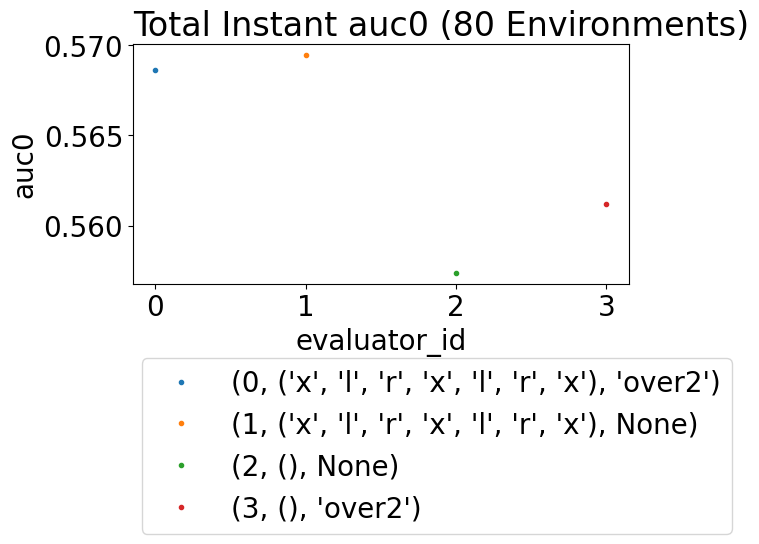

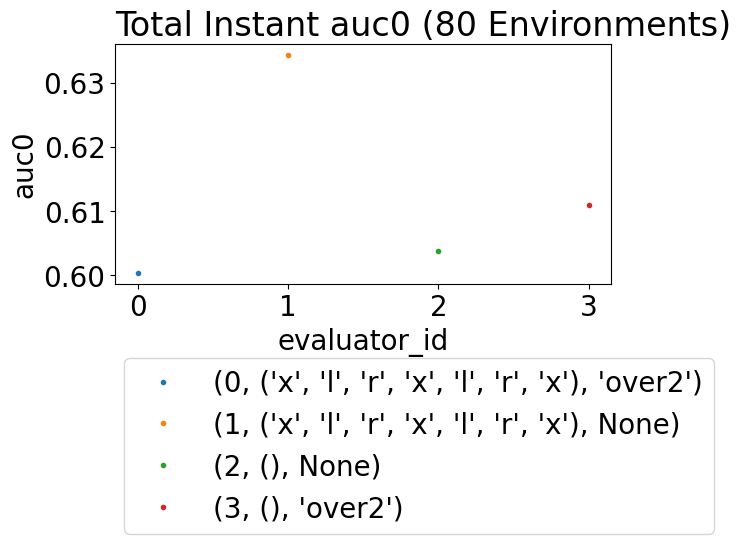

In [87]:
l = ['evaluator_id','s2','samp']
res.where(l=[(0,)]).plot_learners('evaluator_id','auc0',l=l,p=['g','rng'],span=span)
res.where(l=[(1,)]).plot_learners('evaluator_id','auc0',l=l,p=['g','rng'],span=span)

DAE Doesn't really work
Multi-task learning also doesn't really seem to help

# Extras

In [ ]:
class MyEnvironment:
    def __init__(self, a, L, g, rng):
        self.params = {'rng': rng, 'trn':a, 'l':L, 'g':g }
        self.X = None
        self.Y = None
        self.G = None
        self.a = list(a)
        self.L = L
        self.g = g
        self.a[7] = [a[7],2,1,10] if a[7] else None

    def get_data(self):
        import torch
        import itertools as it

        if self.X is not None: return self.X,self.Y,self.G

        X,Y,G = zip(*map(make_xyg2, work_items(*self.a)))

        X = torch.tensor(list(it.chain.from_iterable(X))).float()
        Y = torch.tensor(list(it.chain.from_iterable(Y))).float()
        G = torch.tensor(list(it.chain.from_iterable(G))).int()

        self.X,self.Y,self.G = X,Y,G

        if X.shape[0] == 0: return

        any_na = torch.isnan(Y[:,[0,1]]).any(dim=1)
        X = X[~any_na]
        Y = Y[~any_na].float()
        G = G[~any_na]

        rng_indexes = cb.CobaRandom(self.params['rng']).shuffle(range(len(X)))

        self.X,self.Y,self.G = X[rng_indexes],Y[rng_indexes],G[rng_indexes]

        return self.X,self.Y,self.G

class MyEvaluator:
    def __init__(self, s1, s2, s3, s4, dae_steps, dae_dropn, dae_sig, dae_bin, ssl_samps, ssl_negs, ssl_tau, ssl_v, st_steps, st_drop, ws_steps, weighted):

        self.s1  = s1  #dae
        self.s2  = s2  #ssl
        self.s3  = s3  #sl
        self.s4  = s4 

        self.dae_steps = dae_steps
        self.dae_dropn = dae_dropn
        self.dae_sig   = dae_sig
        self.dae_bin   = dae_bin

        self.ssl_samps = ssl_samps
        self.ssl_negs  = ssl_negs
        self.ssl_tau   = ssl_tau
        self.ssl_v     = ssl_v

        self.st_steps = st_steps
        self.st_drop  = st_drop
        self.ws_steps = ws_steps

        self.weighted = weighted

        self.params = {'s1': s1, 's2': s2, 's3': s3, 's4':s4, 'dae': (dae_steps,dae_dropn,dae_sig,dae_bin), 'ssl': (ssl_samps,ssl_negs,ssl_tau,ssl_v), 'sl': (st_steps,st_drop), 'ws': (ws_steps,), 'weighted': weighted }

    def evaluate(self, env, lrn):
        from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score, precision_score, recall_score
        from collections import Counter

        import os
        N_THREADS = '1'
        os.environ['OMP_NUM_THREADS'] = N_THREADS
        os.environ['OPENBLAS_NUM_THREADS'] = N_THREADS
        os.environ['MKL_NUM_THREADS'] = N_THREADS
        os.environ['VECLIB_MAXIMUM_THREADS'] = N_THREADS
        os.environ['NUMEXPR_NUM_THREADS'] = N_THREADS

        X,Y,G = env.get_data()
        if len(X) == 0: return

        torch.set_num_threads(1)

        def make_weights(G):
            W = torch.zeros((len(G),1))
            weights = Counter(G.tolist())
            for g,w in weights.items():
                W[G==g] = 1/w
            return (W / W.max())

        def get_trn_tst(G,g):
            is_tst = sum(G == i for i in g).bool() #type: ignore
            return ~is_tst, is_tst

        def sslv1(X,Y,G,nsamps,nnegs):
            from itertools import compress, repeat
            from operator import eq, ne

            rng = cb.CobaRandom(1)
            rng_order = rng.shuffle(range(len(X)))

            X = X.tolist()
            Y = list(map(tuple,Y.tolist()))
            G = G.tolist()

            X = list(map(X.__getitem__,rng_order))
            Y = list(map(Y.__getitem__,rng_order))
            G = list(map(G.__getitem__,rng_order))

            Xg = {}
            Yg = {}

            for g in set(G):
                Xg[g] = list(compress(X,map(eq,G,repeat(g))))
                Yg[g] = list(compress(Y,map(eq,G,repeat(g))))

            eq_class  = {y: list(compress(X,map(eq,Y,repeat(y)))) for y in set(Y)}
            ne_class  = {y: list(compress(X,map(ne,Y,repeat(y)))) for y in set(Y)}

            def choose_unique(items,given_i):
                if len(items) == 1:  return items[0]
                for i in rng.randints(100,0,len(items)-1):
                    if i != given_i:
                        return items[i]

            def choose_n(items,n):
                add_to_index = (indexes := set()).add if len(items) > n else (indexes := []).append
                for i in rng.randints(100,0,len(items)-1):
                    add_to_index(i)
                    if len(indexes)==n:
                        return [items[i] for i in indexes]

            for i in range(nsamps):
                anchor, positive, negative = [], [], []
                for g in set(G):
                    x,y = Xg[g][i%len(Xg[g])],Yg[g][i%len(Yg[g])]
                    anchor.append(x)
                    positive.append(choose_unique(eq_class[y],i))
                    negative.append(choose_n     (ne_class[y],nnegs))
                yield torch.tensor(anchor).float(), torch.tensor(positive).float(), torch.tensor(negative).float()

        def sslv2(X,Y,G,nsamps,nnegs):
            from itertools import compress, repeat, chain
            from operator import eq, ne

            rng = cb.CobaRandom(1)
            rng_order = rng.shuffle(range(len(X)))

            X = X.tolist()
            Y = list(map(tuple,Y.tolist()))
            G = G.tolist()

            X = list(map(X.__getitem__,rng_order))
            Y = list(map(Y.__getitem__,rng_order))
            G = list(map(G.__getitem__,rng_order))

            Xg = {}
            Yg = {}
            eq_class = {}
            ne_class = {}

            for g in set(G):
                _X = list(compress(X,map(eq,G,repeat(g))))
                _Y = list(compress(Y,map(eq,G,repeat(g))))

                Xg[g] = _X
                Yg[g] = _Y

                eq_class[g] = {y: list(compress(_X,map(eq,_Y,repeat(y)))) for y in set(_Y)}
                ne_class[g] = {y: list(compress(_X,map(ne,_Y,repeat(y)))) for y in set(_Y)}

            def choose_unique(items,given_i):
                if len(items) == 1:  return items[0]
                for i in rng.randints(100,0,len(items)-1):
                    if i != given_i:
                        return items[i]

            def choose_n(items,n):
                add_to_index = (indexes := set()).add if len(items) > n else (indexes := []).append
                for i in rng.randints(100,0,len(items)-1):
                    add_to_index(i)
                    if len(indexes)==n:
                        return [items[i] for i in indexes]

            for i in range(nsamps):
                anchor, positive, negative = [], [], []
                for g in rng.shuffle(set(G)):
                    if len(set(Yg[g])) == 1: continue

                    x,y = Xg[g][i%len(Xg[g])],Yg[g][i%len(Yg[g])]
                    anchor.append(x)
                    positive.append(choose_unique(eq_class[g][y],i%len(Yg[g])))
                    negative.append(choose_n     (ne_class[g][y],nnegs))

                yield torch.tensor(anchor).float(), torch.tensor(positive).float(), torch.tensor(negative).float()

        def remove_na(X,Y,G=None):
            any_na = torch.isnan(Y)
            if Y.ndim==2: any_na = any_na.any(dim=1)
            if G == None: return X[~any_na],Y[~any_na]
            else: return X[~any_na],Y[~any_na],G[~any_na]

        def replace_x(layers,n_feats,n_persons):
            new_layers = []
            for l in layers:
                if l == 'x': 
                    new_layers.append(n_feats)
                elif isinstance(l,(tuple,list)):
                    new_layers.append(replace_x(l,n_feats,n_persons))
                else: 
                    new_layers.append(l)
            return new_layers

        def pretrain(trn_X,trn_Y,trn_G):
            n_feats = trn_X.shape[1]
            n_persons = len(set(trn_G.tolist()))
            n_tasks = trn_Y.shape[1]

            _s1 = replace_x(self.s1,n_feats,n_persons)
            _s2 = replace_x(self.s2,n_feats,n_persons)
            _s3 = replace_x(self.s3,n_feats,n_persons)
            _s4 = replace_x(self.s4,n_feats,n_persons)

            _s1 = [n_tasks if f == 'y' else f for f in _s1]
            _s2 = [n_tasks if f == 'y' else f for f in _s2]
            _s3 = [n_tasks if f == 'y' else f for f in _s3]
            _s4 = [n_tasks if f == 'y' else f for f in _s4]

            _s3 = [n_persons*n_tasks if f == '-y' else f for f in _s3]
            _s4 = [n_persons*n_tasks if f == '-y' else f for f in _s4]

            s1 = FeedForward(_s1)
            s2 = FeedForward(_s2)
            s3 = FeedForward(_s3)
            s4 = FeedForward(_s4)

            s1_children = list(s1.children())
            s3_children = list(s3.children())

            sa = torch.nn.Sequential(*s1_children[len(s1_children)-self.dae_dropn:])
            s1 = torch.nn.Sequential(*s1_children[:len(s1_children)-self.dae_dropn])

            sb = torch.nn.Sequential(*s3_children[len(s3_children)-self.st_drop:])
            s3 = torch.nn.Sequential(*s3_children[:len(s3_children)-self.st_drop])

            s1opt = COCOB(s1.parameters()) if list(s1.parameters()) else None
            saopt = COCOB(sa.parameters()) if list(sa.parameters()) else None
            s2opt = COCOB(s2.parameters()) if list(s2.parameters()) else None
            s3opt = COCOB(s3.parameters()) if list(s3.parameters()) else None
            sbopt = COCOB(sb.parameters()) if list(sb.parameters()) else None
            s4opt = COCOB(s4.parameters()) if list(s4.parameters()) else None

            mods = [s1,sa,s2,s3,sb,s4]

            for m in mods: m.train()

            if _s1 and self.dae_steps:
                opts = list(filter(None,[s1opt,saopt]))
                X,G,W = trn_X,trn_G,make_weights(trn_G)

                if _s1[-1] != n_feats*n_persons:
                    Z = X
                else:
                    i = defaultdict(lambda c= count(0):next(c))
                    I = torch.tensor([[i[g]] for g in G.tolist()]) * n_feats + torch.arange(n_feats).unsqueeze(0)
                    R = torch.arange(len(X)).unsqueeze(1)
                    Z = torch.full((len(X),len(i)*n_feats), float('nan'))
                    Z[R,I] = X

                torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                isb = ((X == 1) | (X == 0) | torch.isnan(X)).all(dim=0)
                isn = ~isb
                nn  = (isn).sum()

                loss = torch.nn.MSELoss()
                for _ in range(self.dae_steps):
                    for (_X,_z,_w) in torch_loader:
                        for o in opts: o.zero_grad()

                        rn = torch.randn(size=(_X.shape[0],nn)) * self.dae_sig
                        ri = torch.rand(size=_X.shape) < self.dae_bin

                        _X[isb&ri] = 1-_X[isb&ri]
                        _X[:,isn] += rn

                        loss(sa(s1(_X.nan_to_num()))[~_z.isnan()],_z[~_z.isnan()]).backward()
                        for o in opts: o.step()

            if self.ssl_samps:
                X, Y, G = trn_X,trn_Y,trn_G

                if self.ssl_negs == 0: raise Exception("neg can't be 0")
                if self.ssl_tau == 0: raise Exception("Tau can't be 0")

                ssl = sslv1 if self.ssl_v == 1 else sslv2

                for A,P,N in ssl(X, Y, G, self.ssl_samps, self.ssl_negs):
                    torch_dataset = torch.utils.data.TensorDataset(A,P,N)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=4,drop_last=False,shuffle=True)

                    for _A, _P, _N in torch_loader:
                        #https://arxiv.org/pdf/2002.05709
                        _A = s2(s1(_A.nan_to_num()))
                        _P = s2(s1(_P.nan_to_num()))
                        _N = s2(s1(_N.nan_to_num()))

                        p = torch.einsum("bi,bi->b",_A,_P)
                        n = torch.einsum("bi,bji->bj",_A,_N)

                        p /= (torch.linalg.norm(_A,dim=1)*torch.linalg.norm(_P,dim=1))
                        n /= (torch.linalg.norm(_A,dim=1).unsqueeze(1)*torch.linalg.norm(_N,dim=2))

                        p = torch.exp(p/self.ssl_tau)
                        n = torch.exp(n/self.ssl_tau)

                        if s2opt: s2opt.zero_grad()
                        (-torch.log(p/(p+n.sum(dim=1)))).mean().backward()
                        if s2opt: s2opt.step()

            if self.st_steps:
                opts = list(filter(None,[s1opt,s2opt,s3opt,sbopt]))
                for o in opts: o.zero_grad()

                X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                if _s3[-1] != n_tasks*n_persons:
                    Z = Y
                else:
                    i = defaultdict(lambda c= count(0):next(c))
                    I = torch.tensor([[i[g]] for g in G.tolist()]) * n_tasks + torch.arange(n_tasks).unsqueeze(0)
                    R = torch.arange(len(Y)).unsqueeze(1)
                    Z = torch.full((len(G),len(i)*n_tasks), float('nan'))
                    Z[R,I] = Y

                torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                for _ in range(self.st_steps):
                    for _X,_z,_w in torch_loader:
                        for o in opts: o.zero_grad()
                        loss = torch.nn.BCEWithLogitsLoss(weight=_w.squeeze() if 2 in self.weighted else None)
                        loss(sb(s3(s2(s1(_X.nan_to_num()))))[~_z.isnan()],_z[~_z.isnan()]).backward()
                        for o in opts: o.step()

            if self.ws_steps:
                opts = list(filter(None,[s4opt] if self.st_steps else [s1opt,s2opt,s4opt]))
                for o in opts: o.zero_grad()

                X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                torch_dataset = torch.utils.data.TensorDataset(X,Y,W)
                torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                loss = torch.nn.BCEWithLogitsLoss()
                for _ in range(self.ws_steps):
                    for _X,_y,_w in torch_loader:
                        for o in opts: o.zero_grad()
                        loss = torch.nn.BCEWithLogitsLoss(weight=_w if 3 in self.weighted else None)
                        loss(s4(s3(s2(s1(_X.nan_to_num())))),_y).backward()
                        for o in opts: o.step()

            for m in mods: m.eval()

            def pretrained(x):
                with torch.no_grad():
                    return torch.sigmoid(s4(s3(s2(s1(x.nan_to_num())))))

            return pretrained

        def get_score(Y_true,Y_prob):
            out = dict()

            Y_pred = (np.array(Y_prob)>=.5).astype(float).tolist()
            Y_true = list(zip(*Y_true.tolist()))
            Y_prob = list(zip(*Y_prob.tolist()))
            Y_pred = list(zip(*Y_pred))

            for i,pred,true,prob in zip(count(),Y_pred,Y_true,Y_prob):

                one = len(set(true)) == 1

                tp = sum([p==1 and t==1 for p,t in zip(pred,true)])
                tn = sum([p==0 and t==0 for p,t in zip(pred,true)])
                fp = sum([p==1 and t==0 for p,t in zip(pred,true)])
                fn = sum([p==0 and t==1 for p,t in zip(pred,true)])

                out[f"auc{i}"] = float('nan') if one else roc_auc_score(true,prob)
                out[f"bal{i}"] = float('nan') if one else balanced_accuracy_score(true,pred)
                out[f"sen{i}"] = float('nan') if one else tp/(tp+fn)
                out[f"spe{i}"] = float('nan') if one else tn/(tn+fp)

                for j in [0,1]:
                    out[f"f1{j}{i}" ] = float('nan') if one else f1_score(true,pred,pos_label=j)
                    out[f"pre{j}{i}"] = float('nan') if one else precision_score(true,pred,pos_label=j,zero_division=0)
                    out[f"rec{j}{i}"] = float('nan') if one else recall_score(true,pred,pos_label=j)

                out[f"f1m{i}"] = float('nan') if one else f1_score(true,pred,average='macro')
                out[f"f1w{i}"] = float('nan') if one else f1_score(true,pred,average='weighted')

            return out

        def get_scores(X,Y,G,g):
            torch.manual_seed(env.params['rng'])

            is_trn, is_tst = get_trn_tst(G,g)
            trn_X, trn_Y, trn_G = X[is_trn], Y[is_trn], G[is_trn]
            tst_X, tst_Y, tst_G = X[is_tst], Y[is_tst], G[is_tst]

            trn_X,trn_Y,trn_G = remove_na(trn_X,trn_Y,trn_G) #type:ignore
            tst_X,tst_Y,tst_G = remove_na(tst_X,tst_Y,tst_G) #type:ignore

            pretrained = pretrain(trn_X,trn_Y,trn_G)

            G      = tst_G
            true_Y = tst_Y
            pred_Y = pretrained(tst_X)

            return [get_score(true_Y[G==pid],pred_Y[G==pid]) for pid in g]

        scores = get_scores(X,Y[:,env.L],G,env.g)
        
        score = {}
        for k in set().union(*scores):
            score[f"g{k}".replace(", ",",")] = [s[k] for s in scores]
            score[f"{k}".replace(", ",",")]  = np.nanmean([s[k] for s in scores])

        yield score

envs  = []
envs += [ MyEnvironment((True, 0, 300,   0, 300, 300,   0,   0, False, True, 'del'), [0,1], g, rng) for g in outer_gs for rng in range(12) ]
envs += [ MyEnvironment((True, 0, 300, 300,   0, 300, 300, 300, False, True, 'del'), [0  ], g, rng) for g in outer_gs for rng in range(12) ]
envs += [ MyEnvironment((True, 0,   0,   0,   0, 300, 300, 300, False, True, 'del'), [  1], g, rng) for g in outer_gs for rng in range(12) ]

rng = cb.CobaRandom(1)

def make_triples(envs,val):
    return [ (env,None,val) for env in envs ]

def last_width(values):
    if not values: return 'x'

    for v in reversed(values):
        if isinstance(v,list):
            return last_width(v)
        if isinstance(v,int) or v in ['x','y','-y']:
            return v

    raise Exception()

def apply_drop(items,drop):
    if drop == 0: return items
    else: return items[:-drop]

def exp_triples(dae,ssl,st,width,rng):
    dae_depth = rng.randint(1,2)
    dae_resid = rng.choice([True,False])                     if dae else False
    dae_step  = rng.randint(1,3)                             if dae else 0
    dae_mask  = rng.choice([0,round(rng.random(.05,.30),4)]) if dae else 0
    dae_sigma = rng.choice([0,round(rng.random(.05,.15),4)]) if dae else 0
    dae_salt  = rng.choice([0,round(rng.random(.05,.30),4)]) if dae else 0
    dae_drop  = rng.choice([0,1])                            if dae else 0

    ssl_depth = rng.randint(1,2)
    ssl_resid = rng.choice([True,False])     if ssl else False
    ssl_samps = rng.randint(40,150)          if ssl else 0
    ssl_negs  = rng.randint(1,5)             if ssl else 0
    ssl_tau   = round(rng.random(.25,.75),4) if ssl else 0
    ssl_aware = ssl

    st_depth = rng.randint(1,2)
    st_resid = rng.choice([True,False]) if st else False
    st_steps = rng.randint(1,3)         if st else 0
    st_drop  = rng.choice([0,1])        if st else 0
    st_aware = 'y'                      if st == 1 else '-y'

    ws = rng.randint(1,3)

    dae_pre   = ['x']+([dae_mask] if dae_mask else []) + ([width] if dae_resid and dae_depth else [])
    dae_inner = [['l','r',width,'l','r',width]] if dae_resid else [width, 'l','r']
    dae_inner = dae_inner*dae_depth
    dae_post  = ['x']
    dae_arch  = (dae_pre + dae_inner + dae_post) if dae else []

    lw = last_width(apply_drop(dae_arch,dae_drop))

    ssl_pre   = [lw] if (ssl_depth>0) and (lw == width or not ssl_resid) else [lw,width]
    ssl_inner = [['l','r',width,'l','r',width]] if ssl_resid else [width, 'l','r']
    ssl_inner = ssl_inner*ssl_depth
    ssl_post  = []
    ssl_arch  = (ssl_pre + ssl_inner + ssl_post) if ssl else []

    lw = last_width(apply_drop(dae_arch,dae_drop)+ssl_arch)

    st_pre    = [lw] if (st_depth>0) and (lw == width or not st_resid) else [lw,width]
    st_inner  = [['l','r',width,'l','r',width]] if st_resid else [width, 'l','r']
    st_inner  = st_inner*st_depth
    st_post   = [st_aware]
    st_arch   = (st_pre  + st_inner  + st_post ) if st else []

    if st and st_arch[-1] == 'y' and st_drop == 0: st_drop = 1
    assert not (st_arch and st_drop==0 and st_arch[-1] == 1)

    lw = last_width(apply_drop(dae_arch,dae_drop)+ssl_arch+apply_drop(st_arch,st_drop))

    val = MyEvaluator(dae_arch, ssl_arch, st_arch, (lw,'y'), dae_step, dae_drop, dae_sigma, dae_salt, ssl_samps, ssl_negs, ssl_tau, ssl_aware, st_steps, st_drop, ws, [])

    yield from make_triples(envs,val)

triples = []
triples.extend(make_triples(envs,MyEvaluator((), (), (), ('x','y'), 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, [])))

for i in range(90):
    width  = rng.randint(10,120)
    for dae,ssl,st in product([0,1],[0,1,2],[0,1,2]):
        if dae or ssl or st:
            triples.extend(exp_triples(dae,ssl,st,width,cb.CobaRandom(i)))

# A refactored and cleaned up hyperparameter search for response and interest prediction
# I used this to determine which hyperparameter configurations to explore more deeply
cb.Experiment(triples).run('../logs/2/hyper.log.gz',processes=38,quiet=True) #type: ignore


In [ ]:
class MyEnvironment:
    def __init__(self, a, L, g, rng):
        self.params = {'rng': rng, 'trn':a, 'l':L, 'g':g }
        self.X = None
        self.Y = None
        self.G = None
        self.a = list(a)
        self.L = L
        self.g = g
        self.a[7] = [a[7],2,1,10] if a[7] else None

    def get_data(self):
        import torch
        import itertools as it

        if self.X is not None: return self.X,self.Y,self.G

        X,Y,G = zip(*map(make_xyg2, work_items(*self.a)))

        X = torch.tensor(list(it.chain.from_iterable(X))).float()
        Y = torch.tensor(list(it.chain.from_iterable(Y))).float()
        G = torch.tensor(list(it.chain.from_iterable(G))).int()

        self.X,self.Y,self.G = X,Y,G

        if X.shape[0] == 0: return

        any_na = torch.isnan(Y[:,[0,1]]).any(dim=1)
        X = X[~any_na]
        Y = Y[~any_na].float()
        G = G[~any_na]

        rng_indexes = cb.CobaRandom(self.params['rng']).shuffle(range(len(X)))

        self.X,self.Y,self.G = X[rng_indexes],Y[rng_indexes],G[rng_indexes]

        return self.X,self.Y,self.G

class MyEvaluator:
    def __init__(self, s1, s2, s3, s4, dae_steps, dae_dropn, dae_sig, dae_bin, ssl_samps, ssl_negs, ssl_tau, ssl_v, st_steps, st_drop, ws_steps, weighted):

        self.s1  = s1  #dae
        self.s2  = s2  #ssl
        self.s3  = s3  #sl
        self.s4  = s4 

        self.dae_steps = dae_steps
        self.dae_dropn = dae_dropn
        self.dae_sig   = dae_sig
        self.dae_bin   = dae_bin

        self.ssl_samps = ssl_samps
        self.ssl_negs  = ssl_negs
        self.ssl_tau   = ssl_tau
        self.ssl_v     = ssl_v

        self.st_steps = st_steps
        self.st_drop  = st_drop
        self.ws_steps = ws_steps

        self.weighted = weighted

        self.params = {'s1': s1, 's2': s2, 's3': s3, 's4':s4, 'dae': (dae_steps,dae_dropn,dae_sig,dae_bin), 'ssl': (ssl_samps,ssl_negs,ssl_tau,ssl_v), 'sl': (st_steps,st_drop), 'ws': (ws_steps,), 'weighted': weighted }

    def evaluate(self, env, lrn):
        from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score, precision_score, recall_score
        from collections import Counter

        import os
        N_THREADS = '1'
        os.environ['OMP_NUM_THREADS'] = N_THREADS
        os.environ['OPENBLAS_NUM_THREADS'] = N_THREADS
        os.environ['MKL_NUM_THREADS'] = N_THREADS
        os.environ['VECLIB_MAXIMUM_THREADS'] = N_THREADS
        os.environ['NUMEXPR_NUM_THREADS'] = N_THREADS

        X,Y,G = env.get_data()
        if len(X) == 0: return

        torch.set_num_threads(1)

        def make_weights(G):
            W = torch.zeros((len(G),1))
            weights = Counter(G.tolist())
            for g,w in weights.items():
                W[G==g] = 1/w
            return (W / W.max())

        def get_trn_tst(G,g):
            is_tst = sum(G == i for i in g).bool() #type: ignore
            return ~is_tst, is_tst

        def sslv1(X,Y,G,nsamps,nnegs):
            from itertools import compress, repeat
            from operator import eq, ne

            rng = cb.CobaRandom(1)
            rng_order = rng.shuffle(range(len(X)))

            X = X.tolist()
            Y = list(map(tuple,Y.tolist()))
            G = G.tolist()

            X = list(map(X.__getitem__,rng_order))
            Y = list(map(Y.__getitem__,rng_order))
            G = list(map(G.__getitem__,rng_order))

            Xg = {}
            Yg = {}

            for g in set(G):
                Xg[g] = list(compress(X,map(eq,G,repeat(g))))
                Yg[g] = list(compress(Y,map(eq,G,repeat(g))))

            eq_class  = {y: list(compress(X,map(eq,Y,repeat(y)))) for y in set(Y)}
            ne_class  = {y: list(compress(X,map(ne,Y,repeat(y)))) for y in set(Y)}

            def choose_unique(items,given_i):
                if len(items) == 1:  return items[0]
                for i in rng.randints(100,0,len(items)-1):
                    if i != given_i:
                        return items[i]

            def choose_n(items,n):
                add_to_index = (indexes := set()).add if len(items) > n else (indexes := []).append
                for i in rng.randints(100,0,len(items)-1):
                    add_to_index(i)
                    if len(indexes)==n:
                        return [items[i] for i in indexes]

            for i in range(nsamps):
                anchor, positive, negative = [], [], []
                for g in set(G):
                    x,y = Xg[g][i%len(Xg[g])],Yg[g][i%len(Yg[g])]
                    anchor.append(x)
                    positive.append(choose_unique(eq_class[y],i))
                    negative.append(choose_n     (ne_class[y],nnegs))
                yield torch.tensor(anchor).float(), torch.tensor(positive).float(), torch.tensor(negative).float()

        def sslv2(X,Y,G,nsamps,nnegs):
            from itertools import compress, repeat, chain
            from operator import eq, ne

            rng = cb.CobaRandom(1)
            rng_order = rng.shuffle(range(len(X)))

            X = X.tolist()
            Y = list(map(tuple,Y.tolist()))
            G = G.tolist()

            X = list(map(X.__getitem__,rng_order))
            Y = list(map(Y.__getitem__,rng_order))
            G = list(map(G.__getitem__,rng_order))

            Xg = {}
            Yg = {}
            eq_class = {}
            ne_class = {}

            for g in set(G):
                _X = list(compress(X,map(eq,G,repeat(g))))
                _Y = list(compress(Y,map(eq,G,repeat(g))))

                Xg[g] = _X
                Yg[g] = _Y

                eq_class[g] = {y: list(compress(_X,map(eq,_Y,repeat(y)))) for y in set(_Y)}
                ne_class[g] = {y: list(compress(_X,map(ne,_Y,repeat(y)))) for y in set(_Y)}

            def choose_unique(items,given_i):
                if len(items) == 1:  return items[0]
                for i in rng.randints(100,0,len(items)-1):
                    if i != given_i:
                        return items[i]

            def choose_n(items,n):
                add_to_index = (indexes := set()).add if len(items) > n else (indexes := []).append
                for i in rng.randints(100,0,len(items)-1):
                    add_to_index(i)
                    if len(indexes)==n:
                        return [items[i] for i in indexes]

            for i in range(nsamps):
                anchor, positive, negative = [], [], []
                for g in rng.shuffle(set(G)):
                    if len(set(Yg[g])) == 1: continue

                    x,y = Xg[g][i%len(Xg[g])],Yg[g][i%len(Yg[g])]
                    anchor.append(x)
                    positive.append(choose_unique(eq_class[g][y],i%len(Yg[g])))
                    negative.append(choose_n     (ne_class[g][y],nnegs))

                yield torch.tensor(anchor).float(), torch.tensor(positive).float(), torch.tensor(negative).float()

        def remove_na(X,Y,G=None):
            any_na = torch.isnan(Y)
            if Y.ndim==2: any_na = any_na.any(dim=1)
            if G == None: return X[~any_na],Y[~any_na]
            else: return X[~any_na],Y[~any_na],G[~any_na]

        def replace_x(layers,n_feats,n_persons):
            new_layers = []
            for l in layers:
                if l == 'x': 
                    new_layers.append(n_feats)
                elif isinstance(l,(tuple,list)):
                    new_layers.append(replace_x(l,n_feats,n_persons))
                else: 
                    new_layers.append(l)
            return new_layers

        def pretrain(trn_X,trn_Y,trn_G):
            n_feats = trn_X.shape[1]
            n_persons = len(set(trn_G.tolist()))
            n_tasks = trn_Y.shape[1]

            _s1 = replace_x(self.s1,n_feats,n_persons)
            _s2 = replace_x(self.s2,n_feats,n_persons)
            _s3 = replace_x(self.s3,n_feats,n_persons)
            _s4 = replace_x(self.s4,n_feats,n_persons)

            _s1 = [n_tasks if f == 'y' else f for f in _s1]
            _s2 = [n_tasks if f == 'y' else f for f in _s2]
            _s3 = [n_tasks if f == 'y' else f for f in _s3]
            _s4 = [n_tasks if f == 'y' else f for f in _s4]

            _s3 = [n_persons*n_tasks if f == '-y' else f for f in _s3]
            _s4 = [n_persons*n_tasks if f == '-y' else f for f in _s4]

            s1 = FeedForward(_s1)
            s2 = FeedForward(_s2)
            s3 = FeedForward(_s3)
            s4 = FeedForward(_s4)

            s1_children = list(s1.children())
            s3_children = list(s3.children())

            sa = torch.nn.Sequential(*s1_children[len(s1_children)-self.dae_dropn:])
            s1 = torch.nn.Sequential(*s1_children[:len(s1_children)-self.dae_dropn])

            sb = torch.nn.Sequential(*s3_children[len(s3_children)-self.st_drop:])
            s3 = torch.nn.Sequential(*s3_children[:len(s3_children)-self.st_drop])

            s1opt = COCOB(s1.parameters()) if list(s1.parameters()) else None
            saopt = COCOB(sa.parameters()) if list(sa.parameters()) else None
            s2opt = COCOB(s2.parameters()) if list(s2.parameters()) else None
            s3opt = COCOB(s3.parameters()) if list(s3.parameters()) else None
            sbopt = COCOB(sb.parameters()) if list(sb.parameters()) else None
            s4opt = COCOB(s4.parameters()) if list(s4.parameters()) else None

            mods = [s1,sa,s2,s3,sb,s4]

            for m in mods: m.train()

            if _s1 and self.dae_steps:
                opts = list(filter(None,[s1opt,saopt]))
                X,G,W = trn_X,trn_G,make_weights(trn_G)

                if _s1[-1] != n_feats*n_persons:
                    Z = X
                else:
                    i = defaultdict(lambda c= count(0):next(c))
                    I = torch.tensor([[i[g]] for g in G.tolist()]) * n_feats + torch.arange(n_feats).unsqueeze(0)
                    R = torch.arange(len(X)).unsqueeze(1)
                    Z = torch.full((len(X),len(i)*n_feats), float('nan'))
                    Z[R,I] = X

                torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                isb = ((X == 1) | (X == 0) | torch.isnan(X)).all(dim=0)
                isn = ~isb
                nn  = (isn).sum()

                loss = torch.nn.MSELoss()
                for _ in range(self.dae_steps):
                    for (_X,_z,_w) in torch_loader:
                        for o in opts: o.zero_grad()

                        rn = torch.randn(size=(_X.shape[0],nn)) * self.dae_sig
                        ri = torch.rand(size=_X.shape) < self.dae_bin

                        _X[isb&ri] = 1-_X[isb&ri]
                        _X[:,isn] += rn

                        loss(sa(s1(_X.nan_to_num()))[~_z.isnan()],_z[~_z.isnan()]).backward()
                        for o in opts: o.step()

            if self.ssl_samps:
                X, Y, G = trn_X,trn_Y,trn_G

                if self.ssl_negs == 0: raise Exception("neg can't be 0")
                if self.ssl_tau == 0: raise Exception("Tau can't be 0")

                ssl = sslv1 if self.ssl_v == 1 else sslv2

                for A,P,N in ssl(X, Y, G, self.ssl_samps, self.ssl_negs):
                    torch_dataset = torch.utils.data.TensorDataset(A,P,N)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=4,drop_last=False,shuffle=True)

                    for _A, _P, _N in torch_loader:
                        #https://arxiv.org/pdf/2002.05709
                        _A = s2(s1(_A.nan_to_num()))
                        _P = s2(s1(_P.nan_to_num()))
                        _N = s2(s1(_N.nan_to_num()))

                        p = torch.einsum("bi,bi->b",_A,_P)
                        n = torch.einsum("bi,bji->bj",_A,_N)

                        p /= (torch.linalg.norm(_A,dim=1)*torch.linalg.norm(_P,dim=1))
                        n /= (torch.linalg.norm(_A,dim=1).unsqueeze(1)*torch.linalg.norm(_N,dim=2))

                        p = torch.exp(p/self.ssl_tau)
                        n = torch.exp(n/self.ssl_tau)

                        if s2opt: s2opt.zero_grad()
                        (-torch.log(p/(p+n.sum(dim=1)))).mean().backward()
                        if s2opt: s2opt.step()

            if self.st_steps:
                opts = list(filter(None,[s1opt,s2opt,s3opt,sbopt]))
                for o in opts: o.zero_grad()

                X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                if _s3[-1] != n_tasks*n_persons:
                    Z = Y
                else:
                    i = defaultdict(lambda c= count(0):next(c))
                    I = torch.tensor([[i[g]] for g in G.tolist()]) * n_tasks + torch.arange(n_tasks).unsqueeze(0)
                    R = torch.arange(len(Y)).unsqueeze(1)
                    Z = torch.full((len(G),len(i)*n_tasks), float('nan'))
                    Z[R,I] = Y

                torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                for _ in range(self.st_steps):
                    for _X,_z,_w in torch_loader:
                        for o in opts: o.zero_grad()
                        loss = torch.nn.BCEWithLogitsLoss(weight=_w.squeeze() if 2 in self.weighted else None)
                        loss(sb(s3(s2(s1(_X.nan_to_num()))))[~_z.isnan()],_z[~_z.isnan()]).backward()
                        for o in opts: o.step()

            if self.ws_steps:
                opts = list(filter(None,[s4opt] if self.st_steps else [s1opt,s2opt,s4opt]))
                for o in opts: o.zero_grad()

                X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                torch_dataset = torch.utils.data.TensorDataset(X,Y,W)
                torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                loss = torch.nn.BCEWithLogitsLoss()
                for _ in range(self.ws_steps):
                    for _X,_y,_w in torch_loader:
                        for o in opts: o.zero_grad()
                        loss = torch.nn.BCEWithLogitsLoss(weight=_w if 3 in self.weighted else None)
                        loss(s4(s3(s2(s1(_X.nan_to_num())))),_y).backward()
                        for o in opts: o.step()

            for m in mods: m.eval()

            def pretrained(x):
                with torch.no_grad():
                    return torch.sigmoid(s4(s3(s2(s1(x.nan_to_num())))))

            return pretrained

        def get_score(Y_true,Y_prob):
            out = dict()

            for i in range(Y_true.shape[1]):

                true = Y_true[:,i].tolist()
                prob = Y_prob[:,i].tolist()
                one  = len(set(true)) == 1

                if not one:
                    precision, recall, thresholds = precision_recall_curve(true,prob)
                    f1_den = recall+precision
                    f1_num = 2*recall*precision
                    f1_scores = f1_num/(f1_den+(f1_den==0).astype(int))
                    pred = (np.array(prob)>=thresholds[np.argmax(f1_scores)]).astype(float).tolist()
                    tp = sum([p==1 and t==1 for p,t in zip(pred,true)])
                    tn = sum([p==0 and t==0 for p,t in zip(pred,true)])
                    fp = sum([p==1 and t==0 for p,t in zip(pred,true)])
                    fn = sum([p==0 and t==1 for p,t in zip(pred,true)])

                out[f"auc{i}"] = float('nan') if one else roc_auc_score(true,prob)
                out[f"bal{i}"] = float('nan') if one else balanced_accuracy_score(true,pred)
                out[f"sen{i}"] = float('nan') if one else tp/(tp+fn)
                out[f"spe{i}"] = float('nan') if one else tn/(tn+fp)

                for j in [0,1]:
                    out[f"f1{j}{i}" ] = float('nan') if one else f1_score(true,pred,pos_label=j)
                    out[f"pre{j}{i}"] = float('nan') if one else precision_score(true,pred,pos_label=j,zero_division=0)
                    out[f"rec{j}{i}"] = float('nan') if one else recall_score(true,pred,pos_label=j)

                out[f"f1m{i}"] = float('nan') if one else f1_score(true,pred,average='macro')
                out[f"f1w{i}"] = float('nan') if one else f1_score(true,pred,average='weighted')

            return out

        def get_scores(X,Y,G,g):
            torch.manual_seed(env.params['rng'])

            is_trn, is_tst = get_trn_tst(G,g)
            trn_X, trn_Y, trn_G = X[is_trn], Y[is_trn], G[is_trn]
            tst_X, tst_Y, tst_G = X[is_tst], Y[is_tst], G[is_tst]

            trn_X,trn_Y,trn_G = remove_na(trn_X,trn_Y,trn_G) #type:ignore
            tst_X,tst_Y,tst_G = remove_na(tst_X,tst_Y,tst_G) #type:ignore

            pretrained = pretrain(trn_X,trn_Y,trn_G)

            G      = tst_G
            true_Y = tst_Y
            pred_Y = pretrained(tst_X)

            return [get_score(true_Y[G==pid],pred_Y[G==pid]) for pid in g]

        scores = get_scores(X,Y[:,env.L],G,env.g)

        score = {}
        for k in set().union(*scores):
            score[f"g{k}".replace(", ",",")] = [s[k] for s in scores]
            score[f"{k}".replace(", ",",")] = np.nanmean([s[k] for s in scores])

        yield score

envs  = []
envs += [ MyEnvironment((True, 0, 300,   0, 300, 300,   0,   0, False, True, 'del'), [0,1], g, rng) for g in outer_gs for rng in range(12) ]
envs += [ MyEnvironment((True, 0, 300, 300,   0, 300, 300, 300, False, True, 'del'), [0  ], g, rng) for g in outer_gs for rng in range(12) ]
envs += [ MyEnvironment((True, 0,   0,   0,   0, 300, 300, 300, False, True, 'del'), [  1], g, rng) for g in outer_gs for rng in range(12) ]

rng = cb.CobaRandom(1)

def make_triples(envs,val):
    return [ (env,None,val) for env in envs ]

def last_width(values):
    if not values: return 'x'

    for v in reversed(values):
        if isinstance(v,list):
            return last_width(v)
        if isinstance(v,int) or v in ['x','y','-y']:
            return v

    raise Exception()

def apply_drop(items,drop):
    if drop == 0: return items
    else: return items[:-drop]

def exp_triples(dae,ssl,st,width,rng):
    dae_depth = rng.randint(1,2)
    dae_resid = rng.choice([True,False])                     if dae else False
    dae_step  = rng.randint(1,3)                             if dae else 0
    dae_mask  = rng.choice([0,round(rng.random(.05,.30),4)]) if dae else 0
    dae_sigma = rng.choice([0,round(rng.random(.05,.15),4)]) if dae else 0
    dae_salt  = rng.choice([0,round(rng.random(.05,.30),4)]) if dae else 0
    dae_drop  = rng.choice([0,1])                            if dae else 0

    ssl_depth = rng.randint(1,2)
    ssl_resid = rng.choice([True,False])     if ssl else False
    ssl_samps = rng.randint(40,150)          if ssl else 0
    ssl_negs  = rng.randint(1,5)             if ssl else 0
    ssl_tau   = round(rng.random(.25,.75),4) if ssl else 0
    ssl_aware = ssl

    st_depth = rng.randint(1,2)
    st_resid = rng.choice([True,False]) if st else False
    st_steps = rng.randint(1,3)         if st else 0
    st_drop  = rng.choice([0,1])        if st else 0
    st_aware = 'y'                      if st == 1 else '-y'

    ws = rng.randint(1,3)

    dae_pre   = ['x']+([dae_mask] if dae_mask else []) + ([width] if dae_resid and dae_depth else [])
    dae_inner = [['l','r',width,'l','r',width]] if dae_resid else [width, 'l','r']
    dae_inner = dae_inner*dae_depth
    dae_post  = ['x']
    dae_arch  = (dae_pre + dae_inner + dae_post) if dae else []

    lw = last_width(apply_drop(dae_arch,dae_drop))

    ssl_pre   = [lw] if (ssl_depth>0) and (lw == width or not ssl_resid) else [lw,width]
    ssl_inner = [['l','r',width,'l','r',width]] if ssl_resid else [width, 'l','r']
    ssl_inner = ssl_inner*ssl_depth
    ssl_post  = []
    ssl_arch  = (ssl_pre + ssl_inner + ssl_post) if ssl else []

    lw = last_width(apply_drop(dae_arch,dae_drop)+ssl_arch)

    st_pre    = [lw] if (st_depth>0) and (lw == width or not st_resid) else [lw,width]
    st_inner  = [['l','r',width,'l','r',width]] if st_resid else [width, 'l','r']
    st_inner  = st_inner*st_depth
    st_post   = [st_aware]
    st_arch   = (st_pre  + st_inner  + st_post ) if st else []

    if st and st_arch[-1] == 'y' and st_drop == 0: st_drop = 1
    assert not (st_arch and st_drop==0 and st_arch[-1] == 1)

    lw = last_width(apply_drop(dae_arch,dae_drop)+ssl_arch+apply_drop(st_arch,st_drop))

    val = MyEvaluator(dae_arch, ssl_arch, st_arch, (lw,'y'), dae_step, dae_drop, dae_sigma, dae_salt, ssl_samps, ssl_negs, ssl_tau, ssl_aware, st_steps, st_drop, ws, [])

    yield from make_triples(envs,val)

triples = []

triples.extend(make_triples(envs,MyEvaluator((), (), (), ('x','y'), 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, [])))
j = 1

for i in range(90):
    width  = rng.randint(10,120)
    for dae,ssl,st in product([0,1],[0,1,2],[0,1,2]):
        if dae or ssl or st:
            j+=1
            items = list(exp_triples(dae,ssl,st,width,cb.CobaRandom(i)))

            if j in [17,35,58,61,75,85,112,126,132,138]:
                triples.extend(items)

#This is similar to 2/hyper.log.gz except that the best f1 choices were made for a small subset of models
cb.Experiment(triples).run('../logs/2/hyper-f1.log.gz',processes=38,quiet=True) #type: ignore


{'Learners': 1, 'Environments': 720, 'Interactions': 7920}


In [7]:
triples[0][2].params

{'s1': [],
 's2': ['x', 28, 'l', 'r'],
 's3': [],
 's4': (28, 'y'),
 'dae': (0, 0, 0, 0),
 'ssl': (78, 3, 0.5689, 2),
 'sl': (0, 0),
 'ws': (3,),
 'weighted': []}

In [26]:
res2 = cb.Result.from_file('../logs/2/offnp-multitask2.log.gz')

In [27]:
res2.environments.to_pandas()

,environment_id,env_type,g,l,rng,trn
0,0,MyEnvironment,"(423, 480, 455)","(0, 1)",0,"(True, 0, 300, 0, 300, 300, 0, 0, False, True,..."
1,1,MyEnvironment,"(423, 480, 455)","(0, 1)",1,"(True, 0, 300, 0, 300, 300, 0, 0, False, True,..."
2,2,MyEnvironment,"(423, 480, 455)","(0, 1)",2,"(True, 0, 300, 0, 300, 300, 0, 0, False, True,..."
3,3,MyEnvironment,"(423, 480, 455)","(0, 1)",3,"(True, 0, 300, 0, 300, 300, 0, 0, False, True,..."
4,4,MyEnvironment,"(433, 452, 469)","(0, 1)",0,"(True, 0, 300, 0, 300, 300, 0, 0, False, True,..."
5,5,MyEnvironment,"(433, 452, 469)","(0, 1)",1,"(True, 0, 300, 0, 300, 300, 0, 0, False, True,..."
6,6,MyEnvironment,"(433, 452, 469)","(0, 1)",2,"(True, 0, 300, 0, 300, 300, 0, 0, False, True,..."
7,7,MyEnvironment,"(433, 452, 469)","(0, 1)",3,"(True, 0, 300, 0, 300, 300, 0, 0, False, True,..."
8,8,MyEnvironment,"(446, 437, 456)","(0, 1)",0,"(True, 0, 300, 0, 300, 300, 0, 0, False, True,..."
9,9,MyEnvironment,"(446, 437, 456)","(0, 1)",1,"(True, 0, 300, 0, 300, 300, 0, 0, False, True,..."


In [31]:
set(res2.environments['g'])

{(423, 480, 455),
 (433, 452, 469),
 (446, 437, 456),
 (486, 474, 475),
 (488, 460, 458),
 (498, 416, 463)}

In [32]:
set(res.environments['g'])

{(415, 420, 434),
 (421, 491, 461),
 (423, 480, 455),
 (431, 472, 471),
 (433, 452, 469),
 (444, 497, 442),
 (446, 437, 456),
 (447, 439, 413),
 (448, 436, 482),
 (457, 443, 424),
 (466, 440, 429),
 (467, 430),
 (476, 468, 485),
 (477, 445, 450),
 (486, 474, 475),
 (488, 460, 458),
 (490, 432, 470),
 (492, 473, 483),
 (493, 465, 417),
 (498, 416, 463)}

In [29]:
res.environments.to_pandas()

,environment_id,env_type,g,l,rng,trn
0,0,MyEnvironment,"(423, 480, 455)","(0, 1)",0,"(True, 0, 300, 0, 300, 300, 0, 0, False, True,..."
1,1,MyEnvironment,"(423, 480, 455)","(0, 1)",1,"(True, 0, 300, 0, 300, 300, 0, 0, False, True,..."
2,2,MyEnvironment,"(423, 480, 455)","(0, 1)",2,"(True, 0, 300, 0, 300, 300, 0, 0, False, True,..."
3,3,MyEnvironment,"(423, 480, 455)","(0, 1)",3,"(True, 0, 300, 0, 300, 300, 0, 0, False, True,..."
4,4,MyEnvironment,"(433, 452, 469)","(0, 1)",0,"(True, 0, 300, 0, 300, 300, 0, 0, False, True,..."
...,...,...,...,...,...,...
75,75,MyEnvironment,"(447, 439, 413)","(0, 1)",3,"(True, 0, 300, 0, 300, 300, 0, 0, False, True,..."
76,76,MyEnvironment,"(467, 430)","(0, 1)",0,"(True, 0, 300, 0, 300, 300, 0, 0, False, True,..."
77,77,MyEnvironment,"(467, 430)","(0, 1)",1,"(True, 0, 300, 0, 300, 300, 0, 0, False, True,..."
78,78,MyEnvironment,"(467, 430)","(0, 1)",2,"(True, 0, 300, 0, 300, 300, 0, 0, False, True,..."


In [21]:
print(off_p(res, mets=['gauc0','gauc1'], aggs={'gauch':geth()}, sort_by=('gauch','avg')))
print()
print(res.evaluators.to_pandas())

  evaluator_id gauc0                   gauc1                   gauch                  
                 p10   p50   p90   avg   p10   p50   p90   avg   p10   p50   p90   avg
0            0  0.41  0.54  0.70  0.55  0.39  0.55  0.84  0.59  0.43  0.53  0.69  0.55
1            1  0.41  0.55  0.74  0.55  0.40  0.55  0.79  0.57  0.41  0.53  0.69  0.54
2            2  0.42  0.56  0.67  0.55  0.39  0.54  0.83  0.58  0.40  0.54  0.70  0.54

   evaluator_id     dae    eval_type  n_models             pers  s1                                 s2  s3                                 s4  samp                   ssl weighted         ws
0             0  (0, 0)  MyEvaluator         1  (0, 0, 0, 0, 0)  ()  (x, l, r, 43, l, r, 43, l, r, 88)  ()            (88, l, r, 36, l, r, y)  None  (122, 5, 0.28893, 2)       ()  (0, 0, 3)
1             1  (0, 0)  MyEvaluator         1  (0, 0, 0, 0, 0)  ()            (x, l, r, 80, l, r, 84)  ()  (84, l, r, 82, l, r, 82, l, r, y)  None  (107, 3, 0.53142, 2)       ()  (0, 

In [17]:
print(off_p(res, mets=['gauc0','gauc1'], aggs={'gauch':geth()}, sort_by=('gauch','avg')))
print()
print(res.evaluators.to_pandas())

  evaluator_id gauc0                   gauc1                   gauch                  
                 p10   p50   p90   avg   p10   p50   p90   avg   p10   p50   p90   avg
0            0  0.41  0.55  0.74  0.55   0.4  0.55  0.79  0.57  0.41  0.53  0.69  0.54

   evaluator_id     dae    eval_type  n_models             pers  s1                       s2  s3                                 s4  samp                   ssl weighted         ws
0             0  (0, 0)  MyEvaluator         1  (0, 0, 0, 0, 0)  ()  (x, l, r, 80, l, r, 84)  ()  (84, l, r, 82, l, r, 82, l, r, y)  None  (107, 3, 0.53142, 2)       ()  (0, 0, 1)
